In [1]:
from pathlib import Path
import zipfile
import pandas as pd

In [2]:
project_root = Path.cwd().parent

freddie_dir = project_root / "data" / "raw" / "Freddie_Mac"

list(freddie_dir.glob("*.zip"))

[WindowsPath('e:/capstone_project/mortgage-model-reliability/data/raw/Freddie_Mac/file_headers_july_2026.zip'),
 WindowsPath('e:/capstone_project/mortgage-model-reliability/data/raw/Freddie_Mac/release-47-sample-files.zip'),
 WindowsPath('e:/capstone_project/mortgage-model-reliability/data/raw/Freddie_Mac/sample_2015.zip')]

# Step 1: Select the 2015 sample and inspect what's inside

In [3]:
sample_zip = freddie_dir / "sample_2015.zip"

with zipfile.ZipFile(sample_zip, "r") as z:
    file_names = z.namelist()

file_names

['sample_orig_2015.txt', 'sample_perf_2015.txt']

# Step 2 : Identify the origination and performance files

In [4]:
for name in file_names:
    print(name)

sample_orig_2015.txt
sample_perf_2015.txt


# Step 3 : Load the 2015 origination data

In [5]:
with zipfile.ZipFile(sample_zip, "r") as z:
    with z.open("sample_orig_2015.txt") as f:
        orig_2015 = pd.read_csv(
            f,
            sep="|",
            header=None
        )

orig_2015.shape

(50000, 31)

# Step 4 — Quick visual inspection

In [6]:
orig_2015.head()

,0,1,2,3,4,5,6,7,8,9,...,21,22,23,24,25,26,27,28,29,30
0,734,201504,N,203003,NaN,0,1,P,80,15,...,180,2,OTHER,N,NaN,NaN,N,7,N,9999
1,797,201504,N,204503,NaN,0,1,S,37,26,...,360,2,OTHER,N,NaN,NaN,N,7,N,9999
2,670,201504,N,203003,11460.0,12,1,P,90,33,...,180,2,OTHER,N,NaN,NaN,N,7,N,9999
3,731,201503,N,204502,NaN,0,1,I,73,999,...,360,2,OTHER,N,A07Q20031002,NaN,Y,7,N,9999
4,668,201504,N,203003,39340.0,0,2,I,75,30,...,180,2,OTHER,N,NaN,NaN,N,7,N,9999


In [7]:
orig_2015.iloc[0].tolist()

[np.int64(734),
 np.int64(201504),
 'N',
 np.int64(203003),
 np.float64(nan),
 np.int64(0),
 np.int64(1),
 'P',
 np.int64(80),
 np.int64(15),
 np.int64(417000),
 np.int64(65),
 np.float64(2.5),
 'R',
 'N',
 'FRM',
 'CO',
 'SF',
 np.int64(812),
 'F15Q10000025',
 'P',
 np.int64(180),
 np.int64(2),
 'OTHER',
 'N',
 nan,
 nan,
 'N',
 np.int64(7),
 'N',
 np.int64(9999)]

# Step 5 — Define the 31 origination columns - Based on the Freddie Mac origination file layout we reviewed earlier

In [8]:
orig_columns = ['CLASSIC FICO',
 'FIRST PAYMENT DATE',
 'FIRST TIME HOMEBUYER INDICATOR',
 'MATURITY DATE',
 'METROPOLITAN STATISTICAL AREA (MSA) OR METROPOLITAN DIVISION',
 'MORTGAGE INSURANCE PERCENTAGE (MI %)',
 'NUMBER OF UNITS',
 'OCCUPANCY STATUS',
 'ORIGINAL COMBINED LOAN-TO-VALUE (CLTV)',
 'ORIGINAL DEBT-TO-INCOME (DTI) RATIO',
 'ORIGINAL UPB',
 'ORIGINAL LOAN-TO-VALUE (LTV)',
 'ORIGINAL INTEREST RATE',
 'CHANNEL',
 'PREPAYMENT PENALTY INDICATOR',
 'AMORTIZATION TYPE',
 'PROPERTY STATE',
 'PROPERTY TYPE',
 'POSTAL CODE',
 'LOAN IDENTIFIER',
 'LOAN PURPOSE',
 'ORIGINAL LOAN TERM',
 'NUMBER OF BORROWERS',
 'SELLER NAME',
 'SUPER CONFORMING FLAG',
 'PRE-HARP LOAN SEQUENCE NUMBER',
 'SPECIAL ELIGIBILITY PROGRAM',
 'HARP INDICATOR',
 'PROPERTY VALUATION METHOD',
 'INTEREST ONLY (I/O) INDICATOR',
 'VANTAGESCORE 4.0']


# sanity check:

In [9]:
len(orig_columns)

31

# Assining 

In [10]:
orig_2015.columns = orig_columns

In [11]:
orig_2015.head()

,CLASSIC FICO,FIRST PAYMENT DATE,FIRST TIME HOMEBUYER INDICATOR,MATURITY DATE,METROPOLITAN STATISTICAL AREA (MSA) OR METROPOLITAN DIVISION,MORTGAGE INSURANCE PERCENTAGE (MI %),NUMBER OF UNITS,OCCUPANCY STATUS,ORIGINAL COMBINED LOAN-TO-VALUE (CLTV),ORIGINAL DEBT-TO-INCOME (DTI) RATIO,...,ORIGINAL LOAN TERM,NUMBER OF BORROWERS,SELLER NAME,SUPER CONFORMING FLAG,PRE-HARP LOAN SEQUENCE NUMBER,SPECIAL ELIGIBILITY PROGRAM,HARP INDICATOR,PROPERTY VALUATION METHOD,INTEREST ONLY (I/O) INDICATOR,VANTAGESCORE 4.0
0,734,201504,N,203003,NaN,0,1,P,80,15,...,180,2,OTHER,N,NaN,NaN,N,7,N,9999
1,797,201504,N,204503,NaN,0,1,S,37,26,...,360,2,OTHER,N,NaN,NaN,N,7,N,9999
2,670,201504,N,203003,11460.0,12,1,P,90,33,...,180,2,OTHER,N,NaN,NaN,N,7,N,9999
3,731,201503,N,204502,NaN,0,1,I,73,999,...,360,2,OTHER,N,A07Q20031002,NaN,Y,7,N,9999
4,668,201504,N,203003,39340.0,0,2,I,75,30,...,180,2,OTHER,N,NaN,NaN,N,7,N,9999


In [12]:
orig_2015.shape

(50000, 31)

# Step 6 — Ingest the 2015 Performance Data

In [13]:
with zipfile.ZipFile(sample_zip, "r") as z:
    with z.open("sample_perf_2015.txt") as f:
        perf_2015 = pd.read_csv(
            f,
            sep="|",
            header=None,
            low_memory=False
        )

perf_2015.shape

(3467166, 35)

# Step 7 — Inspect one raw performance record

In [14]:
perf_2015.head()

,0,1,2,3,4,5,6,7,8,9,...,25,26,27,28,29,30,31,32,33,34
0,F15Q10000025,201503,417000.0,00,0,180,NaN,NaN,NaN,NaN,...,999,NaN,NaN,NaN,NaN,NaN,417000.0,7,U.S. BANK N.A.,NaN
1,F15Q10000025,201504,415000.0,00,1,179,NaN,NaN,NaN,NaN,...,999,NaN,NaN,NaN,NaN,NaN,415000.0,7,U.S. BANK N.A.,NaN
2,F15Q10000025,201505,413000.0,00,2,178,NaN,NaN,NaN,NaN,...,999,NaN,NaN,NaN,NaN,NaN,413000.0,7,U.S. BANK N.A.,NaN
3,F15Q10000025,201506,409000.0,00,3,177,NaN,NaN,NaN,NaN,...,999,NaN,NaN,NaN,NaN,NaN,409000.0,7,U.S. BANK N.A.,NaN
4,F15Q10000025,201507,409000.0,00,4,176,NaN,NaN,NaN,NaN,...,999,NaN,NaN,NaN,NaN,NaN,409000.0,7,U.S. BANK N.A.,NaN


In [15]:
perf_2015.iloc[0].tolist()

['F15Q10000025',
 np.int64(201503),
 np.float64(417000.0),
 '00',
 np.int64(0),
 np.int64(180),
 np.float64(nan),
 nan,
 np.float64(nan),
 np.float64(nan),
 np.float64(2.5),
 np.float64(0.0),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 nan,
 nan,
 np.int64(999),
 np.float64(nan),
 np.float64(nan),
 nan,
 nan,
 np.float64(nan),
 np.float64(417000.0),
 '7',
 'U.S. BANK N.A.',
 np.float64(nan)]

# Step 8 — Assign the 35 performance column names

In [16]:
perf_columns = [
 'LOAN IDENTIFIER',
 'PERIOD',
 'CURRENT ACTUAL UPB',
 'CURRENT LOAN DELINQUENCY STATUS',
 'LOAN AGE',
 'REMAINING MONTHS TO LEGAL MATURITY',
 'UNDERWRITING DEFECT AND MAJOR SERVICING DEFECT SETTLEMENT DATE',
 'MODIFICATION FLAG',
 'ZERO BALANCE CODE',
 'ZERO BALANCE EFFECTIVE DATE',
 'CURRENT INTEREST RATE',
 'CURRENT NON-INTEREST BEARING UPB',
 'DUE DATE OF LAST PAID INSTALLMENT (DDLPI)',
 'MI RECOVERIES',
 'NET SALES PROCEEDS',
 'NON MI RECOVERIES',
 'TOTAL EXPENSES',
 'LEGAL COSTS',
 'MAINTENANCE AND PRESERVATION COSTS',
 'TAXES AND INSURANCE',
 'MISCELLANEOUS EXPENSES',
 'ACTUAL LOSS',
 'CUMULATIVE MODIFICATION COSTS',
 'INTEREST RATE STEP INDICATOR',
 'PAYMENT DEFERRAL FLAG',
 'ESTIMATED LOAN-TO-VALUE (ELTV)',
 'ZERO BALANCE REMOVAL UPB',
 'DELINQUENT ACCRUED INTEREST',
 'DELINQUENCY DUE TO DISASTER',
 'BORROWER ASSISTANCE PLAN',
 'CURRENT PERIOD MODIFICATION COSTS',
 'CURRENT INTEREST BEARING UPB',
 'MORTGAGE INSURANCE CANCELLATION INDICATOR',
 'SERVICER NAME',
 'BANKRUPTCY CRAMDOWN COSTS']


# sanity check

In [17]:
len(perf_columns)

35

In [18]:
perf_2015.columns = perf_columns

In [19]:
perf_2015.head()

,LOAN IDENTIFIER,PERIOD,CURRENT ACTUAL UPB,CURRENT LOAN DELINQUENCY STATUS,LOAN AGE,REMAINING MONTHS TO LEGAL MATURITY,UNDERWRITING DEFECT AND MAJOR SERVICING DEFECT SETTLEMENT DATE,MODIFICATION FLAG,ZERO BALANCE CODE,ZERO BALANCE EFFECTIVE DATE,...,ESTIMATED LOAN-TO-VALUE (ELTV),ZERO BALANCE REMOVAL UPB,DELINQUENT ACCRUED INTEREST,DELINQUENCY DUE TO DISASTER,BORROWER ASSISTANCE PLAN,CURRENT PERIOD MODIFICATION COSTS,CURRENT INTEREST BEARING UPB,MORTGAGE INSURANCE CANCELLATION INDICATOR,SERVICER NAME,BANKRUPTCY CRAMDOWN COSTS
0,F15Q10000025,201503,417000.0,00,0,180,NaN,NaN,NaN,NaN,...,999,NaN,NaN,NaN,NaN,NaN,417000.0,7,U.S. BANK N.A.,NaN
1,F15Q10000025,201504,415000.0,00,1,179,NaN,NaN,NaN,NaN,...,999,NaN,NaN,NaN,NaN,NaN,415000.0,7,U.S. BANK N.A.,NaN
2,F15Q10000025,201505,413000.0,00,2,178,NaN,NaN,NaN,NaN,...,999,NaN,NaN,NaN,NaN,NaN,413000.0,7,U.S. BANK N.A.,NaN
3,F15Q10000025,201506,409000.0,00,3,177,NaN,NaN,NaN,NaN,...,999,NaN,NaN,NaN,NaN,NaN,409000.0,7,U.S. BANK N.A.,NaN
4,F15Q10000025,201507,409000.0,00,4,176,NaN,NaN,NaN,NaN,...,999,NaN,NaN,NaN,NaN,NaN,409000.0,7,U.S. BANK N.A.,NaN


# cross-file validation

In [20]:
orig_2015["LOAN IDENTIFIER"].nunique()

50000

In [21]:
perf_2015["LOAN IDENTIFIER"].nunique()

50000

# Step 9 — Verify the loan IDs actually match

In [22]:
orig_ids = set(orig_2015["LOAN IDENTIFIER"])
perf_ids = set(perf_2015["LOAN IDENTIFIER"])

len(orig_ids - perf_ids), len(perf_ids - orig_ids)

(0, 0)

# Understand and Validate the 2015 Data

# Step 1: Check the basic structure

In [23]:
print("Origination shape:", orig_2015.shape)
print("Performance shape:", perf_2015.shape)

print("\nOrigination unique loans:",
      orig_2015["LOAN IDENTIFIER"].nunique())

print("Performance unique loans:",
      perf_2015["LOAN IDENTIFIER"].nunique())

Origination shape: (50000, 31)
Performance shape: (3467166, 35)

Origination unique loans: 50000
Performance unique loans: 50000


# step 2: validate the performance timeline  reporting period range

In [24]:
print("Earliest performance period:", perf_2015["PERIOD"].min())
print("Latest performance period:", perf_2015["PERIOD"].max())

Earliest performance period: 201501
Latest performance period: 202603


# step 3: number of observations per loan

In [25]:
loan_month_counts = perf_2015.groupby("LOAN IDENTIFIER").size()

loan_month_counts.describe()

count    50000.000000
mean        69.343320
std         40.254482
min          1.000000
25%         36.000000
50%         64.000000
75%        112.000000
max        135.000000
dtype: float64

# step 4: Validate the loan-month structure:  for loan_identifier + period -> there should ideally be only one row. 

In [26]:
duplicate_loan_months = perf_2015.duplicated(
    subset=["LOAN IDENTIFIER", "PERIOD"]
).sum()

print("Duplicate loan-period rows:", duplicate_loan_months)

Duplicate loan-period rows: 0


In [27]:
loan_month_counts.head(10)

LOAN IDENTIFIER
F15Q10000025     68
F15Q10000031     17
F15Q10000084    133
F15Q10000087     52
F15Q10000157    133
F15Q10000167    134
F15Q10000188    133
F15Q10000230     45
F15Q10000270    134
F15Q10000275     70
dtype: int64

# Check missing values in origination data

In [28]:
orig_missing = (
    orig_2015.isnull()
    .sum()
    .sort_values(ascending=False)
)

orig_missing

SPECIAL ELIGIBILITY PROGRAM                                     49675
PRE-HARP LOAN SEQUENCE NUMBER                                   45983
METROPOLITAN STATISTICAL AREA (MSA) OR METROPOLITAN DIVISION     5604
FIRST TIME HOMEBUYER INDICATOR                                      0
MATURITY DATE                                                       0
FIRST PAYMENT DATE                                                  0
CLASSIC FICO                                                        0
OCCUPANCY STATUS                                                    0
ORIGINAL COMBINED LOAN-TO-VALUE (CLTV)                              0
ORIGINAL DEBT-TO-INCOME (DTI) RATIO                                 0
ORIGINAL UPB                                                        0
ORIGINAL LOAN-TO-VALUE (LTV)                                        0
ORIGINAL INTEREST RATE                                              0
MORTGAGE INSURANCE PERCENTAGE (MI %)                                0
NUMBER OF UNITS     

In [29]:
orig_2015.dtypes

CLASSIC FICO                                                      int64
FIRST PAYMENT DATE                                                int64
FIRST TIME HOMEBUYER INDICATOR                                      str
MATURITY DATE                                                     int64
METROPOLITAN STATISTICAL AREA (MSA) OR METROPOLITAN DIVISION    float64
MORTGAGE INSURANCE PERCENTAGE (MI %)                              int64
NUMBER OF UNITS                                                   int64
OCCUPANCY STATUS                                                    str
ORIGINAL COMBINED LOAN-TO-VALUE (CLTV)                            int64
ORIGINAL DEBT-TO-INCOME (DTI) RATIO                               int64
ORIGINAL UPB                                                      int64
ORIGINAL LOAN-TO-VALUE (LTV)                                      int64
ORIGINAL INTEREST RATE                                          float64
CHANNEL                                                         

# inspect the actual origination feature distributions

In [30]:
key_numeric_features = [
    "CLASSIC FICO",
    "ORIGINAL DEBT-TO-INCOME (DTI) RATIO",
    "ORIGINAL LOAN-TO-VALUE (LTV)",
    "ORIGINAL COMBINED LOAN-TO-VALUE (CLTV)",
    "ORIGINAL UPB",
    "ORIGINAL INTEREST RATE",
    "ORIGINAL LOAN TERM",
    "NUMBER OF BORROWERS"
]

orig_2015[key_numeric_features].describe().T

,count,mean,std,min,25%,50%,75%,max
CLASSIC FICO,50000.0,749.758940,47.508044,462.000,718.00,760.0,788.00,834.0
ORIGINAL DEBT-TO-INCOME (DTI) RATIO,50000.0,111.437720,262.595519,1.000,28.00,36.0,43.00,999.0
ORIGINAL LOAN-TO-VALUE (LTV),50000.0,73.528480,17.996670,5.000,65.00,78.0,83.00,999.0
ORIGINAL COMBINED LOAN-TO-VALUE (CLTV),50000.0,74.420920,18.488844,5.000,66.00,79.0,85.00,999.0
ORIGINAL UPB,50000.0,224006.060000,119990.497697,10000.000,131000.00,200000.0,299000.00,974000.0
ORIGINAL INTEREST RATE,50000.0,3.974625,0.451811,2.375,3.75,4.0,4.25,5.5
ORIGINAL LOAN TERM,50000.0,315.294020,75.922712,96.000,240.00,360.0,360.00,366.0
NUMBER OF BORROWERS,50000.0,1.510800,0.499888,1.000,1.00,2.0,2.00,2.0


# Investigation of 999 values 

In [31]:
for col in ["ORIGINAL DEBT-TO-INCOME (DTI) RATIO","ORIGINAL LOAN-TO-VALUE (LTV)","ORIGINAL COMBINED LOAN-TO-VALUE (CLTV)"]:
    print("\n")
    print(orig_2015[col].value_counts().sort_index().tail(10))



ORIGINAL DEBT-TO-INCOME (DTI) RATIO
42     1868
43     1988
44     2113
45     1901
46      810
47      736
48      823
49      689
50      682
999    4020
Name: count, dtype: int64


ORIGINAL LOAN-TO-VALUE (LTV)
175    2
176    1
181    1
182    1
183    1
197    1
200    1
209    1
241    1
999    1
Name: count, dtype: int64


ORIGINAL COMBINED LOAN-TO-VALUE (CLTV)
193    1
197    1
200    3
203    1
209    1
219    1
226    1
241    1
854    1
999    1
Name: count, dtype: int64


In [32]:
dti_raw = orig_2015["ORIGINAL DEBT-TO-INCOME (DTI) RATIO"]

dti_valid = orig_2015.loc[
    orig_2015["ORIGINAL DEBT-TO-INCOME (DTI) RATIO"] != 999,
    "ORIGINAL DEBT-TO-INCOME (DTI) RATIO"
]

# comparing stats for dti column

In [33]:
print("INCLUDING 999")
print("Mean:", dti_raw.mean())
print("Median:", dti_raw.median())
print("Std Dev:", dti_raw.std())

print("\nEXCLUDING 999")
print("Mean:", dti_valid.mean())
print("Median:", dti_valid.median())
print("Std Dev:", dti_valid.std())

INCLUDING 999
Mean: 111.43772
Median: 36.0
Std Dev: 262.59551871524883

EXCLUDING 999
Mean: 33.838755980861244
Median: 35.0
Std Dev: 9.391886988255283


# quantifying exactly what proportion of 2015 borrowers have unavailable DTI:

In [34]:
dti_missing_count = (orig_2015["ORIGINAL DEBT-TO-INCOME (DTI) RATIO"] == 999).sum()

dti_missing_pct = (
    (orig_2015["ORIGINAL DEBT-TO-INCOME (DTI) RATIO"] == 999).mean() * 100
)

print("DTI 999 count:", dti_missing_count)
print("DTI 999 percentage:", dti_missing_pct)

DTI 999 count: 4020
DTI 999 percentage: 8.04


as per our statistics and also as per the official documentation, 999 means NOT AVAILABLE so we can clean it - not overwritng the raw data. creating new column after cleaning

In [35]:
import numpy as np

In [36]:
orig_2015["ORIGINAL DEBT-TO-INCOME (DTI) RATIO_CLEAN"]=orig_2015["ORIGINAL DEBT-TO-INCOME (DTI) RATIO"].replace(999,np.nan)


In [37]:
(orig_2015["ORIGINAL DEBT-TO-INCOME (DTI) RATIO"] == 999).sum()

np.int64(4020)

In [38]:
orig_2015["ORIGINAL DEBT-TO-INCOME (DTI) RATIO_CLEAN"].isna().sum()
# previously whereevere we had 999 now we have Nan 

np.int64(4020)

# Investigating original ltv

In [39]:
orig_2015["ORIGINAL LOAN-TO-VALUE (LTV)"].describe()

count    50000.00000
mean        73.52848
std         17.99667
min          5.00000
25%         65.00000
50%         78.00000
75%         83.00000
max        999.00000
Name: ORIGINAL LOAN-TO-VALUE (LTV), dtype: float64

# isolating the documented sentinel 999

In [40]:
ltv_raw = orig_2015["ORIGINAL LOAN-TO-VALUE (LTV)"]
ltv_valid = orig_2015.loc[
    orig_2015["ORIGINAL LOAN-TO-VALUE (LTV)"] !=999,
    "ORIGINAL LOAN-TO-VALUE (LTV)"
]

print("INCLUDING 999")
print("Mean", ltv_raw.mean())
print("Median", ltv_raw.median())
print("Std dev", ltv_raw.std())

print("\nEXCLUDING 999")
print("Mean:", ltv_valid.mean())
print("Median:", ltv_valid.median())
print("Std Dev:", ltv_valid.std())


INCLUDING 999
Mean 73.52848
Median 78.0
Std dev 17.996670427957774

EXCLUDING 999
Mean: 73.509970199404
Median: 78.0
Std Dev: 17.51444106510239


# Create a new column original_ltv_clean removing 999

In [41]:
orig_2015["ORIGINAL LOAN-TO-VALUE (LTV)_CLEAN"]= orig_2015["ORIGINAL LOAN-TO-VALUE (LTV)"].replace(999,np.nan)

In [42]:
(orig_2015["ORIGINAL LOAN-TO-VALUE (LTV)"]==999).sum()

np.int64(1)

In [43]:
orig_2015["ORIGINAL LOAN-TO-VALUE (LTV)_CLEAN"].isna().sum()

np.int64(1)

# Ivestigating ltv values > 100

In [44]:
orig_2015.loc[
    orig_2015["ORIGINAL LOAN-TO-VALUE (LTV)"] > 100,
    "ORIGINAL LOAN-TO-VALUE (LTV)"
].value_counts().sort_index()

ORIGINAL LOAN-TO-VALUE (LTV)
101    12
102    30
103    38
104    18
105    25
       ..
197     1
200     1
209     1
241     1
999     1
Name: count, Length: 79, dtype: int64

significant values lie above 100, documentation reference: For non-Relief Refinance loans originated on or prior to Q1 2018, if the Original LTV ratio is less than 6% or greater than 105% then the ratio will be disclosed as “Not Available”, which will be indicated by ’999’ in the loan record. For loans originated in Q2 2018 and later or for Relief Refinance loans, Original LTV ratios less than 1% or greater than 998% will be disclosed as ‘999’ (‘null’).

# Further ivestigation to see if 2015 loans with LTV >105 belong to Relief Refinance loans

In [45]:
high_ltv = orig_2015.loc[
    (orig_2015["ORIGINAL LOAN-TO-VALUE (LTV)"] > 105) &
    (orig_2015["ORIGINAL LOAN-TO-VALUE (LTV)"] != 999),
    ["LOAN IDENTIFIER",
     "ORIGINAL LOAN-TO-VALUE (LTV)",
     "PRE-HARP LOAN SEQUENCE NUMBER"]
]

high_ltv.head(20)

,LOAN IDENTIFIER,ORIGINAL LOAN-TO-VALUE (LTV),PRE-HARP LOAN SEQUENCE NUMBER
287,F15Q10007969,111,F06Q10183815
591,F15Q10016912,116,F07Q10213499
993,F15Q10029020,125,F07Q20122049
1159,F15Q10034127,132,F08Q40069106
1236,F15Q10036667,122,F05Q40161720
1260,F15Q10037381,121,F07Q10338894
1486,F15Q10043694,154,F04Q40098770
1605,F15Q10047211,106,F06Q20162688
1643,F15Q10048577,209,F05Q20160419
1645,F15Q10048731,111,F08Q20318887


In [46]:
high_ltv["PRE-HARP LOAN SEQUENCE NUMBER"].notna().sum()

np.int64(361)

In [47]:
high_ltv.shape

(361, 3)

In [48]:
orig_2015.columns.tolist()

['CLASSIC FICO',
 'FIRST PAYMENT DATE',
 'FIRST TIME HOMEBUYER INDICATOR',
 'MATURITY DATE',
 'METROPOLITAN STATISTICAL AREA (MSA) OR METROPOLITAN DIVISION',
 'MORTGAGE INSURANCE PERCENTAGE (MI %)',
 'NUMBER OF UNITS',
 'OCCUPANCY STATUS',
 'ORIGINAL COMBINED LOAN-TO-VALUE (CLTV)',
 'ORIGINAL DEBT-TO-INCOME (DTI) RATIO',
 'ORIGINAL UPB',
 'ORIGINAL LOAN-TO-VALUE (LTV)',
 'ORIGINAL INTEREST RATE',
 'CHANNEL',
 'PREPAYMENT PENALTY INDICATOR',
 'AMORTIZATION TYPE',
 'PROPERTY STATE',
 'PROPERTY TYPE',
 'POSTAL CODE',
 'LOAN IDENTIFIER',
 'LOAN PURPOSE',
 'ORIGINAL LOAN TERM',
 'NUMBER OF BORROWERS',
 'SELLER NAME',
 'SUPER CONFORMING FLAG',
 'PRE-HARP LOAN SEQUENCE NUMBER',
 'SPECIAL ELIGIBILITY PROGRAM',
 'HARP INDICATOR',
 'PROPERTY VALUATION METHOD',
 'INTEREST ONLY (I/O) INDICATOR',
 'VANTAGESCORE 4.0',
 'ORIGINAL DEBT-TO-INCOME (DTI) RATIO_CLEAN',
 'ORIGINAL LOAN-TO-VALUE (LTV)_CLEAN']

In [49]:
high_ltv = orig_2015.loc[
    (orig_2015["ORIGINAL LOAN-TO-VALUE (LTV)"] > 105) &
    (orig_2015["ORIGINAL LOAN-TO-VALUE (LTV)"] != 999),
    ["LOAN IDENTIFIER", "ORIGINAL LOAN-TO-VALUE (LTV)", "HARP INDICATOR"]
]
high_ltv

,LOAN IDENTIFIER,ORIGINAL LOAN-TO-VALUE (LTV),HARP INDICATOR
287,F15Q10007969,111,Y
591,F15Q10016912,116,Y
993,F15Q10029020,125,Y
1159,F15Q10034127,132,Y
1236,F15Q10036667,122,Y
...,...,...,...
49198,F15Q40312731,139,Y
49241,F15Q40314209,146,Y
49408,F15Q40318621,108,Y
49618,F15Q40324666,131,Y


In [50]:
high_ltv["HARP INDICATOR"].value_counts(dropna=False)

HARP INDICATOR
Y    361
Name: count, dtype: int64

Therefore these 361 values which are above 100 are justified - they are not general outliers as they have connection with HARP 

# Investigating cltv values

In [51]:
cltv = orig_2015["ORIGINAL COMBINED LOAN-TO-VALUE (CLTV)"]
cltv.describe()

count    50000.000000
mean        74.420920
std         18.488844
min          5.000000
25%         66.000000
50%         79.000000
75%         85.000000
max        999.000000
Name: ORIGINAL COMBINED LOAN-TO-VALUE (CLTV), dtype: float64

find out how many values are 999 and how many are above 100

In [52]:

print("999 sentinel count:", (cltv == 999).sum())

print(
    "CLTV > 100 excluding 999:",
    ((cltv > 100) & (cltv != 999)).sum()
)

999 sentinel count: 1
CLTV > 100 excluding 999: 704


Further investigation of these 704 values that are above 100. checkif there is connection with HARP

In [53]:
high_cltv = orig_2015.loc[
    (orig_2015["ORIGINAL COMBINED LOAN-TO-VALUE (CLTV)"] > 100) &
    (orig_2015["ORIGINAL COMBINED LOAN-TO-VALUE (CLTV)"] != 999),
    ["LOAN IDENTIFIER",
     "ORIGINAL COMBINED LOAN-TO-VALUE (CLTV)",
     "ORIGINAL LOAN-TO-VALUE (LTV)",
     "HARP INDICATOR"]
]

high_cltv

,LOAN IDENTIFIER,ORIGINAL COMBINED LOAN-TO-VALUE (CLTV),ORIGINAL LOAN-TO-VALUE (LTV),HARP INDICATOR
204,F15Q10005687,127,93,Y
287,F15Q10007969,111,111,Y
590,F15Q10016905,120,71,Y
591,F15Q10016912,116,116,Y
623,F15Q10018144,103,86,Y
...,...,...,...,...
49198,F15Q40312731,139,139,Y
49241,F15Q40314209,146,146,Y
49408,F15Q40318621,108,108,Y
49618,F15Q40324666,131,131,Y


In [54]:
high_cltv["HARP INDICATOR"].value_counts(dropna=False)

HARP INDICATOR
Y    699
N      5
Name: count, dtype: int64

inspect the 5 values which are not related to HARP

In [55]:
high_cltv.loc[
    high_cltv["HARP INDICATOR"] == "N"
]

,LOAN IDENTIFIER,ORIGINAL COMBINED LOAN-TO-VALUE (CLTV),ORIGINAL LOAN-TO-VALUE (LTV),HARP INDICATOR
22027,F15Q20313313,102,87,N
24609,F15Q20402555,101,99,N
24611,F15Q20402574,101,97,N
41444,F15Q40104173,103,84,N
47542,F15Q40268211,101,66,N


these values of cltv dont seem extreme so they are fine for now. further  investigation for the extreme values that were related to HARP

In [56]:
high_cltv.sort_values(
    "ORIGINAL COMBINED LOAN-TO-VALUE (CLTV)",
    ascending=False
).head(15)

,LOAN IDENTIFIER,ORIGINAL COMBINED LOAN-TO-VALUE (CLTV),ORIGINAL LOAN-TO-VALUE (LTV),HARP INDICATOR
47169,F15Q40257850,854,45,Y
46343,F15Q40236260,241,241,Y
7826,F15Q10231033,226,173,Y
44686,F15Q40191017,219,155,Y
1643,F15Q10048577,209,209,Y
23155,F15Q20354769,203,172,Y
41193,F15Q40097579,200,118,Y
7894,F15Q10233407,200,131,Y
21710,F15Q20301856,200,200,Y
4939,F15Q10147868,197,197,Y


### CLTV Investigation and Cleaning

- The 2015 sample contains **1 CLTV = 999** (`Not Available`) and **704 loans with CLTV > 100**.
- Of the high-CLTV loans, **699 (99.3%) are HARP loans**. The 5 non-HARP loans have plausible CLTV values of 101–103.
- Extreme values such as **241 and 854** are associated with HARP loans and are permitted under Freddie Mac's Relief Refinance disclosure rules.
- Therefore, high CLTV values are **retained** rather than treated as errors.
- Only `999` is converted to `NaN` in the cleaned CLTV variable; the original column is preserved.

**Research note:** Future CLTV drift may reflect changes in borrower leverage as well as changes in HARP/program composition.

cleaning 999

In [57]:
orig_2015["ORIGINAL COMBINED LOAN-TO-VALUE (CLTV)_CLEAN"] = (
    orig_2015["ORIGINAL COMBINED LOAN-TO-VALUE (CLTV)"]
    .replace(999, np.nan)
)

In [58]:
print(
    "999 in raw CLTV:",
    (orig_2015["ORIGINAL COMBINED LOAN-TO-VALUE (CLTV)"] == 999).sum()
)

print(
    "999 in clean CLTV:",
    (orig_2015["ORIGINAL COMBINED LOAN-TO-VALUE (CLTV)_CLEAN"] == 999).sum()
)

print(
    "Missing in clean CLTV:",
    orig_2015["ORIGINAL COMBINED LOAN-TO-VALUE (CLTV)_CLEAN"].isna().sum()
)

999 in raw CLTV: 1
999 in clean CLTV: 0
Missing in clean CLTV: 1


# Investingating class fico

In [59]:
orig_2015["CLASSIC FICO"].describe()

count    50000.000000
mean       749.758940
std         47.508044
min        462.000000
25%        718.000000
50%        760.000000
75%        788.000000
max        834.000000
Name: CLASSIC FICO, dtype: float64

In [60]:
orig_2015["CLASSIC FICO"].value_counts().sort_index()

CLASSIC FICO
462    1
476    1
479    1
482    1
483    1
      ..
827    2
829    6
831    1
832    3
834    1
Name: count, Length: 318, dtype: int64

In [61]:
print("Minimum:", orig_2015["CLASSIC FICO"].min())
print("Maximum:", orig_2015["CLASSIC FICO"].max())
print("Missing:", orig_2015["CLASSIC FICO"].isna().sum())
print("Unique values:", orig_2015["CLASSIC FICO"].nunique())

Minimum: 462
Maximum: 834
Missing: 0
Unique values: 318


In [62]:
orig_2015["CLASSIC FICO"].value_counts().sort_index().head(20)

CLASSIC FICO
462    1
476    1
479    1
482    1
483    1
485    1
486    1
494    2
497    2
500    1
501    1
505    1
507    1
509    1
512    2
513    2
514    2
515    1
516    1
518    1
Name: count, dtype: int64

In [63]:
orig_2015["CLASSIC FICO"].value_counts().sort_index().tail(20)

CLASSIC FICO
812    298
813    331
814    192
815    125
816    224
817    145
818     53
819     98
820     85
821     12
822     16
823     66
824      5
825      7
826      3
827      2
829      6
831      1
832      3
834      1
Name: count, dtype: int64

FICO seems essentially clean no sentinel 999 or suspicious values

## Investigating original upb

In [64]:
orig_2015["ORIGINAL UPB"].describe()

count     50000.000000
mean     224006.060000
std      119990.497697
min       10000.000000
25%      131000.000000
50%      200000.000000
75%      299000.000000
max      974000.000000
Name: ORIGINAL UPB, dtype: float64

In [65]:
print("Missing:", orig_2015["ORIGINAL UPB"].isna().sum())
print("Unique:", orig_2015["ORIGINAL UPB"].nunique())

Missing: 0
Unique: 657


In [66]:

orig_2015["ORIGINAL UPB"].value_counts().sort_index().head(20)


ORIGINAL UPB
10000     2
11000     1
12000     1
14000     1
15000     5
16000     2
18000     3
19000     1
20000     2
21000     2
22000     2
23000     2
24000     4
25000     9
26000     4
27000     1
28000     9
29000     6
30000    20
31000    12
Name: count, dtype: int64

In [67]:
orig_2015["ORIGINAL UPB"].value_counts().sort_index().tail(20)

ORIGINAL UPB
727000    1
729000    1
730000    2
733000    1
737000    1
750000    4
751000    1
765000    1
775000    2
780000    2
796000    2
800000    3
801000    3
802000    1
842000    1
850000    1
856000    1
900000    1
924000    1
974000    1
Name: count, dtype: int64

Check 974000 since it seems huge

In [68]:
orig_2015.loc[
    orig_2015["ORIGINAL UPB"] == 974000,
    [
        "LOAN IDENTIFIER",
        "ORIGINAL UPB",
        "NUMBER OF UNITS",
        "PROPERTY STATE",
        "POSTAL CODE",
        "SUPER CONFORMING FLAG",
        "ORIGINAL LOAN-TO-VALUE (LTV)",
        "ORIGINAL COMBINED LOAN-TO-VALUE (CLTV)",
        "LOAN PURPOSE",
        "OCCUPANCY STATUS"
    ]
]

,LOAN IDENTIFIER,ORIGINAL UPB,NUMBER OF UNITS,PROPERTY STATE,POSTAL CODE,SUPER CONFORMING FLAG,ORIGINAL LOAN-TO-VALUE (LTV),ORIGINAL COMBINED LOAN-TO-VALUE (CLTV),LOAN PURPOSE,OCCUPANCY STATUS
13687,F15Q20039918,974000,4,CA,902,Y,63,63,N,I


Maximum UPB investigation: The maximum Original UPB was $974,000. Because this value was substantially higher than most observations, the corresponding loan record was inspected. The loan had SUPER CONFORMING FLAG = Y. Freddie Mac defines this flag as identifying mortgages that exceed conforming loan limits (subject to specified origination and delivery dates). Therefore, the high UPB is consistent with a documented Freddie Mac mortgage category and was retained as a valid observation.

## Next feature — ORIGINAL INTEREST RATE

In [69]:
orig_2015["ORIGINAL INTEREST RATE"].describe()

count    50000.000000
mean         3.974625
std          0.451811
min          2.375000
25%          3.750000
50%          4.000000
75%          4.250000
max          5.500000
Name: ORIGINAL INTEREST RATE, dtype: float64

In [70]:
print("Missing:", orig_2015["ORIGINAL INTEREST RATE"].isna().sum())
print("Unique:", orig_2015["ORIGINAL INTEREST RATE"].nunique())

Missing: 0
Unique: 333


In [71]:
orig_2015["ORIGINAL INTEREST RATE"].value_counts().sort_index().head(20)

ORIGINAL INTEREST RATE
2.375      1
2.500     13
2.620      1
2.625     32
2.680      1
2.700      1
2.750    160
2.790      1
2.800      5
2.810      2
2.850      6
2.875    678
2.900     10
2.917      1
2.937      1
2.940      1
2.950      9
2.975      2
2.980      1
2.990    161
Name: count, dtype: int64

In [72]:
orig_2015["ORIGINAL INTEREST RATE"].value_counts().sort_index().tail(20)

ORIGINAL INTEREST RATE
4.600       1
4.610       1
4.625    1914
4.670       1
4.679       1
4.691       1
4.700       7
4.718       1
4.750    1381
4.800       1
4.875     705
4.950       5
4.990      63
5.000     215
5.089       1
5.094       1
5.125     116
5.250      97
5.375      20
5.500       6
Name: count, dtype: int64

Original Interest Rate: Freddie Mac defines this field as the interest rate stated on the note at loan origination. The SFLLD documentation does not specify a valid numeric range or special missing-value code for this attribute. In the 2015 sample, all 50,000 observations were populated, with values ranging from 2.375% to 5.500%. No obvious sentinel, zero, negative, or structurally anomalous values were identified; therefore, no cleaning action was taken during basic validation.

## Investigating MORTGAGE INSURANCE PERCENTAGE (MI %) 

In [73]:
mi_col = "MORTGAGE INSURANCE PERCENTAGE (MI %)"

print(orig_2015[mi_col].describe())

print("\nMissing:", orig_2015[mi_col].isna().sum())
print("Unique:", orig_2015[mi_col].nunique())

print("\nValue counts:")
print(
    orig_2015[mi_col]
    .value_counts(dropna=False)
    .sort_index()
)

count    50000.000000
mean         5.901860
std         11.149558
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         40.000000
Name: MORTGAGE INSURANCE PERCENTAGE (MI %), dtype: float64

Missing: 0
Unique: 16

Value counts:
MORTGAGE INSURANCE PERCENTAGE (MI %)
0     38271
6       259
12     1598
13        1
15        2
16       88
17       10
18      159
20       44
22        1
25     3672
27        1
30     5831
33        2
35       57
40        4
Name: count, dtype: int64


### Mortgage Insurance Percentage (MI %) — Validation

- All 50,000 records contain a valid MI value; no missing values were observed.
- MI ranges from 0% to 40%.
- 38,271 loans (76.54%) have MI = 0, indicating no mortgage insurance coverage.
- Because more than 75% of observations are zero, the 25th, 50th, and 75th percentiles are all 0%.
- Positive MI values are concentrated primarily at 12%, 25%, and 30%.
- No `999` ("Not Available") sentinel values were observed in this sample.
- The mean MI of 5.90% should be interpreted cautiously because the distribution contains a large proportion of valid zero values.


- Further validation should examine MI jointly with Original LTV, since mortgage insurance is closely related to loan-to-value.  38271 vlaues have 0 as MI%

In [74]:
mi_zero_ltv_check = orig_2015.loc[
    orig_2015["MORTGAGE INSURANCE PERCENTAGE (MI %)"] == 0
]

print("Loans with MI = 0:", len(mi_zero_ltv_check))

mi_zero_ltv_check.loc[
    mi_zero_ltv_check["ORIGINAL LOAN-TO-VALUE (LTV)"] > 80,
    "ORIGINAL LOAN-TO-VALUE (LTV)"
].describe()

Loans with MI = 0: 38271


count    1128.000000
mean       99.495567
std        32.452299
min        81.000000
25%        86.000000
50%        94.000000
75%       103.000000
max       999.000000
Name: ORIGINAL LOAN-TO-VALUE (LTV), dtype: float64

THis shows value 999 so we need to handle it

In [75]:
ltv_no_mi_valid = mi_zero_ltv_check.loc[
    (mi_zero_ltv_check["ORIGINAL LOAN-TO-VALUE (LTV)"] > 80)
    & (mi_zero_ltv_check["ORIGINAL LOAN-TO-VALUE (LTV)"] != 999),
    "ORIGINAL LOAN-TO-VALUE (LTV)"
]

ltv_no_mi_valid.describe()

count    1127.000000
mean       98.697427
std        18.299750
min        81.000000
25%        86.000000
50%        94.000000
75%       103.000000
max       241.000000
Name: ORIGINAL LOAN-TO-VALUE (LTV), dtype: float64

### Investigating High-LTV Loans With No Mortgage Insurance

According to Freddie Mac guidance, conventional mortgages with an LTV greater than 80% generally require mortgage insurance (MI). Therefore, loans with `LTV > 80%` and `MI = 0` warrant further investigation.

In the 2015 sample, 1,127 loans have LTV > 80% while reporting MI = 0. After excluding the `999` LTV sentinel ("Not Available"), 1,127 records remain.

Next step is to find Where are these 1,127 LTV values concentrated



In [76]:
ltv_mi_zero_summary = pd.DataFrame({
    "LTV Range": [
        ">80–85",
        ">85–90",
        ">90–95",
        ">95–100",
        ">100–200",
        ">200–300"
    ],
    "MI = 0 Loans": [
        ((ltv_no_mi_valid > 80) & (ltv_no_mi_valid <= 85)).sum(),
        ((ltv_no_mi_valid > 85) & (ltv_no_mi_valid <= 90)).sum(),
        ((ltv_no_mi_valid > 90) & (ltv_no_mi_valid <= 95)).sum(),
        ((ltv_no_mi_valid > 95) & (ltv_no_mi_valid <= 100)).sum(),
        ((ltv_no_mi_valid > 100) & (ltv_no_mi_valid <= 200)).sum(),
        ((ltv_no_mi_valid > 200) & (ltv_no_mi_valid <= 300)).sum()
    ]
})

ltv_mi_zero_summary

,LTV Range,MI = 0 Loans
0,>80–85,238
1,>85–90,222
2,>90–95,163
3,>95–100,164
4,>100–200,338
5,>200–300,2


#### High-LTV / No-MI Finding

Freddie Mac guidance generally requires mortgage insurance for conventional mortgages with an LTV greater than 80%. Therefore, loans reporting `MI = 0` with `LTV > 80%` were investigated as potential domain inconsistencies.

In the 2015 sample:
- 1,128 loans have `LTV > 80%` and `MI = 0`.
- One record contains the `999` LTV sentinel ("Not Available"), leaving 1,127 records for further investigation.
- Of these, 787 have LTV between 81% and 100%, while 340 have LTV above 100%.
- Therefore, the high-LTV/no-MI pattern cannot be explained solely by previously identified extreme LTV observations.

These records are not classified as data errors at this stage. Freddie Mac documentation indicates that exceptions to the general MI requirement may exist. Further investigation will test documented explanations using other available origination attributes before any cleaning decision is made.

#### Investigating Property State as a Possible Explanation

The previous analysis identified 787 loans with `MI = 0` and an Original LTV between 81% and 100%. These records warrant further investigation because Freddie Mac generally requires mortgage insurance for conventional mortgages with LTV greater than 80%.

Freddie Mac documentation identifies a special consideration for properties located in New York when determining the property value used for mortgage insurance requirements. As a result, the LTV reported in the loan-level dataset may not always correspond directly to the LTV used to determine whether mortgage insurance is required.

Therefore, `PROPERTY STATE` is examined as a documented hypothesis for explaining some of the high-LTV/no-MI observations. The analysis is restricted to `80 < LTV <= 100` to avoid mixing this investigation with the previously identified extreme LTV observations above 100%.

In [77]:
orig_2015.loc[
    (orig_2015["MORTGAGE INSURANCE PERCENTAGE (MI %)"] == 0)
    & (orig_2015["ORIGINAL LOAN-TO-VALUE (LTV)"] > 80)
    & (orig_2015["ORIGINAL LOAN-TO-VALUE (LTV)"] <= 100),
    "PROPERTY STATE"
].value_counts()

PROPERTY STATE
FL    97
CA    59
IL    47
GA    46
MI    44
AZ    37
NY    32
MD    30
VA    29
MN    27
OH    26
NC    25
NJ    22
PA    22
TN    20
MA    18
WA    17
WI    15
SC    14
NV    14
IN    14
MO    13
CT    13
AL    11
UT    11
OR    10
RI     8
NM     8
ME     7
CO     6
ID     6
NH     5
TX     4
DE     4
OK     4
KY     3
LA     3
AR     3
MS     3
WV     3
NE     2
KS     1
WY     1
IA     1
DC     1
PR     1
Name: count, dtype: int64

#### Property-State Investigation — Finding

The 787 high-LTV/no-MI loans (`80 < LTV <= 100`) are distributed across many property states. New York accounts for only 32 of these records, while the largest counts occur in Florida (97), California (59), Illinois (47), Georgia (46), and Michigan (44).

Therefore, although Freddie Mac's documented New York property-value rules may potentially explain some New York observations, they do not explain the broader high-LTV/no-MI pattern observed in the 2015 sample.

No data-cleaning decision is made based on property state. Additional documented explanations for mortgages with LTV greater than 80% and no reported MI should be investigated.

#### MI Validation Conclusion

The investigation identified 1,127 loans with `LTV > 80%` and `MI = 0` after excluding the `999` LTV sentinel. Of these, 787 have LTV between 81% and 100%, indicating that the pattern cannot be attributed solely to previously identified extreme LTV observations.

Freddie Mac generally requires mortgage insurance for conventional mortgages with LTV greater than 80%. However, Freddie Mac documentation also recognizes cases in which other forms of credit protection, such as recourse or indemnification, may be used in lieu of primary mortgage insurance. The Single-Family Loan-Level Dataset's MI field specifically represents disclosed primary mortgage insurance and does not necessarily capture all forms of credit enhancement.

The available 2015 origination fields do not provide sufficient information to conclusively determine the reason for every high-LTV/no-MI observation. Therefore, these records are retained and are not treated as data errors based solely on the MI/LTV relationship.

Overall, the MI % field contains no missing values or `999` sentinels, and all observed MI percentages fall within the documented valid range. The feature is retained for subsequent analysis.

# Investigating Original loan term

In [78]:
loan_term = orig_2015["ORIGINAL LOAN TERM"]

print(loan_term.describe())

print("\nMissing:", loan_term.isna().sum())
print("Unique:", loan_term.nunique())


count    50000.000000
mean       315.294020
std         75.922712
min         96.000000
25%        240.000000
50%        360.000000
75%        360.000000
max        366.000000
Name: ORIGINAL LOAN TERM, dtype: float64

Missing: 0
Unique: 85


In [79]:
orig_2015["ORIGINAL LOAN TERM"].value_counts(normalize=True).mul(100)

ORIGINAL LOAN TERM
360    73.002
180    19.264
240     5.192
120     1.120
300     0.726
        ...  
257     0.002
151     0.002
347     0.002
285     0.002
214     0.002
Name: proportion, Length: 85, dtype: float64

In [80]:
term_distribution = (
    orig_2015["ORIGINAL LOAN TERM"]
    .value_counts()
    .sort_index()
    .to_frame("Count")
)

term_distribution["Percentage"] = (
    term_distribution["Count"] / len(orig_2015) * 100
)

print(term_distribution.to_string())

                    Count  Percentage
ORIGINAL LOAN TERM                   
96                      1       0.002
120                   560       1.120
121                     2       0.004
123                     1       0.002
132                     9       0.018
138                     1       0.002
144                    19       0.038
151                     1       0.002
152                     1       0.002
155                     1       0.002
156                    16       0.032
162                     1       0.002
165                     1       0.002
168                    26       0.052
169                     1       0.002
172                     1       0.002
174                     1       0.002
179                     3       0.006
180                  9632      19.264
192                     1       0.002
204                     4       0.008
214                     1       0.002
216                     8       0.016
228                     8       0.016
239         

### Original Loan Term — Validation

**Freddie Mac Definition:**  
Original Loan Term represents the number of scheduled monthly payments of the mortgage based on the First Payment Date and Maturity Date.

**Observed Data:**
- Total observations: **50,000**
- Missing values: **0**
- Unique values: **85**
- Minimum: **96 months**
- Maximum: **366 months**
- Median: **360 months**

**Distribution:**
- **360 months:** 73.002%
- **180 months:** 19.264%
- **240 months:** 5.192%
- **120 months:** 1.120%
- **300 months:** 0.726%
- The remaining loan-term values occur at relatively low frequencies.

**Validation Findings:**
- The distribution is strongly concentrated in common mortgage terms, particularly **30-year (360-month)** and **15-year (180-month)** loans.
- Several less frequent loan-term values are present across the 96–366 month range. These values should not be considered invalid solely because they differ from the most common mortgage terms.
- Freddie Mac documentation does not identify a `999` or similar missing-value sentinel for Original Loan Term.
- No missing values or clear data-quality issues were identified.

**Decision:**  
No cleaning or `_CLEAN` variable is required for **Original Loan Term**. The original field will be retained for subsequent analysis and modeling.

# Investigate Number of Borrowers.

In [81]:
borrowers = orig_2015["NUMBER OF BORROWERS"]

print(borrowers.describe())

print("\nMissing:", borrowers.isna().sum())
print("Unique:", borrowers.nunique())

print("\nValue counts:")
print(borrowers.value_counts(dropna=False).sort_index())

count    50000.000000
mean         1.510800
std          0.499888
min          1.000000
25%          1.000000
50%          2.000000
75%          2.000000
max          2.000000
Name: NUMBER OF BORROWERS, dtype: float64

Missing: 0
Unique: 2

Value counts:
NUMBER OF BORROWERS
1    24460
2    25540
Name: count, dtype: int64


### Number of Borrowers — Validation

**Freddie Mac Definition:**  
Number of Borrowers represents the number of borrowers obligated to repay the mortgage note.

For loans originated in **2018 Q1 and earlier**, including the 2015 sample used here, Freddie Mac reports this field using the following codes:

- `1` = One borrower
- `2` = More than one borrower
- `99` = Not Available

Therefore, for the 2015 data, a value of `2` should **not** be interpreted as exactly two borrowers.

**Observed Data:**
- Total observations: **50,000**
- Missing values: **0**
- Unique values: **2**
- `1` (One borrower): **24,460 loans (48.92%)**
- `2` (More than one borrower): **25,540 loans (51.08%)**
- `99` (Not Available): **0 loans**

**Validation Findings:**
- All observed values conform to the Freddie Mac codes applicable to the 2015 dataset.
- No missing or `99` sentinel values are present.
- The sample is approximately evenly divided between loans with one borrower and loans with more than one borrower.
- The coding definition changes for later Freddie Mac vintages, so this should be considered when performing cross-year drift analysis.

**Decision:**  
No cleaning or `_CLEAN` variable is required for **Number of Borrowers**. Retain the original field for subsequent analysis.

## first payment date investigation

In [82]:
first_payment = orig_2015["FIRST PAYMENT DATE"]

print("Total observations:", len(first_payment))
print("Missing:", first_payment.isna().sum())
print("Unique:", first_payment.nunique())

print("\nMinimum:", first_payment.min())
print("Maximum:", first_payment.max())

print("\nValue counts:")
print(first_payment.value_counts().sort_index())

Total observations: 50000
Missing: 0
Unique: 33

Minimum: 201502
Maximum: 202004

Value counts:
FIRST PAYMENT DATE
201502      38
201503    3026
201504    4082
201505    5280
201506    4347
201507    4156
201508    4037
201509    4200
201510    4164
201511    4092
201512    4503
201601    3715
201602    4153
201603     131
201604      10
201605       4
201606       7
201607       5
201608       5
201609      13
201610       7
201611       6
201612       6
201701       2
201702       2
201704       1
201705       1
201803       1
201804       1
201808       1
201812       2
201901       1
202004       1
Name: count, dtype: int64


In [83]:
first_payment_month = orig_2015["FIRST PAYMENT DATE"] % 100

print(first_payment_month.value_counts().sort_index())

print(
    "Invalid month values:",
    (~first_payment_month.between(1, 12)).sum()
)

FIRST PAYMENT DATE
1     3718
2     4193
3     3158
4     4095
5     5285
6     4354
7     4161
8     4043
9     4213
10    4171
11    4098
12    4511
Name: count, dtype: int64
Invalid month values: 0


### First Payment Date — Validation

**Freddie Mac Definition:**  
First Payment Date represents the date on which the first scheduled mortgage payment is due under the terms of the mortgage note. The field is reported in **YYYYMM** format.

**Observed Data:**
- Total observations: **50,000**
- Missing values: **0**
- Unique values: **33**
- Earliest observed first payment date: **201502 (February 2015)**
- Latest observed first payment date: **202004 (April 2020)**

**Validation Findings:**
- All values follow the expected six-digit **YYYYMM** structure.
- The month component was separately validated and all observations contain valid months from **01 through 12**.
- **Invalid month values: 0**
- Most first payment dates are concentrated around 2015 and early 2016, while a small number of later dates are also present.
- The presence of later first payment dates is not, by itself, sufficient evidence of a data-quality error and should not be removed without additional justification.
- No missing-value sentinel or invalid date encoding was identified.

**Decision:**  
No cleaning or `_CLEAN` variable is required for **First Payment Date** at this stage. Retain the original field for subsequent analysis.

## MATURITY DATE

In [84]:
maturity_date = orig_2015["MATURITY DATE"]

print(maturity_date.describe())

print("Total observations:", len(maturity_date))

print("Missing:", maturity_date.isna().sum())

print("Unique:", maturity_date.nunique())

print("\nMinimum:", maturity_date.min())

print("Maximum:", maturity_date.max())

print("\nValue counts:")

print(maturity_date.value_counts().sort_index())

count     50000.000000
mean     204142.713360
std         633.581747
min      202307.000000
25%      203511.000000
50%      204505.000000
75%      204509.000000
max      204704.000000
Name: MATURITY DATE, dtype: float64
Total observations: 50000
Missing: 0
Unique: 214

Minimum: 202307
Maximum: 204704

Value counts:
MATURITY DATE
202307     1
202502    31
202503    52
202504    64
202505    56
          ..
204611     4
204612     1
204701     2
204703     1
204704     1
Name: count, Length: 214, dtype: int64


In [85]:
maturity_month = maturity_date % 100

print(maturity_month.value_counts().sort_index())

invalid_maturity_month = ~maturity_month.between(1, 12)

print("\nInvalid month values:", invalid_maturity_month.sum())

MATURITY DATE
1     4197
2     3157
3     4090
4     5279
5     4354
6     4164
7     4042
8     4207
9     4179
10    4103
11    4510
12    3718
Name: count, dtype: int64

Invalid month values: 0


### Maturity Date Validation

- Freddie Mac defines `MATURITY DATE` as the scheduled final payment month, reported as `YYYYMM`.
- 50,000 observations with **0 missing values**.
- Range: **202307–204704**.
- All month components are valid (**1–12**); invalid months = **0**.
- No sentinel or invalid values identified.

**Conclusion:** `MATURITY DATE` is structurally valid and requires no cleaning.

# cross-field consistency check for MATURITY DATE-Does the time between first payment and maturity correspond to the original loan term

In [86]:
first_payment_year = first_payment // 100
first_payment_month = first_payment % 100

maturity_year = maturity_date // 100
maturity_month = maturity_date % 100

months_to_maturity = (
    (maturity_year - first_payment_year) * 12
    + (maturity_month - first_payment_month)
)

print(months_to_maturity.describe())

count    50000.000000
mean       314.294020
std         75.922712
min         95.000000
25%        239.000000
50%        359.000000
75%        359.000000
max        365.000000
dtype: float64


Compare with original loan term

In [87]:
original_loan_term = orig_2015["ORIGINAL LOAN TERM"]

term_difference = original_loan_term - months_to_maturity

print(term_difference.value_counts().sort_index())

1    50000
Name: count, dtype: int64


### Maturity Date Cross-Field Check

- Compared `FIRST PAYMENT DATE`, `MATURITY DATE`, and `ORIGINAL LOAN TERM`.
- For all **50,000 loans**, the month difference from first payment to maturity equals `ORIGINAL LOAN TERM - 1`.
- This is consistent with the first payment representing payment #1.

**Conclusion:** No cross-field inconsistencies were identified. No cleaning is required.

# NUMBER OF UNITS.

In [88]:
number_of_units = orig_2015["NUMBER OF UNITS"]

print("Total observations:", len(number_of_units))

print(number_of_units.describe())

print("Missing:", number_of_units.isna().sum())

print("Unique:", number_of_units.nunique())

print("\nMinimum:", number_of_units.min())

print("Maximum:", number_of_units.max())

print("\nValue counts:")

print(number_of_units.value_counts(dropna=False).sort_index())

Total observations: 50000
count    50000.000000
mean         1.031100
std          0.235487
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          4.000000
Name: NUMBER OF UNITS, dtype: float64
Missing: 0
Unique: 4

Minimum: 1
Maximum: 4

Value counts:
NUMBER OF UNITS
1    48928
2      739
3      183
4      150
Name: count, dtype: int64


### Number of Units Validation

- Freddie Mac valid values: `1–4`; `99` = Not Available.
- 50,000 observations with **0 missing values**.
- Observed values: **1, 2, 3, 4** only.
- No `99` sentinel or out-of-range values identified.
- Most loans (~97.9%) are one-unit properties.

**Conclusion:** `NUMBER OF UNITS` is valid and requires no cleaning.

# VANTAGESCORE 4.0

In [89]:
vantagescore = orig_2015["VANTAGESCORE 4.0"]

print("Total observations:", len(vantagescore))

print(vantagescore.describe())

print("\nMissing:", vantagescore.isna().sum())

print("Unique:", vantagescore.nunique())

print("\nMinimum:", vantagescore.min())

print("Maximum:", vantagescore.max())

print("\nValue counts:")

print(vantagescore.value_counts().sort_index())

Total observations: 50000
count    50000.0
mean      9999.0
std          0.0
min       9999.0
25%       9999.0
50%       9999.0
75%       9999.0
max       9999.0
Name: VANTAGESCORE 4.0, dtype: float64

Missing: 0
Unique: 1

Minimum: 9999
Maximum: 9999

Value counts:
VANTAGESCORE 4.0
9999    50000
Name: count, dtype: int64


### VantageScore 4.0 Validation

- Freddie Mac valid score range: **300–850**; `9999` = Not Available.
- All **50,000 observations (100%)** are `9999`.
- Therefore, no usable VantageScore information is available for the 2015 sample.

**Conclusion:** Retain the raw column for traceability, but exclude `VANTAGESCORE 4.0` from 2015 analysis/modeling. No `_CLEAN` column is necessary.

# Investigation categorical fields - SELLER NAME

In [90]:
seller = orig_2015["SELLER NAME"]

print("Total observations:", len(seller))
print("Missing:", seller.isna().sum())
print("Unique sellers:", seller.nunique())

print("\nTop 20 sellers:")
print(seller.value_counts(dropna=False).head(20))

Total observations: 50000
Missing: 0
Unique sellers: 25

Top 20 sellers:
SELLER NAME
OTHER                                                        18760
WELLS FARGO BANK, N.A.                                        6614
U.S. BANK N.A.                                                3078
JPMORGAN CHASE BANK, N.A.                                     2781
BANK OF AMERICA, N.A.                                         2730
QUICKEN LOANS INC.                                            2494
BRANCH BANKING & TRUST COMPANY                                1793
CALIBER HOME LOANS, INC.                                      1282
STEARNS LENDING, LLC                                          1176
LOANDEPOT.COM, LLC                                            1157
FRANKLIN AMERICAN MORTGAGE COMPANY                            1038
CITIMORTGAGE, INC.                                            1016
FLAGSTAR BANK, FSB                                             924
NATIONSTAR MORTGAGE LLC                     

### Seller Name — Validation

**Freddie Mac Definition:**  
Seller Name identifies the entity that sold the mortgage loan to Freddie Mac at the time of acquisition.

Freddie Mac reports seller names based on its disclosure criteria. Sellers that do not meet the reporting threshold are grouped into the **`OTHER`** category. Therefore, `OTHER` represents an intentional aggregation of smaller sellers and should **not** be interpreted as missing data.

**Observed Data:**
- Total observations: **50,000**
- Missing values: **0**
- Unique seller categories: **25**
- `OTHER`: **18,760 loans (37.52%)**
- Other major sellers include Wells Fargo Bank, U.S. Bank, JPMorgan Chase, Bank of America, and Quicken Loans.

**Validation Findings:**
- No missing values were identified.
- The relatively large `OTHER` category is consistent with Freddie Mac's seller-name disclosure methodology and is not a data-quality issue.
- Seller Name is a nominal categorical variable, so numerical distribution and outlier analysis are not applicable.
- Seller composition may vary across time periods and should be considered later when evaluating feature suitability and population drift.

**Decision:**  
No cleaning or `_CLEAN` variable is required for **Seller Name**. Retain the original field during the data-understanding stage. Its inclusion as a modeling feature will be evaluated later during feature selection.

# FIRST TIME HOMEBUYER INDICATOR

In [91]:
first_time_homebuyer = orig_2015["FIRST TIME HOMEBUYER INDICATOR"]

print("Total observations:", len(first_time_homebuyer))

print("Missing:", first_time_homebuyer.isna().sum())

print("Unique:", first_time_homebuyer.nunique())

print("\nValue counts:")

print(first_time_homebuyer.value_counts(dropna=False).sort_index())

Total observations: 50000
Missing: 0
Unique: 3

Value counts:
FIRST TIME HOMEBUYER INDICATOR
9        8
N    42202
Y     7790
Name: count, dtype: int64


As per document 9 - means not available

In [92]:
orig_2015["FIRST TIME HOMEBUYER INDICATOR_CLEAN"] = (
    orig_2015["FIRST TIME HOMEBUYER INDICATOR"]
    .replace("9", np.nan)
)

In [93]:
print(
    orig_2015["FIRST TIME HOMEBUYER INDICATOR_CLEAN"]
    .value_counts(dropna=False)
)

FIRST TIME HOMEBUYER INDICATOR_CLEAN
N      42202
Y       7790
NaN        8
Name: count, dtype: int64


### First-Time Homebuyer Indicator Validation

- Freddie Mac valid codes: `Y` = Yes, `N` = No, `9` = Not Available/Not Applicable.
- 50,000 observations with **0 raw missing values**.
- `9` occurs in **8 records** and is a documented sentinel.
- Created `FIRST TIME HOMEBUYER INDICATOR_CLEAN`, replacing `9` with `NaN`.

**Conclusion:** Use the `_CLEAN` column for subsequent analysis.

# METROPOLITAN STATISTICAL AREA (MSA) OR METROPOLITAN DIVISION

In [94]:
msa = orig_2015[
    "METROPOLITAN STATISTICAL AREA (MSA) OR METROPOLITAN DIVISION"
]

print("Total observations:", len(msa))

print("Missing:", msa.isna().sum())

print("Unique:", msa.nunique())

print("\nMinimum:", msa.min())

print("Maximum:", msa.max())

print("\nValue counts:")

print(msa.value_counts(dropna=False).sort_index())

Total observations: 50000
Missing: 5604
Unique: 445

Minimum: 10180.0
Maximum: 49740.0

Value counts:
METROPOLITAN STATISTICAL AREA (MSA) OR METROPOLITAN DIVISION
10180.0      16
10420.0      86
10500.0      15
10540.0      14
10580.0     119
           ... 
49620.0      66
49660.0      56
49700.0      20
49740.0      11
NaN        5604
Name: count, Length: 446, dtype: int64


### MSA / Metropolitan Division Validation

- Freddie Mac defines this field as the MSA or Metropolitan Division code of the mortgaged property.
- 50,000 observations with **5,604 missing values (~11.2%)**.
- Freddie Mac documents `Null` for properties outside an MSA/Metropolitan Division or when the area is unknown.
- No additional sentinel values were identified.

**Conclusion:** Existing `NaN` values are valid documented missing values. No additional cleaning is required.

# OCCUPANCY STATUS

In [95]:
occupancy_status = orig_2015["OCCUPANCY STATUS"]

print("Total observations:", len(occupancy_status))

print("Missing:", occupancy_status.isna().sum())

print("Unique:", occupancy_status.nunique())

print("\nValue counts:")

print(occupancy_status.value_counts(dropna=False).sort_index())

Total observations: 50000
Missing: 0
Unique: 3

Value counts:
OCCUPANCY STATUS
I     4156
P    44096
S     1748
Name: count, dtype: int64


### Occupancy Status Validation

- Freddie Mac codes: `P` = Primary Residence, `S` = Second Home, `I` = Investment Property, `9` = Not Available.
- 50,000 observations with **0 missing values**.
- Observed values are only `P`, `S`, and `I`; no `9` sentinel values were found.
- Primary residences represent the majority of loans (~88.2%).

**Conclusion:** `OCCUPANCY STATUS` is valid and requires no cleaning.

# CHANNEL

In [96]:
channel = orig_2015["CHANNEL"]

print("Total observations:", len(channel))

print("Missing:", channel.isna().sum())

print("Unique:", channel.nunique())

print("\nValue counts:")

print(channel.value_counts(dropna=False).sort_index())

Total observations: 50000
Missing: 0
Unique: 3

Value counts:
CHANNEL
B     4954
C    14616
R    30430
Name: count, dtype: int64


### Channel Validation

- Freddie Mac codes: `R` = Retail, `B` = Broker, `C` = Correspondent, `T` = TPO Not Specified, `9` = Not Available.
- 50,000 observations with **0 missing values**.
- Observed values: `R`, `C`, and `B`; no `9` sentinel values.
- Retail is the most common channel (~60.9%).

**Conclusion:** `CHANNEL` is valid and requires no cleaning.

# PREPAYMENT PENALTY INDICATOR

In [97]:
prepayment_penalty = orig_2015["PREPAYMENT PENALTY INDICATOR"]

print("Total observations:", len(prepayment_penalty))

print("Missing:", prepayment_penalty.isna().sum())

print("Unique:", prepayment_penalty.nunique())

print("\nValue counts:")

print(prepayment_penalty.value_counts(dropna=False).sort_index())

Total observations: 50000
Missing: 0
Unique: 1

Value counts:
PREPAYMENT PENALTY INDICATOR
N    50000
Name: count, dtype: int64


### Prepayment Penalty Indicator Validation

- Freddie Mac codes: `Y` = Yes, `N` = No, `9` = Not Available.
- All **50,000 observations are `N`** with no missing/sentinel values.
- The feature has **zero variance** in the 2015 sample.

**Conclusion:** No cleaning required; flag for possible exclusion during modeling due to zero variance.

# AMORTIZATION TYPE.

In [98]:
amortization_type = orig_2015["AMORTIZATION TYPE"]

print("Total observations:", len(amortization_type))

print("Missing:", amortization_type.isna().sum())

print("Unique:", amortization_type.nunique())

print("\nValue counts:")

print(amortization_type.value_counts(dropna=False).sort_index())

Total observations: 50000
Missing: 0
Unique: 1

Value counts:
AMORTIZATION TYPE
FRM    50000
Name: count, dtype: int64


### Amortization Type Validation

- `FRM` represents a Fixed-Rate Mortgage.
- All **50,000 observations are `FRM`**, with no missing values.
- This is consistent with the scope of the Freddie Mac dataset.
- The feature has **zero variance**.

**Conclusion:** No cleaning required; flag for exclusion during modeling due to zero variance.

# PROPERTY STATE.

In [99]:
property_state = orig_2015["PROPERTY STATE"]

print("Total observations:", len(property_state))

print("Missing:", property_state.isna().sum())

print("Unique:", property_state.nunique())

print("\nValue counts:")

print(property_state.value_counts(dropna=False).sort_index())

Total observations: 50000
Missing: 0
Unique: 54

Value counts:
PROPERTY STATE
AK      97
AL     471
AR     345
AZ    1370
CA    7788
CO    1710
CT     482
DC     147
DE     131
FL    2973
GA    1472
GU      11
HI     181
IA     429
ID     314
IL    2347
IN    1071
KS     456
KY     565
LA     446
MA    1165
MD     897
ME     178
MI    1786
MN    1252
MO     994
MS     144
MT     205
NC    1527
ND     146
NE     249
NH     252
NJ    1255
NM     211
NV     508
NY    1623
OH    1566
OK     332
OR    1043
PA    1447
PR       4
RI     164
SC     735
SD      90
TN     964
TX    3445
UT     754
VA    1345
VI       3
VT     124
WA    1574
WI    1000
WV     115
WY      97
Name: count, dtype: int64


### Property State Validation

- Freddie Mac defines `PROPERTY STATE` as the two-letter state or territory code of the mortgaged property.
- 50,000 observations with **0 missing values**.
- 54 state/territory codes were observed, including `GU`, `PR`, and `VI`.
- No invalid or sentinel values were identified.

**Conclusion:** `PROPERTY STATE` is valid and requires no cleaning.

# PROPERTY TYPE.

In [100]:
property_type = orig_2015["PROPERTY TYPE"]

print("Total observations:", len(property_type))

print("Missing:", property_type.isna().sum())

print("Unique:", property_type.nunique())

print("\nValue counts:")

print(property_type.value_counts(dropna=False).sort_index())

Total observations: 50000
Missing: 0
Unique: 5

Value counts:
PROPERTY TYPE
CO     4012
CP       97
MH      176
PU    13149
SF    32566
Name: count, dtype: int64


### Property Type Validation

- Freddie Mac codes include `SF`, `PU`, `CO`, `MH`, `CP`; `99` = Not Available.
- 50,000 observations with **0 missing values**.
- All observed property-type codes are valid.
- No `99` sentinel values were identified.

**Conclusion:** `PROPERTY TYPE` is valid and requires no cleaning.

# POSTAL CODE

In [101]:
postal_code = orig_2015["POSTAL CODE"]

print("Total observations:", len(postal_code))

print("Missing:", postal_code.isna().sum())

print("Unique:", postal_code.nunique())

print("\nValue counts:")

print(postal_code.value_counts(dropna=False).sort_index())

Total observations: 50000
Missing: 0
Unique: 868

Value counts:
POSTAL CODE
7       1
8       3
9       3
10     47
11     15
       ..
995    55
996    25
997     5
998    10
999     2
Name: count, Length: 868, dtype: int64


In [102]:
postal_code_check = orig_2015.loc[
    orig_2015["POSTAL CODE"] < 100,
    ["PROPERTY STATE", "POSTAL CODE"]
]

print("Records with POSTAL CODE < 100:", len(postal_code_check))

print("\nValue counts:")

print(
    postal_code_check.value_counts()
    .sort_index()
)

Records with POSTAL CODE < 100: 3627

Value counts:
PROPERTY STATE  POSTAL CODE
CT              60              99
                61              28
                62              17
                63              26
                64             119
                              ... 
VT              53              10
                54              71
                56              15
                57               4
                58              10
Name: count, Length: 81, dtype: int64


In [103]:
print("POSTAL CODE = 0:", (postal_code == 0).sum())

print("\nPOSTAL CODE = 999:", (postal_code == 999).sum())

POSTAL CODE = 0: 0

POSTAL CODE = 999: 2


In [104]:
postal_code_check = orig_2015[
    ["PROPERTY STATE", "POSTAL CODE", "LOAN IDENTIFIER"]
].head(20)

postal_code_check

,PROPERTY STATE,POSTAL CODE,LOAN IDENTIFIER
0,CO,812,F15Q10000025
1,NC,285,F15Q10000031
2,MI,481,F15Q10000084
3,IL,601,F15Q10000087
4,UT,846,F15Q10000157
5,WI,548,F15Q10000167
6,OH,451,F15Q10000188
7,ND,584,F15Q10000230
8,IL,619,F15Q10000270
9,MI,483,F15Q10000275


In [105]:
loan_id = "F15Q10000276"

orig_2015.loc[
    orig_2015["LOAN IDENTIFIER"] == loan_id,
    ["LOAN IDENTIFIER", "PROPERTY STATE", "POSTAL CODE"]
]

,LOAN IDENTIFIER,PROPERTY STATE,POSTAL CODE
10,F15Q10000276,CT,68


In [106]:
with open(
    freddie_dir / "sample_2015" / "sample_orig_2015.txt",
    "r"
) as file:
    for line in file:
        if "F15Q10000276" in line:
            print(line)
            break

797|201503|N|204502|14860|0|1|P|80|39|350000|80|4.125|R|N|FRM|CT|SF|068|F15Q10000276|P|360|1|OTHER|N|||N|7|N|9999



Postal code column is valid but during ingestion of header the postal code was not explicitly mentioned as string so pandas considered it as int64

In [107]:
orig_2015["POSTAL CODE_CLEAN"] = (
    orig_2015["POSTAL CODE"]
    .astype(str)
    .str.zfill(3)
)

In [108]:
postal_code_clean = orig_2015["POSTAL CODE_CLEAN"]

print("Total observations:", len(postal_code_clean))

print("Missing:", postal_code_clean.isna().sum())

print("Unique:", postal_code_clean.nunique())

print("\nSample values:")

print(
    orig_2015[
        ["PROPERTY STATE", "POSTAL CODE", "POSTAL CODE_CLEAN"]
    ].head(20)
)

Total observations: 50000
Missing: 0
Unique: 868

Sample values:
   PROPERTY STATE  POSTAL CODE POSTAL CODE_CLEAN
0              CO          812               812
1              NC          285               285
2              MI          481               481
3              IL          601               601
4              UT          846               846
5              WI          548               548
6              OH          451               451
7              ND          584               584
8              IL          619               619
9              MI          483               483
10             CT           68               068
11             IL          600               600
12             CT           67               067
13             NC          275               275
14             TX          759               759
15             NE          688               688
16             HI          967               967
17             CT           68               068
18  

### POSTAL CODE — Validation Findings

- Total observations: **50,000**
- Missing values: **0**
- Unique values: **868**
- Freddie Mac raw data stores the postal code as a **3-digit ZIP-code prefix**.
- `POSTAL CODE` was automatically inferred as `int64` during pandas ingestion.
- As a result, leading zeros were lost. For example, the raw value `068` was loaded as `68`.
- Verification against the raw Freddie Mac record for loan `F15Q10000276` confirmed that the source value is `068`, while the ingested DataFrame contains `68`.
- This is a **data-type/representation issue**, not evidence of an invalid postal code.
- Postal code is a geographic identifier and should be treated as a **categorical/string variable**, not as a continuous numerical feature.
- A new `POSTAL CODE_CLEAN` column was created by converting the original values to strings and padding them to three characters with leading zeros.
- The original `POSTAL CODE` column was preserved unchanged.
- No missing-value sentinel replacement was required.
- The value `999` was retained and was **not** interpreted as the `999 = Not Available` sentinel used by some other Freddie Mac fields.

**Decision:** Use `POSTAL CODE_CLEAN` for subsequent analysis/model preparation where postal-code geography is required. The final ingestion pipeline should explicitly load `POSTAL CODE` as a string so that leading zeros are preserved at source.

# LOAN IDENTIFIER

In [109]:
loan_identifier = orig_2015["LOAN IDENTIFIER"]

print("Description:", loan_identifier.describe())

print("Total observations:", len(loan_identifier))

print("Missing:", loan_identifier.isna().sum())

print("Unique:", loan_identifier.nunique())

print("\nValue counts:")

print(loan_identifier.value_counts(dropna=False).head(20))

Description: count            50000
unique           50000
top       F15Q10000025
freq                 1
Name: LOAN IDENTIFIER, dtype: object
Total observations: 50000
Missing: 0
Unique: 50000

Value counts:
LOAN IDENTIFIER
F15Q10000025    1
F15Q10000031    1
F15Q10000084    1
F15Q10000087    1
F15Q10000157    1
F15Q10000167    1
F15Q10000188    1
F15Q10000230    1
F15Q10000270    1
F15Q10000275    1
F15Q10000276    1
F15Q10000299    1
F15Q10000353    1
F15Q10000407    1
F15Q10000424    1
F15Q10000466    1
F15Q10000467    1
F15Q10000471    1
F15Q10000498    1
F15Q10000543    1
Name: count, dtype: int64


### LOAN IDENTIFIER — Validation Findings

- Total observations: **50,000**
- Missing values: **0**
- Unique values: **50,000**
- Descriptive statistics confirm that the maximum observed frequency of a loan identifier is **1**.
- Therefore, each loan identifier occurs exactly once in the 2015 origination sample, with no duplicate loan records identified.
- The field functions as the unique loan-level key used to link origination records with the corresponding monthly performance records.
- No missing-value or sentinel-value issue was identified.
- `LOAN IDENTIFIER` is an identifier rather than a borrower or loan characteristic and should not be treated as a predictive model feature.

**Decision:** No cleaning is required. Preserve `LOAN IDENTIFIER` as the loan-level key for linking origination and performance data.

# LOAN PURPOSE

In [110]:
loan_purpose = orig_2015["LOAN PURPOSE"]

print("Description:")
print(loan_purpose.describe())

print("\nTotal observations:", len(loan_purpose))

print("Missing:", loan_purpose.isna().sum())

print("Unique:", loan_purpose.nunique())

print("\nValue counts:")

print(loan_purpose.value_counts(dropna=False).sort_index())

Description:
count     50000
unique        3
top           P
freq      22154
Name: LOAN PURPOSE, dtype: object

Total observations: 50000
Missing: 0
Unique: 3

Value counts:
LOAN PURPOSE
C    10333
N    17513
P    22154
Name: count, dtype: int64


### LOAN PURPOSE — Validation Findings

- Total observations: **50,000**
- Missing values: **0**
- Unique values: **3**
- Observed values are:
  - `P` = Purchase (**22,154; ~44.3%**)
  - `N` = No Cash-out Refinance (**17,513; ~35.0%**)
  - `C` = Cash-out Refinance (**10,333; ~20.7%**)
- All observed codes are valid according to the Freddie Mac Single-Family Loan-Level Dataset documentation.
- The documented `9 = Not Available` code was not observed in the 2015 sample.
- Purchase loans are the largest loan-purpose category in the sample.
- No unexpected categories, missing values, or sentinel-value issues were identified.

**Decision:** No cleaning is required. Retain `LOAN PURPOSE` as a categorical variable for subsequent analysis.

## SUPER CONFORMING FLAG.

In [111]:
super_conforming_flag = orig_2015["SUPER CONFORMING FLAG"]

print("Description:")
print(super_conforming_flag.describe())

print("\nTotal observations:", len(super_conforming_flag))

print("Missing:", super_conforming_flag.isna().sum())

print("Unique:", super_conforming_flag.nunique())

print("\nValue counts:")

print(super_conforming_flag.value_counts(dropna=False).sort_index())

Description:
count     50000
unique        2
top           N
freq      47960
Name: SUPER CONFORMING FLAG, dtype: object

Total observations: 50000
Missing: 0
Unique: 2

Value counts:
SUPER CONFORMING FLAG
N    47960
Y     2040
Name: count, dtype: int64


### SUPER CONFORMING FLAG — Validation Findings

- Total observations: **50,000**
- Missing values: **0**
- Unique values: **2**
- Observed values:
  - `Y` = Super Conforming
  - `N` = Not Super Conforming
- `N` accounts for **47,960 loans (95.92%)**.
- `Y` accounts for **2,040 loans (4.08%)**.
- Freddie Mac defines the Super Conforming Flag as identifying mortgages that exceed conforming loan limits, subject to the applicable origination and delivery dates.
- Freddie Mac documentation reflects a disclosure-format change: older documentation represents Not Super Conforming as a blank/space, while the updated disclosure uses `N`.
- The observed `Y` and `N` values are therefore consistent with the updated Freddie Mac disclosure format.
- No missing values, unexpected categories, or sentinel-value issues were identified.

**Decision:** No cleaning is required. Retain `SUPER CONFORMING FLAG` as a categorical variable for subsequent analysis.

## PRE-HARP LOAN SEQUENCE NUMBER.

In [112]:
pre_harp_loan_sequence_number = orig_2015["PRE-HARP LOAN SEQUENCE NUMBER"]

print("Description:")
print(pre_harp_loan_sequence_number.describe())

print("\nTotal observations:", len(pre_harp_loan_sequence_number))

print("Missing:", pre_harp_loan_sequence_number.isna().sum())

print("Unique:", pre_harp_loan_sequence_number.nunique())

print("\nValue counts:")

print(
    pre_harp_loan_sequence_number
    .value_counts(dropna=False)
    .head(20)
)

Description:
count             4017
unique            4017
top       A07Q20031002
freq                 1
Name: PRE-HARP LOAN SEQUENCE NUMBER, dtype: object

Total observations: 50000
Missing: 45983
Unique: 4017

Value counts:
PRE-HARP LOAN SEQUENCE NUMBER
NaN             45983
A07Q20031002        1
F03Q30664737        1
F07Q20144625        1
F04Q30321412        1
F09Q20218625        1
F08Q30174218        1
F01Q20435738        1
F03Q40540427        1
F09Q10032588        1
F06Q10317281        1
F04Q30361570        1
F09Q10018299        1
F08Q10294928        1
F06Q10183815        1
F09Q10379349        1
A06Q40050229        1
F09Q20723196        1
F06Q40073347        1
F09Q10266020        1
Name: count, dtype: int64


we need check whether the missing 4,017 records containing a Pre-HARP sequence number correspond to HARP loans:

In [113]:
pre_harp_check = orig_2015.loc[
    pre_harp_loan_sequence_number.notna(),
    [
        "PRE-HARP LOAN SEQUENCE NUMBER",
        "HARP INDICATOR"
    ]
]

print("Records with Pre-HARP sequence number:", len(pre_harp_check))

print("\nHARP Indicator counts:")

print(pre_harp_check["HARP INDICATOR"].value_counts(dropna=False))

Records with Pre-HARP sequence number: 4017

HARP Indicator counts:
HARP INDICATOR
Y    4017
Name: count, dtype: int64


### PRE-HARP LOAN SEQUENCE NUMBER — Validation Findings

- Total observations: **50,000**
- Non-missing values: **4,017**
- Missing values: **45,983 (91.97%)**
- Unique non-missing values: **4,017**
- Every observed Pre-HARP Loan Sequence Number occurs exactly once.
- Freddie Mac uses this field to identify/link a HARP (Relief Refinance) loan to its corresponding pre-HARP mortgage.
- The high level of missingness is therefore structural: the field is applicable only when a pre-HARP loan linkage exists.
- A cross-field validation was performed against `HARP INDICATOR`.
- All **4,017 loans** containing a Pre-HARP Loan Sequence Number have `HARP INDICATOR = Y`.
- This provides strong internal consistency with the documented purpose of the field.
- The remaining **45,983 missing values should not be interpreted as a data-quality defect or imputed**.

**Decision:** No cleaning is required. Preserve the original field. Treat missing values as structurally not applicable rather than ordinary missing data. Because this is a loan identifier/linkage field, it should not be treated as a continuous numerical feature.

## SPECIAL ELIGIBILITY PROGRAM.

In [114]:
special_eligibility_program = orig_2015["SPECIAL ELIGIBILITY PROGRAM"]

print("Description:")
print(special_eligibility_program.describe())

print("\nTotal observations:", len(special_eligibility_program))

print("Missing:", special_eligibility_program.isna().sum())

print("Unique:", special_eligibility_program.nunique())

print("\nValue counts:")

print(special_eligibility_program.value_counts(dropna=False).sort_index())

Description:
count     325
unique      2
top         H
freq      311
Name: SPECIAL ELIGIBILITY PROGRAM, dtype: object

Total observations: 50000
Missing: 49675
Unique: 2

Value counts:
SPECIAL ELIGIBILITY PROGRAM
F         14
H        311
NaN    49675
Name: count, dtype: int64


### SPECIAL ELIGIBILITY PROGRAM — Validation Findings

- Total observations: **50,000**
- Non-missing values: **325**
- Missing values: **49,675 (99.35%)**
- Unique non-missing values: **2**
- Observed categories:
  - `H` = Home Possible (**311 loans**)
  - `F` = HFA Advantage (**14 loans**)
- Freddie Mac documentation identifies `H`, `F`, and `R` as valid Special Eligibility Program codes.
- The updated SFLLD disclosure represents **Not Available or Not Applicable as Null**, explaining the high proportion of missing values in this field.
- No unexpected program codes were observed.
- The absence of `R` (Refi Possible) is consistent with the 2015 cohort because that program was introduced later.
- Therefore, the high missingness is primarily structural/documented and should not be treated as ordinary missing data or automatically imputed.

**Decision:** No cleaning is required. Preserve the original field and treat null values as the documented Not Available / Not Applicable category when interpreting this variable.

## HARP INDICATOR.

In [115]:
harp_indicator = orig_2015["HARP INDICATOR"]

print("Description:")
print(harp_indicator.describe())

print("\nTotal observations:", len(harp_indicator))

print("Missing:", harp_indicator.isna().sum())

print("Unique:", harp_indicator.nunique())

print("\nValue counts:")

print(harp_indicator.value_counts(dropna=False).sort_index())

Description:
count     50000
unique        2
top           N
freq      45983
Name: HARP INDICATOR, dtype: object

Total observations: 50000
Missing: 0
Unique: 2

Value counts:
HARP INDICATOR
N    45983
Y     4017
Name: count, dtype: int64


### HARP INDICATOR — Validation Findings

- Total observations: **50,000**
- Missing values: **0**
- Unique values: **2**
- Observed categories:
  - `Y` = Relief Refinance Loan (**4,017 loans; 8.03%**)
  - `N` = Non-Relief Refinance Loan (**45,983 loans; 91.97%**)
- Both observed values are consistent with the Freddie Mac documentation.
- No unexpected or missing values were identified.
- Cross-field validation with `PRE-HARP LOAN SEQUENCE NUMBER` showed that all **4,017 loans with `HARP INDICATOR = Y`** have a corresponding Pre-HARP Loan Sequence Number.
- The remaining **45,983 loans with `HARP INDICATOR = N`** have no Pre-HARP Loan Sequence Number.
- This demonstrates complete internal consistency between the two related fields.

**Decision:** No cleaning is required. Retain `HARP INDICATOR` as a categorical variable for subsequent analysis.

## PROPERTY VALUATION METHOD

In [116]:
property_valuation_method = orig_2015["PROPERTY VALUATION METHOD"]

print("Description:")
print(property_valuation_method.describe())

print("\nTotal observations:", len(property_valuation_method))

print("Missing:", property_valuation_method.isna().sum())

print("Unique:", property_valuation_method.nunique())

print("\nValue counts:")

print(property_valuation_method.value_counts(dropna=False).sort_index())

Description:
count    50000.0
mean         7.0
std          0.0
min          7.0
25%          7.0
50%          7.0
75%          7.0
max          7.0
Name: PROPERTY VALUATION METHOD, dtype: float64

Total observations: 50000
Missing: 0
Unique: 1

Value counts:
PROPERTY VALUATION METHOD
7    50000
Name: count, dtype: int64


as per Freddie Mac documentation 7 - Not available so we replace it with Nan

In [117]:
orig_2015["PROPERTY VALUATION METHOD_CLEAN"] = (
    orig_2015["PROPERTY VALUATION METHOD"].replace(7, np.nan)
)

### PROPERTY VALUATION METHOD — Validation Findings

- Total observations: **50,000**
- Missing values in the raw field: **0**
- Unique values: **1**
- All **50,000 observations** have the value `7`.
- According to Freddie Mac documentation, `7` represents **Not Available**.
- Freddie Mac states that `PROPERTY VALUATION METHOD` is populated for loans originated on or after **January 1, 2017**.
- Since the current dataset represents the **2015 cohort**, the valuation method is unavailable for all observations as expected.
- Therefore, `7` is a documented missing-value code rather than an actual property valuation method.
- The original `PROPERTY VALUATION METHOD` column was preserved.
- A new `PROPERTY VALUATION METHOD_CLEAN` column was created, replacing `7` with `NaN`.
- After cleaning, the field contains **50,000 missing values (100%)**.
- This is structural missingness caused by the field not being populated for the 2015 cohort, rather than a data-quality error.
- Since the clean variable contains no observed information or variation in 2015, it will not be used for within-2015 statistical or modeling analysis.

**Decision:** Preserve the raw field for traceability and use `PROPERTY VALUATION METHOD_CLEAN` for subsequent analysis. Treat `7` as missing (`NaN`) rather than as a valid valuation-method category.

## INTEREST ONLY (I/O) INDICATOR.

In [118]:
interest_only_indicator = orig_2015["INTEREST ONLY (I/O) INDICATOR"]

print("Description:")
print(interest_only_indicator.describe())

print("\nTotal observations:", len(interest_only_indicator))

print("Missing:", interest_only_indicator.isna().sum())

print("Unique:", interest_only_indicator.nunique())

print("\nValue counts:")

print(interest_only_indicator.value_counts(dropna=False).sort_index())

Description:
count     50000
unique        1
top           N
freq      50000
Name: INTEREST ONLY (I/O) INDICATOR, dtype: object

Total observations: 50000
Missing: 0
Unique: 1

Value counts:
INTEREST ONLY (I/O) INDICATOR
N    50000
Name: count, dtype: int64


### INTEREST ONLY (I/O) INDICATOR — Validation Findings

- Total observations: **50,000**
- Missing values: **0**
- Unique values: **1**
- All **50,000 observations** have the value `N`.
- According to Freddie Mac documentation:
  - `Y` = Yes
  - `N` = No
- Therefore, all loans in the 2015 sample are identified as **non-interest-only loans**.
- No missing, sentinel, or unexpected values were identified.
- Although the observed value is valid, the variable has no variation within the 2015 sample and therefore provides no discriminatory information for within-2015 statistical or modeling analysis.

**Decision:** No cleaning is required. Preserve the original `INTEREST ONLY (I/O) INDICATOR` column. No `_CLEAN` column is necessary.

## Completed: Feature validation → Next: Final data-quality audit

## Check our dataframe now

In [119]:
print("Dataset shape:", orig_2015.shape)

print("\nColumns:")
for i, column in enumerate(orig_2015.columns):
    print(i, column)

Dataset shape: (50000, 37)

Columns:
0 CLASSIC FICO
1 FIRST PAYMENT DATE
2 FIRST TIME HOMEBUYER INDICATOR
3 MATURITY DATE
4 METROPOLITAN STATISTICAL AREA (MSA) OR METROPOLITAN DIVISION
5 MORTGAGE INSURANCE PERCENTAGE (MI %)
6 NUMBER OF UNITS
7 OCCUPANCY STATUS
8 ORIGINAL COMBINED LOAN-TO-VALUE (CLTV)
9 ORIGINAL DEBT-TO-INCOME (DTI) RATIO
10 ORIGINAL UPB
11 ORIGINAL LOAN-TO-VALUE (LTV)
12 ORIGINAL INTEREST RATE
13 CHANNEL
14 PREPAYMENT PENALTY INDICATOR
15 AMORTIZATION TYPE
16 PROPERTY STATE
17 PROPERTY TYPE
18 POSTAL CODE
19 LOAN IDENTIFIER
20 LOAN PURPOSE
21 ORIGINAL LOAN TERM
22 NUMBER OF BORROWERS
23 SELLER NAME
24 SUPER CONFORMING FLAG
25 PRE-HARP LOAN SEQUENCE NUMBER
26 SPECIAL ELIGIBILITY PROGRAM
27 HARP INDICATOR
28 PROPERTY VALUATION METHOD
29 INTEREST ONLY (I/O) INDICATOR
30 VANTAGESCORE 4.0
31 ORIGINAL DEBT-TO-INCOME (DTI) RATIO_CLEAN
32 ORIGINAL LOAN-TO-VALUE (LTV)_CLEAN
33 ORIGINAL COMBINED LOAN-TO-VALUE (CLTV)_CLEAN
34 FIRST TIME HOMEBUYER INDICATOR_CLEAN
35 POSTAL CODE_CL

# Sanity check - final data-quality audit

In [120]:
clean_columns = [
    "ORIGINAL DEBT-TO-INCOME (DTI) RATIO_CLEAN",
    "ORIGINAL LOAN-TO-VALUE (LTV)_CLEAN",
    "ORIGINAL COMBINED LOAN-TO-VALUE (CLTV)_CLEAN",
    "FIRST TIME HOMEBUYER INDICATOR_CLEAN",
    "POSTAL CODE_CLEAN",
    "PROPERTY VALUATION METHOD_CLEAN"
]

print("Missing values in CLEAN columns:\n")

for column in clean_columns:
    print(column)
    print("Missing:", orig_2015[column].isna().sum())
    print()

Missing values in CLEAN columns:

ORIGINAL DEBT-TO-INCOME (DTI) RATIO_CLEAN
Missing: 4020

ORIGINAL LOAN-TO-VALUE (LTV)_CLEAN
Missing: 1

ORIGINAL COMBINED LOAN-TO-VALUE (CLTV)_CLEAN
Missing: 1

FIRST TIME HOMEBUYER INDICATOR_CLEAN
Missing: 8

POSTAL CODE_CLEAN
Missing: 0

PROPERTY VALUATION METHOD_CLEAN
Missing: 50000



# Next audit check — duplicates

In [121]:
print("Duplicate rows:", orig_2015.duplicated().sum())

print(
    "Duplicate loan identifiers:",
    orig_2015["LOAN IDENTIFIER"].duplicated().sum()
)

Duplicate rows: 0
Duplicate loan identifiers: 0


# audit overall missingness

In [122]:
missing_summary = pd.DataFrame({
    "Missing Count": orig_2015.isna().sum(),
    "Missing %": (orig_2015.isna().mean() * 100).round(2)
})

missing_summary = missing_summary[
    missing_summary["Missing Count"] > 0
].sort_values("Missing %", ascending=False)

print(missing_summary)

                                                    Missing Count  Missing %
PROPERTY VALUATION METHOD_CLEAN                             50000     100.00
SPECIAL ELIGIBILITY PROGRAM                                 49675      99.35
PRE-HARP LOAN SEQUENCE NUMBER                               45983      91.97
METROPOLITAN STATISTICAL AREA (MSA) OR METROPOL...           5604      11.21
ORIGINAL DEBT-TO-INCOME (DTI) RATIO_CLEAN                    4020       8.04
FIRST TIME HOMEBUYER INDICATOR_CLEAN                            8       0.02
ORIGINAL COMBINED LOAN-TO-VALUE (CLTV)_CLEAN                    1       0.00
ORIGINAL LOAN-TO-VALUE (LTV)_CLEAN                              1       0.00


# Next audit — constant and near-constant variables

In [123]:
unique_summary = pd.DataFrame({
    "Unique Values": orig_2015.nunique(dropna=True),
    "Missing": orig_2015.isna().sum()
})

unique_summary = unique_summary.sort_values("Unique Values")

print(unique_summary.head(15))

                                      Unique Values  Missing
PROPERTY VALUATION METHOD_CLEAN                   0    50000
AMORTIZATION TYPE                                 1        0
PROPERTY VALUATION METHOD                         1        0
PREPAYMENT PENALTY INDICATOR                      1        0
INTEREST ONLY (I/O) INDICATOR                     1        0
VANTAGESCORE 4.0                                  1        0
SPECIAL ELIGIBILITY PROGRAM                       2    49675
NUMBER OF BORROWERS                               2        0
HARP INDICATOR                                    2        0
SUPER CONFORMING FLAG                             2        0
FIRST TIME HOMEBUYER INDICATOR_CLEAN              2        8
LOAN PURPOSE                                      3        0
CHANNEL                                           3        0
OCCUPANCY STATUS                                  3        0
FIRST TIME HOMEBUYER INDICATOR                    3        0


# Next audit — check for remaining documented sentinel codes

In [124]:
print(
    "DTI CLEAN - 999 remaining:",
    (orig_2015["ORIGINAL DEBT-TO-INCOME (DTI) RATIO_CLEAN"] == 999).sum()
)

print(
    "LTV CLEAN - 999 remaining:",
    (orig_2015["ORIGINAL LOAN-TO-VALUE (LTV)_CLEAN"] == 999).sum()
)

print(
    "CLTV CLEAN - 999 remaining:",
    (orig_2015["ORIGINAL COMBINED LOAN-TO-VALUE (CLTV)_CLEAN"] == 999).sum()
)

print(
    "Property Valuation CLEAN - 7 remaining:",
    (orig_2015["PROPERTY VALUATION METHOD_CLEAN"] == 7).sum()
)

DTI CLEAN - 999 remaining: 0
LTV CLEAN - 999 remaining: 0
CLTV CLEAN - 999 remaining: 0
Property Valuation CLEAN - 7 remaining: 0


# one last comparison

In [125]:
print("RAW vs CLEAN sentinel verification:\n")

print(
    "DTI raw 999:",
    (orig_2015["ORIGINAL DEBT-TO-INCOME (DTI) RATIO"] == 999).sum(),
    "| clean 999:",
    (orig_2015["ORIGINAL DEBT-TO-INCOME (DTI) RATIO_CLEAN"] == 999).sum()
)

print(
    "LTV raw 999:",
    (orig_2015["ORIGINAL LOAN-TO-VALUE (LTV)"] == 999).sum(),
    "| clean 999:",
    (orig_2015["ORIGINAL LOAN-TO-VALUE (LTV)_CLEAN"] == 999).sum()
)

print(
    "CLTV raw 999:",
    (orig_2015["ORIGINAL COMBINED LOAN-TO-VALUE (CLTV)"] == 999).sum(),
    "| clean 999:",
    (orig_2015["ORIGINAL COMBINED LOAN-TO-VALUE (CLTV)_CLEAN"] == 999).sum()
)

print(
    "Property valuation raw 7:",
    (orig_2015["PROPERTY VALUATION METHOD"] == 7).sum(),
    "| clean 7:",
    (orig_2015["PROPERTY VALUATION METHOD_CLEAN"] == 7).sum()
)

RAW vs CLEAN sentinel verification:

DTI raw 999: 4020 | clean 999: 0
LTV raw 999: 1 | clean 999: 0
CLTV raw 999: 1 | clean 999: 0
Property valuation raw 7: 50000 | clean 7: 0


## Final Data Quality Audit — 2015 Origination Sample

A final data-quality audit was performed after completing feature-level validation of the Freddie Mac 2015 origination sample.

### Dataset Integrity

- Final dataset size: **50,000 loans × 37 columns**
- Original Freddie Mac fields: **31**
- Derived analysis-ready `_CLEAN` fields: **6**
- Duplicate rows: **0**
- Duplicate `LOAN IDENTIFIER` values: **0**
- The dataset therefore maintains a **one-row-per-loan origination grain**.

### Cleaning and Raw-Data Preservation

The original Freddie Mac fields were preserved and separate `_CLEAN` variables were created where documented missing-value codes or representation issues required treatment.

Key transformations include:

- `ORIGINAL DEBT-TO-INCOME (DTI) RATIO`
  - **4,020** raw `999` values converted to `NaN` in the clean field.
- `ORIGINAL LOAN-TO-VALUE (LTV)`
  - **1** raw `999` value converted to `NaN`.
- `ORIGINAL COMBINED LOAN-TO-VALUE (CLTV)`
  - **1** raw `999` value converted to `NaN`.
- `FIRST TIME HOMEBUYER INDICATOR`
  - **8** documented unavailable observations represented as missing in the clean field.
- `POSTAL CODE`
  - Converted to an analysis-ready three-character string representation to preserve leading zeros.
- `PROPERTY VALUATION METHOD`
  - All **50,000** raw observations contain `7 = Not Available`.
  - These were converted to `NaN` in the clean field because the variable was not populated for this 2015 cohort.

Verification confirmed that the original sentinel values remain intact in the raw fields while no corresponding sentinel values remain in the clean fields.

### Missingness

Most missingness identified during the audit is documented or structural rather than evidence of data corruption.

Notable examples include:

- `PROPERTY VALUATION METHOD_CLEAN`: **100% missing**
- `SPECIAL ELIGIBILITY PROGRAM`: **99.35% missing**
- `PRE-HARP LOAN SEQUENCE NUMBER`: **91.97% missing**
- `MSA / Metropolitan Division`: **11.21% missing**
- `DTI_CLEAN`: **8.04% missing**

These patterns will be considered explicitly when selecting variables for subsequent statistical analysis and modeling.

### Constant Variables

Several variables contain no variation within the 2015 sample, including:

- `AMORTIZATION TYPE`
- `PREPAYMENT PENALTY INDICATOR`
- `INTEREST ONLY (I/O) INDICATOR`
- `VANTAGESCORE 4.0`

`PROPERTY VALUATION METHOD_CLEAN` contains no observed values for this cohort.

These fields are retained in the original dataset for traceability but provide no within-2015 discriminatory information and should not be treated as informative predictors in the 2015 analysis.

### Conclusion

The 2015 origination sample has passed the final data-quality audit. Documented missing-value codes and representation issues have been handled using separate analysis-ready fields while preserving the original Freddie Mac data.

The dataset is now ready for **Exploratory Data Analysis (EDA)**.

## Exploratory Data Analysis (EDA) — 2015 Origination Sample

## Exploratory Data Analysis (EDA) — 2015 Origination Sample

The objective of this section is to characterize the 2015 Freddie Mac mortgage origination population after completing data validation and cleaning. Analysis-ready `_CLEAN` variables will be used where documented missing-value codes or representation issues were identified.

The EDA will examine borrower characteristics, loan characteristics, property characteristics, and origination structure to establish the 2015 baseline population for subsequent temporal drift analysis.

# Univariate analysis

# Step 1 — Borrower credit profile: FICO

In [126]:
fico = orig_2015["CLASSIC FICO"]

print("FICO Summary Statistics:")
print(fico.describe())

print("\nAdditional statistics:")
print("Median:", fico.median())
print("Skewness:", fico.skew())

FICO Summary Statistics:
count    50000.000000
mean       749.758940
std         47.508044
min        462.000000
25%        718.000000
50%        760.000000
75%        788.000000
max        834.000000
Name: CLASSIC FICO, dtype: float64

Additional statistics:
Median: 760.0
Skewness: -0.8414328108647706


The key result is the negative skew. Because the mean (749.8) is below the median (760), and skewness is -0.84, the distribution has a longer lower-score tail. In other words, scores are concentrated toward the higher end, with a smaller number of substantially lower-FICO borrowers pulling the distribution leftward.

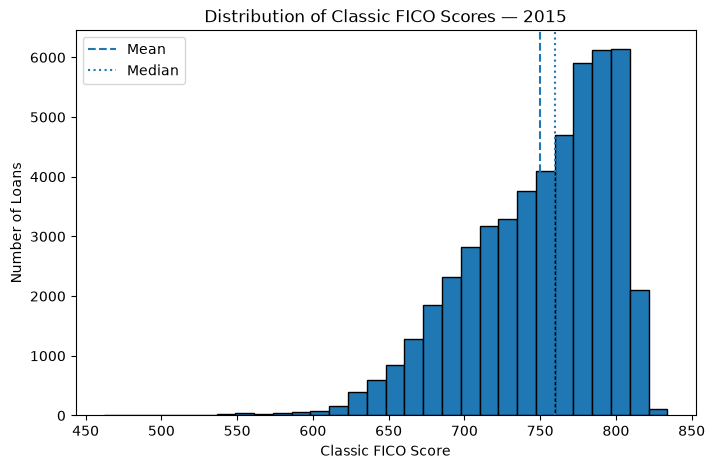

In [127]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    orig_2015["CLASSIC FICO"],
    bins=30,
    edgecolor="black"
)

plt.axvline(
    orig_2015["CLASSIC FICO"].mean(),
    linestyle="--",
    label="Mean"
)

plt.axvline(
    orig_2015["CLASSIC FICO"].median(),
    linestyle=":",
    label="Median"
)

plt.xlabel("Classic FICO Score")
plt.ylabel("Number of Loans")
plt.title("Distribution of Classic FICO Scores — 2015")
plt.legend()

plt.show()

### Classic FICO — 2015 Baseline

- The 2015 sample has a mean FICO score of **749.76** and a median of **760**.
- The middle 50% of borrowers have FICO scores between **718 and 788**.
- The distribution is negatively skewed (**skewness = -0.84**), with most borrowers concentrated toward higher credit scores and a longer tail extending toward lower scores.
- The mean is below the median, which is consistent with the observed left-skewed distribution.
- Lower FICO observations are relatively uncommon but represent valid borrowers and should not be treated as outliers solely because they occur in the lower tail.

**2015 baseline:** The Freddie Mac sample is concentrated among borrowers with relatively high FICO scores, while retaining a smaller lower-credit-score segment. Changes in the location, spread, or shape of this distribution across later origination cohorts may provide evidence of borrower credit-quality drift.

# Step 2 — Debt-to-Income Ratio (DTI)

In [128]:
dti = orig_2015["ORIGINAL DEBT-TO-INCOME (DTI) RATIO_CLEAN"]

print("DTI Summary Statistics:")
print(dti.describe())

print("\nAdditional statistics:")
print("Median:", dti.median())
print("Skewness:", dti.skew())
print("Missing:", dti.isna().sum())
print("Missing %:", round(dti.isna().mean() * 100, 2))

DTI Summary Statistics:
count    45980.000000
mean        33.838756
std          9.391887
min          1.000000
25%         27.000000
50%         35.000000
75%         42.000000
max         50.000000
Name: ORIGINAL DEBT-TO-INCOME (DTI) RATIO_CLEAN, dtype: float64

Additional statistics:
Median: 35.0
Skewness: -0.41588030979854584
Missing: 4020
Missing %: 8.04


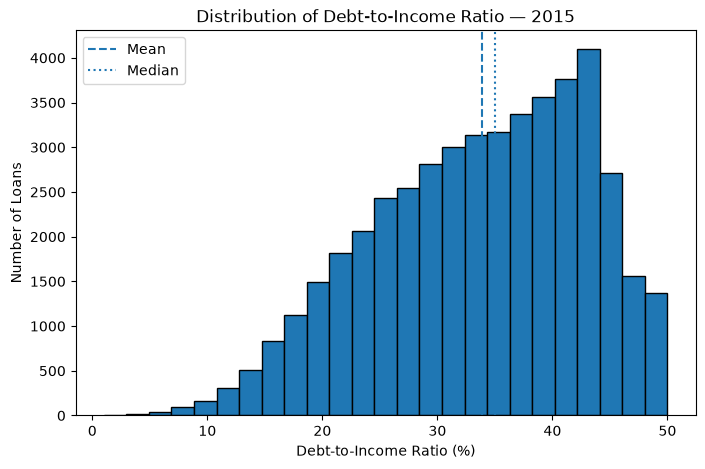

In [129]:
plt.figure(figsize=(8, 5))

plt.hist(
    dti.dropna(),
    bins=25,
    edgecolor="black"
)

plt.axvline(
    dti.mean(),
    linestyle="--",
    label="Mean"
)

plt.axvline(
    dti.median(),
    linestyle=":",
    label="Median"
)

plt.xlabel("Debt-to-Income Ratio (%)")
plt.ylabel("Number of Loans")
plt.title("Distribution of Debt-to-Income Ratio — 2015")
plt.legend()

plt.show()

### Debt-to-Income (DTI) Ratio — 2015 Baseline

- DTI is available for **45,980 loans (91.96%)**, while **4,020 loans (8.04%)** have documented unavailable DTI values and are represented as `NaN` in the clean field.
- Among loans with available DTI, the mean is **33.84%** and the median is **35%**.
- The middle 50% of observations fall between **27% and 42%**, with a standard deviation of **9.39 percentage points**.
- The observed DTI range is **1% to 50%**.
- The distribution is moderately negatively skewed (**skewness = -0.416**), with greater concentration at moderate-to-higher DTI values and a longer tail toward lower DTI values.
- The histogram shows substantial concentration in approximately the **30%–44%** range, followed by lower frequencies toward the upper end of the observed range.

**2015 baseline:** DTI is concentrated in the moderate-to-higher portion of its observed range, with a smaller lower-DTI tail. Future cohort comparisons should examine changes in the distribution's location, spread, shape, and missing-value rate as potential borrower-population drift signals.

#  Step 3 — Original Loan-to-Value (LTV)

In [130]:
ltv = orig_2015["ORIGINAL LOAN-TO-VALUE (LTV)_CLEAN"]

print("LTV Summary Statistics:")
print(ltv.describe())

print("\nAdditional statistics:")
print("Median:", ltv.median())
print("Skewness:", ltv.skew())
print("Missing:", ltv.isna().sum())
print("Missing %:", round(ltv.isna().mean() * 100, 2))

LTV Summary Statistics:
count    49999.000000
mean        73.509970
std         17.514441
min          5.000000
25%         65.000000
50%         78.000000
75%         83.000000
max        241.000000
Name: ORIGINAL LOAN-TO-VALUE (LTV)_CLEAN, dtype: float64

Additional statistics:
Median: 78.0
Skewness: -0.6170748883965615
Missing: 1
Missing %: 0.0


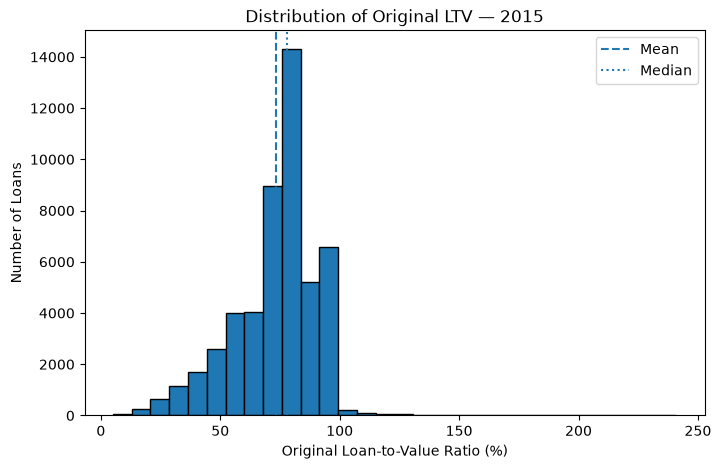

In [131]:
plt.figure(figsize=(8, 5))

plt.hist(
    ltv.dropna(),
    bins=30,
    edgecolor="black"
)

plt.axvline(
    ltv.mean(),
    linestyle="--",
    label="Mean"
)

plt.axvline(
    ltv.median(),
    linestyle=":",
    label="Median"
)

plt.xlabel("Original Loan-to-Value Ratio (%)")
plt.ylabel("Number of Loans")
plt.title("Distribution of Original LTV — 2015")
plt.legend()

plt.show()

### Original Loan-to-Value (LTV) — 2015 Baseline

- LTV is available for **49,999 of 50,000 loans**, with one documented unavailable value represented as `NaN` in the clean field.
- The mean LTV is **73.51%**, while the median is **78%**.
- The middle 50% of loans have LTV values between **65% and 83%**.
- The distribution is negatively skewed (**skewness = -0.617**), reflecting a longer lower-LTV tail.
- The histogram shows that the majority of loans are concentrated approximately between **60% and 95% LTV**, with particularly strong concentration around the **75%–80% region**.
- Rare high-LTV observations previously examined during data validation are retained in the analysis but are not representative of the main 2015 LTV distribution.

**2015 baseline:** The sample is primarily composed of moderately to highly leveraged mortgages, with substantial concentration near the upper portion of the typical LTV range. Future cohort comparisons should examine shifts in the center, spread, distribution shape, and concentration of LTV as potential changes in borrower leverage.

# Step 4 — Original Combined Loan-to-Value (CLTV)

In [132]:
cltv = orig_2015["ORIGINAL COMBINED LOAN-TO-VALUE (CLTV)_CLEAN"]

print("CLTV Summary Statistics:")
print(cltv.describe())

print("\nAdditional statistics:")
print("Median:", cltv.median())
print("Skewness:", cltv.skew())
print("Missing:", cltv.isna().sum())
print("Missing %:", round(cltv.isna().mean() * 100, 2))

CLTV Summary Statistics:
count    49999.000000
mean        74.402428
std         18.020717
min          5.000000
25%         66.000000
50%         79.000000
75%         85.000000
max        854.000000
Name: ORIGINAL COMBINED LOAN-TO-VALUE (CLTV)_CLEAN, dtype: float64

Additional statistics:
Median: 79.0
Skewness: 1.1653157802852574
Missing: 1
Missing %: 0.0


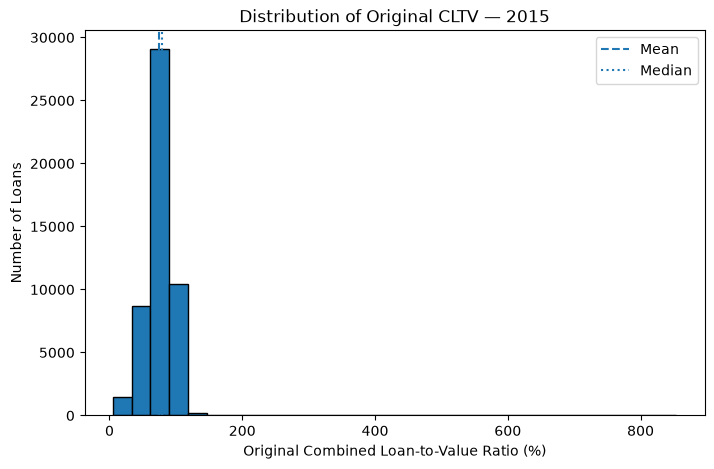

In [133]:
plt.figure(figsize=(8, 5))

plt.hist(
    cltv.dropna(),
    bins=30,
    edgecolor="black"
)

plt.axvline(
    cltv.mean(),
    linestyle="--",
    label="Mean"
)

plt.axvline(
    cltv.median(),
    linestyle=":",
    label="Median"
)

plt.xlabel("Original Combined Loan-to-Value Ratio (%)")
plt.ylabel("Number of Loans")
plt.title("Distribution of Original CLTV — 2015")
plt.legend()

plt.show()

# Zoomed CLTV distribution - 854 observation stretches the x-axis so much that the main CLTV distribution is compressed.

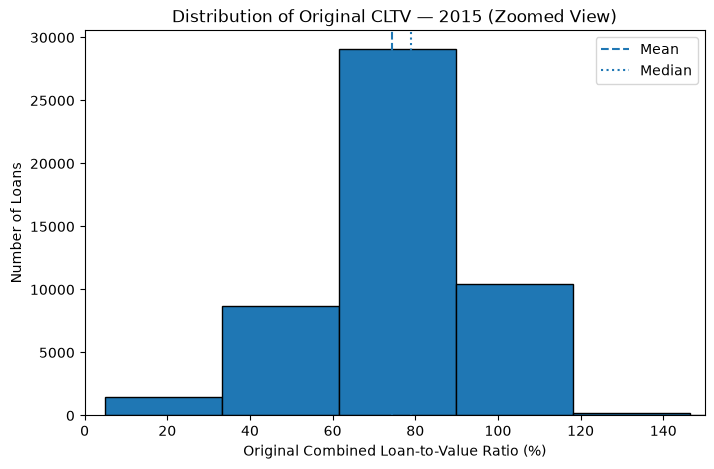

In [134]:
plt.figure(figsize=(8, 5))

plt.hist(
    cltv.dropna(),
    bins=30,
    edgecolor="black"
)

plt.xlim(0, 150)

plt.axvline(
    cltv.mean(),
    linestyle="--",
    label="Mean"
)

plt.axvline(
    cltv.median(),
    linestyle=":",
    label="Median"
)

plt.xlabel("Original Combined Loan-to-Value Ratio (%)")
plt.ylabel("Number of Loans")
plt.title("Distribution of Original CLTV — 2015 (Zoomed View)")
plt.legend()

plt.show()

The main 2015 CLTV population is concentrated around 60–100%, with a median of 79%. The overall positive skewness is strongly influenced by a rare, previously validated extreme observation and therefore does not accurately describe the shape of the typical CLTV population.

# Step 5 — Mortgage Insurance Percentage

In [135]:
mi = orig_2015["MORTGAGE INSURANCE PERCENTAGE (MI %)"]

print("MI Percentage Summary Statistics:")
print(mi.describe())

print("\nAdditional statistics:")
print("Median:", mi.median())
print("Skewness:", mi.skew())
print("Missing:", mi.isna().sum())
print("Unique:", mi.nunique())

MI Percentage Summary Statistics:
count    50000.000000
mean         5.901860
std         11.149558
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         40.000000
Name: MORTGAGE INSURANCE PERCENTAGE (MI %), dtype: float64

Additional statistics:
Median: 0.0
Skewness: 1.4690503883576889
Missing: 0
Unique: 16


# For MI, a standard histogram alone isn't the best first visualization. Let's first separate loans with MI vs. loans without MI.

In [136]:
print("Loans with MI = 0:")
print((mi == 0).sum())

print("\nLoans with MI > 0:")
print((mi > 0).sum())

print("\nPercentage with MI > 0:")
print(round((mi > 0).mean() * 100, 2))

print("\nMI values among loans with MI > 0:")
print(mi[mi > 0].describe())

Loans with MI = 0:
38271

Loans with MI > 0:
11729

Percentage with MI > 0:
23.46

MI values among loans with MI > 0:
count    11729.000000
mean        25.159263
std          6.740048
min          6.000000
25%         25.000000
50%         30.000000
75%         30.000000
max         40.000000
Name: MORTGAGE INSURANCE PERCENTAGE (MI %), dtype: float64


visualize the positive-MI subset rather than make a histogram dominated by the 38,271 zeros.

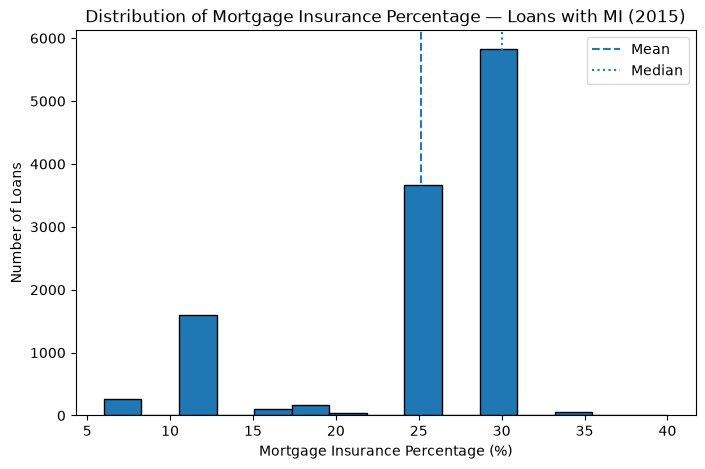

In [137]:
plt.figure(figsize=(8, 5))

plt.hist(
    mi[mi > 0],
    bins=15,
    edgecolor="black"
)

plt.axvline(
    mi[mi > 0].mean(),
    linestyle="--",
    label="Mean"
)

plt.axvline(
    mi[mi > 0].median(),
    linestyle=":",
    label="Median"
)

plt.xlabel("Mortgage Insurance Percentage (%)")
plt.ylabel("Number of Loans")
plt.title("Distribution of Mortgage Insurance Percentage — Loans with MI (2015)")
plt.legend()

plt.show()

### Mortgage Insurance Percentage — 2015 Baseline

- **38,271 loans (76.54%)** have no mortgage insurance (`MI = 0`).
- **11,729 loans (23.46%)** have positive mortgage insurance coverage.
- Because more than three-quarters of loans have `MI = 0`, the overall median and 75th percentile are both **0%**, and the overall mean of **5.90%** does not describe the typical MI coverage among insured loans.
- Among loans with positive MI:
  - Mean coverage = **25.16%**
  - Median coverage = **30%**
  - Middle 50% = **25%–30%**
  - Range = **6%–40%**
- The positive-MI distribution is concentrated at specific coverage levels rather than being continuously distributed, with particularly strong concentrations around **25% and 30%**.
- The conditional mean is below the median because lower MI coverage levels pull the mean downward.

**2015 baseline:** Mortgage insurance is present on approximately one-quarter of the 2015 loans. Among insured loans, coverage is strongly concentrated around 25%–30%. Future cohort comparisons should therefore examine both the **share of loans carrying mortgage insurance** and the **distribution of coverage levels among insured loans**.

# Step 6 — Original UPB

In [138]:
upb = orig_2015["ORIGINAL UPB"]

print("Original UPB Summary Statistics:")
print(upb.describe())

print("\nAdditional statistics:")
print("Median:", upb.median())
print("Skewness:", upb.skew())
print("Missing:", upb.isna().sum())
print("Unique:", upb.nunique())

Original UPB Summary Statistics:
count     50000.000000
mean     224006.060000
std      119990.497697
min       10000.000000
25%      131000.000000
50%      200000.000000
75%      299000.000000
max      974000.000000
Name: ORIGINAL UPB, dtype: float64

Additional statistics:
Median: 200000.0
Skewness: 0.8858002739808308
Missing: 0
Unique: 657


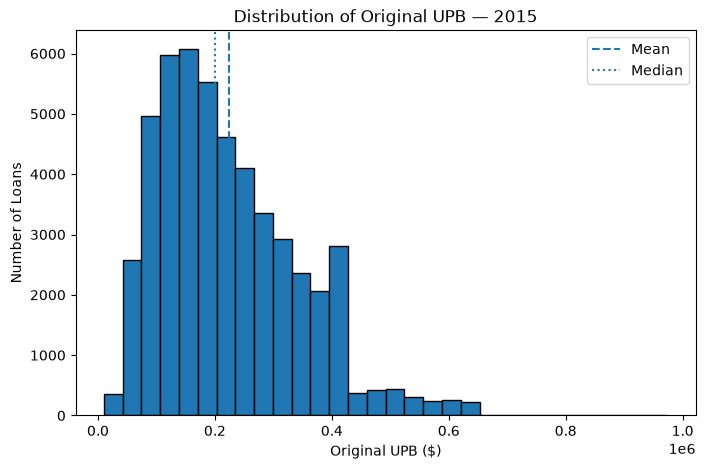

In [139]:
plt.figure(figsize=(8, 5))

plt.hist(
    upb,
    bins=30,
    edgecolor="black"
)

plt.axvline(
    upb.mean(),
    linestyle="--",
    label="Mean"
)

plt.axvline(
    upb.median(),
    linestyle=":",
    label="Median"
)

plt.xlabel("Original UPB ($)")
plt.ylabel("Number of Loans")
plt.title("Distribution of Original UPB — 2015")
plt.legend()

plt.show()

### Original Unpaid Principal Balance (UPB) — 2015 Baseline

- Original UPB is available for all **50,000 loans** in the 2015 sample.
- The mean original loan balance is approximately **$224,006**, while the median is **$200,000**.
- The middle 50% of loans have original balances between **$131,000 and $299,000**.
- The distribution is moderately right-skewed (**skewness = 0.886**), with the mean exceeding the median.
- Most loans are concentrated in the lower-to-middle portion of the observed balance range, while progressively fewer loans occur at higher balances.
- A noticeable concentration is also visible around the **$400,000–$420,000** region.
- The upper tail extends to **$974,000**, although loans near the upper end are relatively uncommon.

**2015 baseline:** The typical mortgage in the sample has an original balance of approximately **$200,000**, while a smaller number of substantially larger mortgages produce a right-tailed loan-size distribution. Future cohort comparisons should examine shifts in the center, spread, and upper tail of the Original UPB distribution as potential evidence of changes in the mortgage population.

# Step 7 — Original Interest Rate

In [140]:
interest_rate = orig_2015["ORIGINAL INTEREST RATE"]

print("Original Interest Rate Summary Statistics:")
print(interest_rate.describe())

print("\nAdditional statistics:")
print("Median:", interest_rate.median())
print("Skewness:", interest_rate.skew())
print("Missing:", interest_rate.isna().sum())
print("Unique:", interest_rate.nunique())

Original Interest Rate Summary Statistics:
count    50000.000000
mean         3.974625
std          0.451811
min          2.375000
25%          3.750000
50%          4.000000
75%          4.250000
max          5.500000
Name: ORIGINAL INTEREST RATE, dtype: float64

Additional statistics:
Median: 4.0
Skewness: -0.3097665154971441
Missing: 0
Unique: 333


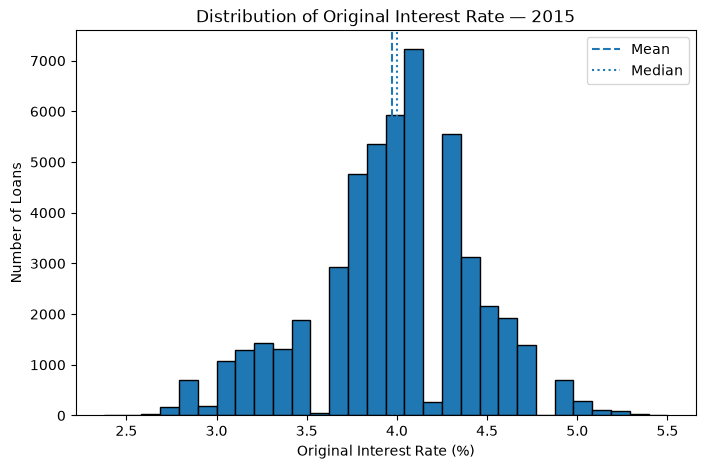

In [141]:
plt.figure(figsize=(8, 5))

plt.hist(
    interest_rate,
    bins=30,
    edgecolor="black"
)

plt.axvline(
    interest_rate.mean(),
    linestyle="--",
    label="Mean"
)

plt.axvline(
    interest_rate.median(),
    linestyle=":",
    label="Median"
)

plt.xlabel("Original Interest Rate (%)")
plt.ylabel("Number of Loans")
plt.title("Distribution of Original Interest Rate — 2015")
plt.legend()

plt.show()

### Original Interest Rate — 2015 Baseline

- Original interest rate is available for all **50,000 loans** in the 2015 sample.
- The mean interest rate is **3.975%**, while the median is **4.00%**.
- The middle 50% of loans have interest rates between **3.75% and 4.25%**, with a standard deviation of approximately **0.45 percentage points**.
- The observed rates range from **2.375% to 5.50%**.
- The distribution is mildly negatively skewed (**skewness = -0.310**), with a somewhat longer lower-rate tail.
- Most loans are concentrated approximately between **3.7% and 4.4%**.
- The histogram contains several distinct concentrations rather than forming a perfectly smooth distribution, reflecting repeated mortgage contract rates within the cohort.

**2015 baseline:** Mortgage interest rates are tightly concentrated around **4%** in the 2015 sample. Because prevailing interest-rate environments can change substantially across origination periods, shifts in the location and shape of this distribution may become an important temporal drift signal in later cohort comparisons.

## VISUALIZATION OF ORIGINAL LOAN TERM - BAR CHART

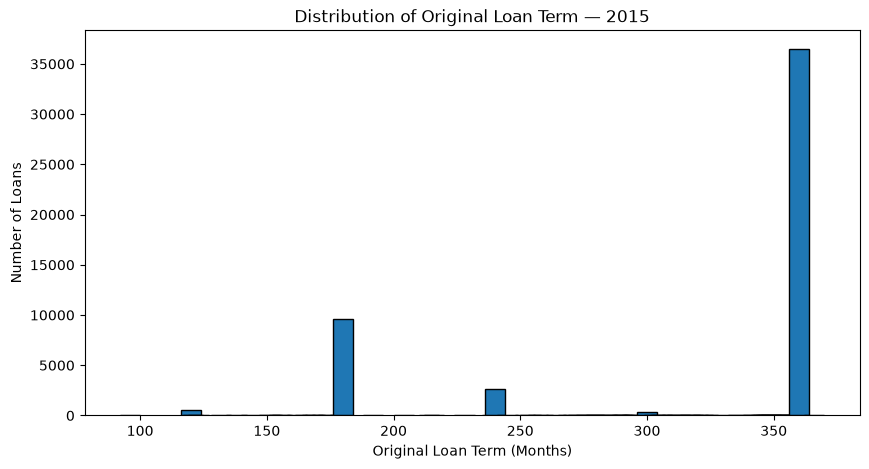

In [142]:
loan_term = orig_2015["ORIGINAL LOAN TERM"]

term_counts = loan_term.value_counts().sort_index()

plt.figure(figsize=(10, 5))

plt.bar(
    term_counts.index,
    term_counts.values,
    width=8,
    edgecolor="black"
)

plt.xlabel("Original Loan Term (Months)")
plt.ylabel("Number of Loans")
plt.title("Distribution of Original Loan Term — 2015")

plt.show()

### Original Loan Term — 2015 Baseline

- The 2015 origination population is strongly concentrated in standard mortgage terms.
- **36,501 loans (73.00%)** have a **360-month (30-year)** original loan term, making this the dominant loan structure in the sample.
- **9,632 loans (19.26%)** have a **180-month (15-year)** term.
- A smaller concentration is visible around **240 months (20 years)**, while other loan terms occur relatively infrequently.
- Because original loan term represents discrete contractual durations, the distribution is more appropriately characterized using frequencies and proportions rather than continuous-distribution measures such as skewness.

**2015 baseline:** The origination population is dominated by 30-year mortgages, with 15-year mortgages representing the second-largest group. Future cohort comparisons should examine whether the proportion of loans across major contractual terms changes over time.

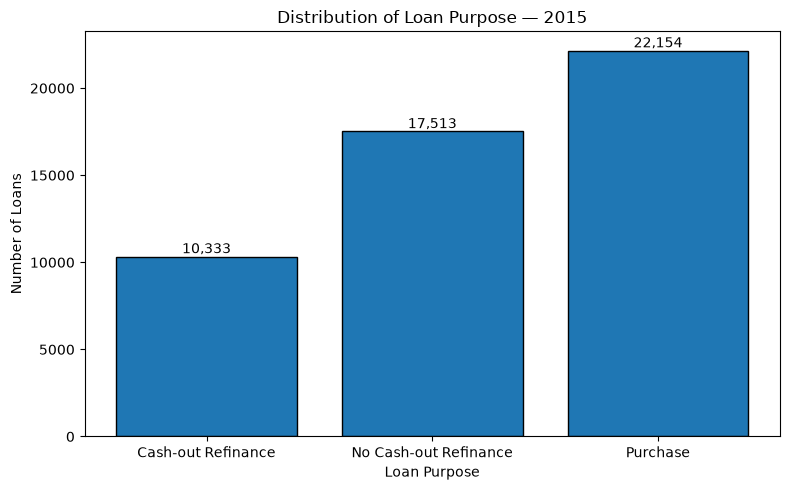

In [143]:
loan_purpose_counts = loan_purpose.value_counts().sort_index()

plt.figure(figsize=(8, 5))

bars = plt.bar(
    loan_purpose_counts.index,
    loan_purpose_counts.values,
    edgecolor="black"
)

plt.xlabel("Loan Purpose")
plt.ylabel("Number of Loans")
plt.title("Distribution of Loan Purpose — 2015")

plt.xticks(
    ["C", "N", "P"],
    ["Cash-out Refinance", "No Cash-out Refinance", "Purchase"]
)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(bar.get_height()):,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### Loan Purpose — 2015 Baseline

- **Purchase loans** are the largest group, with **22,154 loans (44.31%)** of the 2015 sample.
- **No Cash-out Refinance** loans account for **17,513 loans (35.03%)**.
- **Cash-out Refinance** loans account for **10,333 loans (20.67%)**.
- The origination population therefore contains a mixture of purchase and refinance activity, with purchase mortgages representing the largest individual loan-purpose category.
- Combined, the two refinance categories represent approximately **55.70%** of the sample.

**2015 baseline:** Purchase mortgages account for approximately 44% of the sample, while refinance mortgages collectively account for approximately 56%. Future cohort comparisons should examine changes in loan-purpose composition because shifts between purchase and refinance activity may represent meaningful changes in the underlying mortgage population.

# CHANNEL VISUALIZATION - BAR CHART

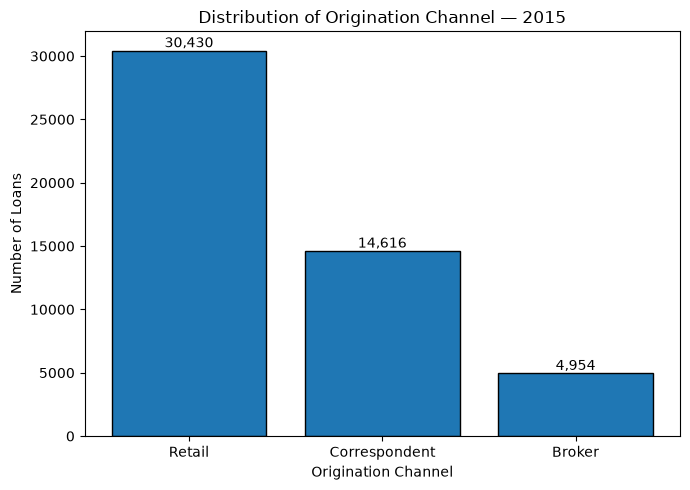

In [144]:
channel = orig_2015["CHANNEL"]

channel_counts = channel.value_counts()

plt.figure(figsize=(7, 5))

bars = plt.bar(
    channel_counts.index,
    channel_counts.values,
    edgecolor="black"
)

plt.xlabel("Origination Channel")
plt.ylabel("Number of Loans")
plt.title("Distribution of Origination Channel — 2015")

plt.xticks(
    ["R", "C", "B"],
    ["Retail", "Correspondent", "Broker"]
)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(bar.get_height()):,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### Origination Channel — 2015 Baseline

- **Retail** is the dominant origination channel, accounting for **30,430 loans (60.86%)** of the 2015 sample.
- **Correspondent** originations account for **14,616 loans (29.23%)**.
- **Broker** originations represent the smallest group, with **4,954 loans (9.91%)**.
- The 2015 origination population is therefore primarily composed of loans originated through the retail channel, with correspondent lending representing a substantial secondary channel and broker originations representing a relatively small share.

**2015 baseline:** Approximately three-fifths of the sample was originated through the Retail channel. Future cohort comparisons should examine changes in origination-channel composition because shifts in the relative importance of Retail, Correspondent, and Broker channels may indicate structural changes in the mortgage population.

# PROPERTY TYPE VISUALIZATION - BAR CHART

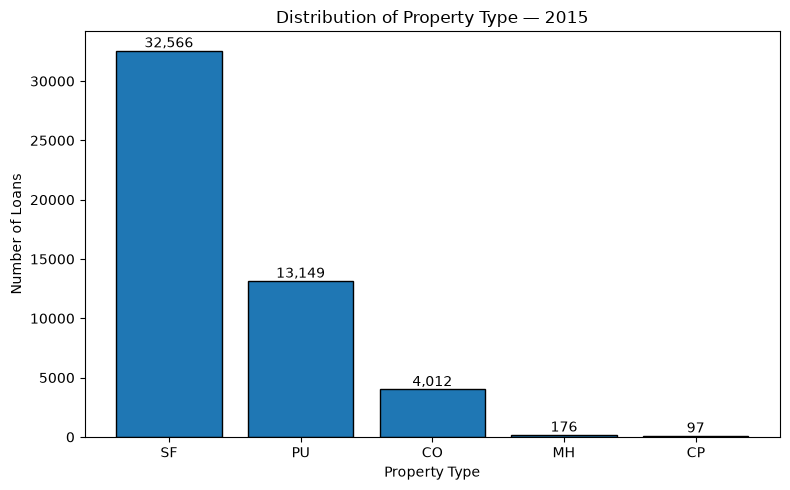

In [145]:
property_type = orig_2015["PROPERTY TYPE"]

property_type_counts = property_type.value_counts()

plt.figure(figsize=(8, 5))

bars = plt.bar(
    property_type_counts.index,
    property_type_counts.values,
    edgecolor="black"
)

plt.xlabel("Property Type")
plt.ylabel("Number of Loans")
plt.title("Distribution of Property Type — 2015")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(bar.get_height()):,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### Property Type — 2015 Baseline

- **Single-family (SF)** properties dominate the 2015 sample, accounting for **32,566 loans (65.13%)**.
- **Planned Unit Development (PU)** properties represent **13,149 loans (26.30%)**.
- **Condominiums (CO)** account for **4,012 loans (8.02%)**.
- **Manufactured Housing (MH)** and **Cooperative (CP)** properties are uncommon, together representing less than **1%** of the sample.
- The 2015 property mix is therefore heavily concentrated in single-family properties, with Planned Unit Developments forming the second-largest group.

**2015 baseline:** Approximately two-thirds of the 2015 loans are associated with single-family properties. Future cohort comparisons should examine changes in property-type composition as a potential indicator of changes in the underlying mortgage population.

# OCCUPANCY STATUS VISUALIZATION - BAR CHART 

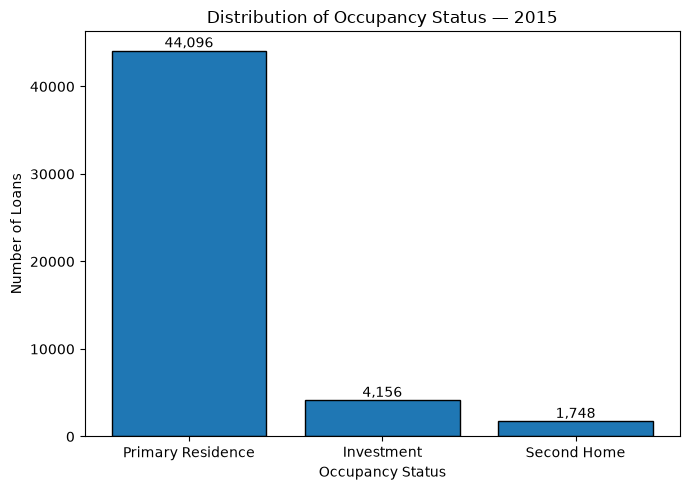

In [146]:
occupancy = orig_2015["OCCUPANCY STATUS"]

occupancy_counts = occupancy.value_counts()

plt.figure(figsize=(7, 5))

bars = plt.bar(
    occupancy_counts.index,
    occupancy_counts.values,
    edgecolor="black"
)

plt.xlabel("Occupancy Status")
plt.ylabel("Number of Loans")
plt.title("Distribution of Occupancy Status — 2015")

plt.xticks(
    ["P", "I", "S"],
    ["Primary Residence", "Investment", "Second Home"]
)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(bar.get_height()):,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### Occupancy Status — 2015 Baseline

- **Primary residences** dominate the 2015 sample, accounting for **44,096 loans (88.19%)**.
- **Investment properties** account for **4,156 loans (8.31%)**.
- **Second homes** represent **1,748 loans (3.50%)**.
- The mortgage population is therefore overwhelmingly concentrated in owner-occupied primary residences, while investment properties and second homes form relatively small segments.

**2015 baseline:** Nearly nine out of ten loans in the sample are associated with primary residences. Future cohort comparisons should examine changes in occupancy composition because shifts in the proportions of primary residences, investment properties, and second homes may represent meaningful changes in borrower and property risk composition.

# NUMBER OF UNITS - since 97.86% are already known to be 1-unit properties WE DONT NEED VISUALIZATION
### Number of Units — 2015 Baseline

- The 2015 sample is overwhelmingly composed of **one-unit properties**, with **48,928 loans (97.86%)**.
- Two-unit properties account for **739 loans (1.48%)**, while three-unit and four-unit properties account for only **183 (0.37%)** and **150 (0.30%)** loans, respectively.
- Multi-unit properties therefore represent only a small portion of the 2015 origination population.

**2015 baseline:** The property population is almost entirely composed of one-unit properties. This variable will be retained as a structural characteristic, but its highly concentrated 2015 distribution limits the value of additional standalone visualization.

# PROPERTY STATE BAR CHART

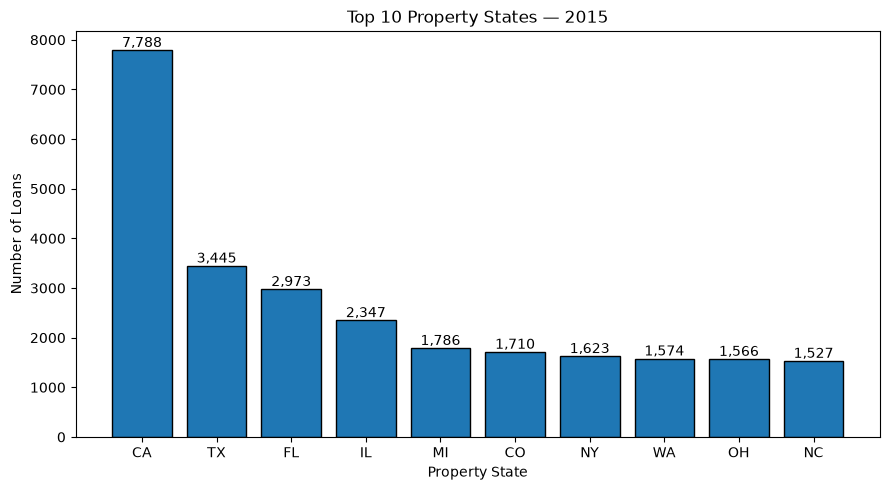

In [147]:
property_state = orig_2015["PROPERTY STATE"]

top_states = property_state.value_counts().head(10)

plt.figure(figsize=(9, 5))

bars = plt.bar(
    top_states.index,
    top_states.values,
    edgecolor="black"
)

plt.xlabel("Property State")
plt.ylabel("Number of Loans")
plt.title("Top 10 Property States — 2015")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(bar.get_height()):,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### Property State — 2015 Baseline

- The 2015 sample contains loans across **54 state and territory codes**, indicating broad geographic coverage.
- **California** is the most represented state, with **7,788 loans (15.58%)**, substantially more than any other individual state.
- The next largest concentrations are **Texas (6.89%)**, **Florida (5.95%)**, and **Illinois (4.69%)**.
- The remaining loans are distributed across a broad set of states and territories.
- Because the variable contains many geographic categories, the visualization focuses on the ten most represented states rather than displaying all categories.

**2015 baseline:** The mortgage population has broad geographic coverage but unequal representation across states, with California accounting for a particularly large share. Future cohort comparisons should examine changes in geographic composition because shifts in state representation could contribute to observed population drift and may reflect differences in regional housing markets.

# Metropolitan Statistical Area (MSA)
### Metropolitan Statistical Area (MSA) — 2015 Baseline

- MSA or Metropolitan Division information is available for **44,396 loans (88.79%)**.
- **5,604 loans (11.21%)** have missing MSA information.
- The sample contains **445 distinct observed MSA/Metropolitan Division codes**, indicating substantial geographic diversity at the metropolitan level.
- Because of the large number of categories, a standalone categorical visualization would provide limited interpretive value at this stage.

**2015 baseline:** The sample covers a broad range of metropolitan areas, although approximately 11% of loans do not have an available MSA designation. MSA may become more informative in later geographic or temporal drift analysis rather than through standalone univariate visualization.

# FIRST PAYMENT DATE.

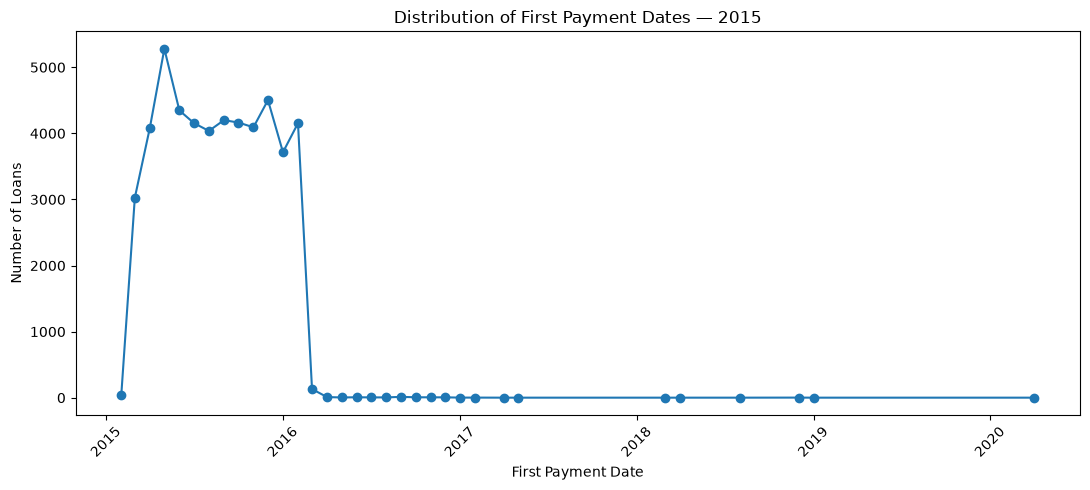

In [148]:
first_payment = pd.to_datetime(
    orig_2015["FIRST PAYMENT DATE"].astype(str),
    format="%Y%m"
)

payment_counts = first_payment.value_counts().sort_index()

plt.figure(figsize=(11, 5))

plt.plot(
    payment_counts.index,
    payment_counts.values,
    marker="o"
)

plt.xlabel("First Payment Date")
plt.ylabel("Number of Loans")
plt.title("Distribution of First Payment Dates — 2015")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### First Payment Date — 2015 Baseline

- First payment dates are overwhelmingly concentrated in **2015**, with the largest monthly volumes occurring during the main 2015 origination period.
- Monthly loan counts during the core 2015 period are generally substantial, with several months containing approximately **4,000–5,000 loans**.
- A smaller number of first payment dates occur after the main 2015 period, extending into later years.
- These later observations are very uncommon relative to the dominant 2015 population but are retained because their date values were previously validated.
- The full time range is displayed to preserve visibility of the complete validated population, although the later low-frequency observations visually compress the main 2015 distribution.

**2015 baseline:** The sample is temporally concentrated around the 2015 origination cohort, with only a small number of loans having substantially later first payment dates. Future cohort construction and temporal drift analysis should use consistent cohort definitions rather than assuming that every record associated with a yearly acquisition file necessarily has a first payment date within that same calendar year.

## BIVARIATE/ Domain-Driven EDA



This section examines relationships between origination characteristics using
mortgage-domain expectations. The objective is to identify meaningful
relationships, investigate unexpected combinations, and establish the 2015
baseline relationships that may later be monitored for population drift and
model reliability.

Cleaned variables are used where documented sentinel values were identified,
while the original raw variables remain preserved.

### Origination Data Grain Verification

Before performing bivariate analysis, the observation grain of the 2015 origination dataset was verified.

The dataset contains 50,000 observations and 50,000 unique loan identifiers, with no duplicate `LOAN IDENTIFIER` values. Therefore, each row represents one unique mortgage loan at origination.

Because variables such as LTV, CLTV, DTI, credit score, and interest rate occur on the same row for a given loan, row-wise comparisons between these variables represent within-loan relationships. No grouping by `LOAN IDENTIFIER` is required for the origination-level bivariate analysis.

This differs from the monthly performance dataset, where each loan can appear across multiple reporting periods and the observation grain must account for both loan identifier and time.

In [149]:
loan_id = orig_2015["LOAN IDENTIFIER"]

print("Total observations:", len(orig_2015))
print()
print("Unique loan identifiers:", loan_id.nunique())
print()
print("Duplicate loan identifiers:", loan_id.duplicated().sum())

Total observations: 50000

Unique loan identifiers: 50000

Duplicate loan identifiers: 0


# LTV vs CLTV analysis

In [150]:
ltv = orig_2015["ORIGINAL LOAN-TO-VALUE (LTV)_CLEAN"]
cltv = orig_2015["ORIGINAL COMBINED LOAN-TO-VALUE (CLTV)_CLEAN"]

valid_pairs_mask = ltv.notna() & cltv.notna()

print("Valid paired observations:", valid_pairs_mask.sum())
print()
print("CLTV = LTV:", ((cltv == ltv) & valid_pairs_mask).sum())
print()
print("CLTV > LTV:", ((cltv > ltv) & valid_pairs_mask).sum())
print()
print("CLTV < LTV:", ((cltv < ltv) & valid_pairs_mask).sum())

Valid paired observations: 49999

CLTV = LTV: 47073

CLTV > LTV: 2926

CLTV < LTV: 0


# quantify the relationship- calculate how large the difference between CLTV and LTV is.

In [151]:
cltv_ltv_diff = cltv - ltv

print("CLTV - LTV summary:")
print(cltv_ltv_diff[valid_pairs_mask].describe())
print()
print("Loans with CLTV = LTV (%):",
      ((cltv == ltv) & valid_pairs_mask).sum() / valid_pairs_mask.sum() * 100)
print()
print("Loans with CLTV > LTV (%):",
      ((cltv > ltv) & valid_pairs_mask).sum() / valid_pairs_mask.sum() * 100)

CLTV - LTV summary:
count    49999.000000
mean         0.892458
std          5.706536
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        809.000000
dtype: float64

Loans with CLTV = LTV (%): 94.14788295765916

Loans with CLTV > LTV (%): 5.852117042340846


# investigate the largest gaps

In [152]:
largest_cltv_ltv_gaps = orig_2015.loc[
    valid_pairs_mask,
    [
        "LOAN IDENTIFIER",
        "ORIGINAL LOAN-TO-VALUE (LTV)",
        "ORIGINAL COMBINED LOAN-TO-VALUE (CLTV)",
        "LOAN PURPOSE",
        "PROPERTY TYPE",
        "OCCUPANCY STATUS"
    ]
].copy()

largest_cltv_ltv_gaps["CLTV - LTV"] = cltv_ltv_diff[valid_pairs_mask]

largest_cltv_ltv_gaps.sort_values(
    "CLTV - LTV",
    ascending=False
).head(20)

,LOAN IDENTIFIER,ORIGINAL LOAN-TO-VALUE (LTV),ORIGINAL COMBINED LOAN-TO-VALUE (CLTV),LOAN PURPOSE,PROPERTY TYPE,OCCUPANCY STATUS,CLTV - LTV
47169,F15Q40257850,45,854,N,PU,I,809.0
18544,F15Q20197523,58,172,N,SF,P,114.0
17132,F15Q20151539,56,160,N,SF,I,104.0
41193,F15Q40097579,118,200,N,CO,P,82.0
42180,F15Q40124762,53,134,N,PU,P,81.0
22699,F15Q20337498,39,118,N,SF,P,79.0
45023,F15Q40200114,64,141,N,SF,I,77.0
8494,F15Q10250505,74,149,N,CO,I,75.0
18477,F15Q20194965,89,161,N,SF,P,72.0
11983,F15Q10352557,43,114,N,SF,I,71.0


### LTV vs. CLTV — Domain Relationship Findings

The relationship between Original Loan-to-Value (LTV) and Original Combined Loan-to-Value (CLTV) was evaluated using the cleaned variables, where the documented `999 = Not Available` sentinel had previously been replaced with `NaN`.

Of the 50,000 origination records, 49,999 loans had valid paired LTV and CLTV values. The single unavailable LTV and CLTV values occur on the same loan.

Among the valid pairs:

- **47,073 loans (94.15%)** have `CLTV = LTV`.
- **2,926 loans (5.85%)** have `CLTV > LTV`.
- **0 loans** have `CLTV < LTV`.

Therefore, the expected mortgage-domain relationship **CLTV ≥ LTV holds for all valid observations** in the 2015 sample.

The distribution of `CLTV - LTV` is strongly concentrated at zero, with a median and 75th percentile of zero. A small number of loans exhibit substantially larger differences, including previously investigated extreme leverage observations. These values were retained because the LTV and CLTV disclosure behavior and sentinel handling were already evaluated against Freddie Mac documentation during univariate validation.

No additional cleaning is justified based solely on the LTV–CLTV bivariate relationship.

# Correlation analysis

In [153]:
import scipy
print(scipy.__version__)

1.18.1


In [154]:
pearson_corr = ltv[valid_pairs_mask].corr(
    cltv[valid_pairs_mask],
    method="pearson"
)

spearman_corr = ltv[valid_pairs_mask].corr(
    cltv[valid_pairs_mask],
    method="spearman"
)

print("Pearson correlation:", pearson_corr)
print()
print("Spearman correlation:", spearman_corr)

Pearson correlation: 0.9488182651799325

Spearman correlation: 0.9656857866870585


### LTV–CLTV Correlation

The association between LTV and CLTV was quantified using both Pearson and Spearman correlation.

- **Pearson correlation:** 0.9488
- **Spearman correlation:** 0.9657

Both measures indicate a very strong positive association between LTV and CLTV, consistent with their closely related mortgage definitions and the observation that 94.15% of valid loans have identical LTV and CLTV values.

The slightly higher Spearman correlation indicates that the rank-based relationship is somewhat stronger than the linear relationship measured by Pearson. This is consistent with the presence of a small number of extreme leverage observations, which have greater influence on Pearson correlation because it depends on the numerical magnitude of the observations.

These correlations should be interpreted as measures of association rather than causation. LTV and CLTV are mechanically related mortgage leverage measures, with CLTV incorporating additional subordinate financing where applicable.

Among the 2,926 loans where CLTV > LTV, what does the gap normally look like?

In [155]:
positive_gap = cltv_ltv_diff[cltv_ltv_diff > 0]

print("Loans with positive CLTV - LTV gap:", len(positive_gap))
print()
print("Positive gap summary:")
print(positive_gap.describe())

Loans with positive CLTV - LTV gap: 2926

Positive gap summary:
count    2926.000000
mean       15.250171
std        18.374014
min         1.000000
25%         8.000000
50%        12.000000
75%        19.000000
max       809.000000
dtype: float64


# hexbin plot, which is better for 50,000 observations

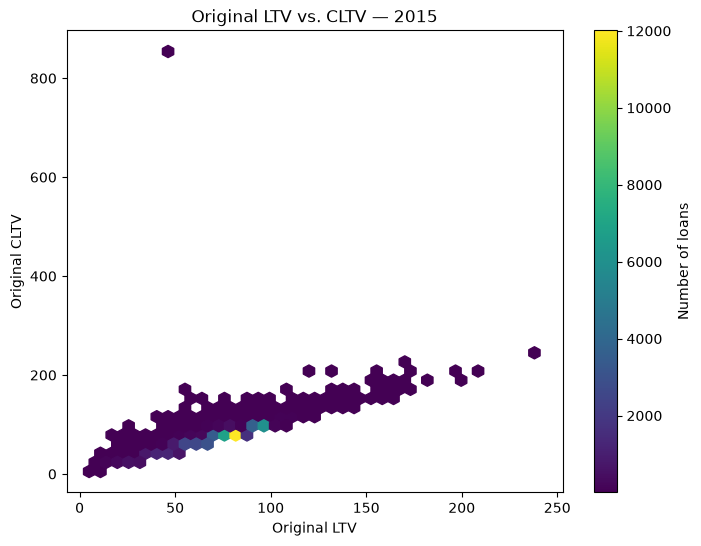

In [156]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.hexbin(
    ltv[valid_pairs_mask],
    cltv[valid_pairs_mask],
    gridsize=40,
    mincnt=1,
    cmap="viridis"
)

plt.colorbar(label="Number of loans")

plt.xlabel("Original LTV")
plt.ylabel("Original CLTV")
plt.title("Original LTV vs. CLTV — 2015")

plt.show()

# Scatter chart

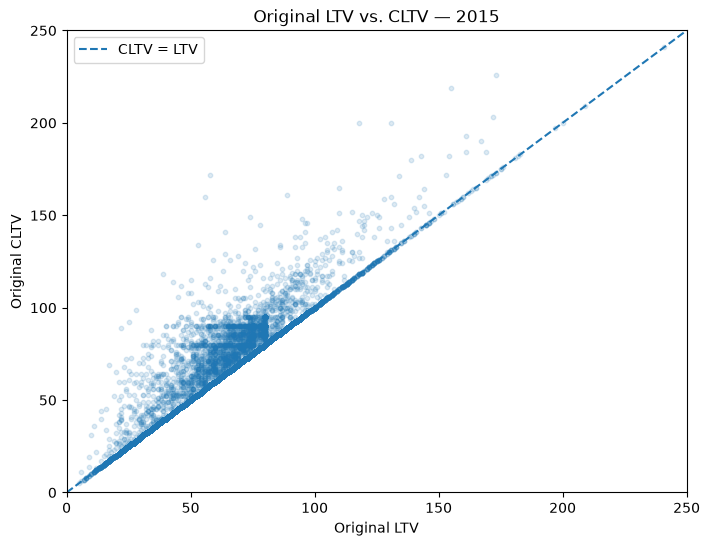

In [157]:
plt.figure(figsize=(8, 6))

plt.scatter(
    ltv[valid_pairs_mask],
    cltv[valid_pairs_mask],
    alpha=0.15,
    s=10
)

plt.plot(
    [0, 250],
    [0, 250],
    linestyle="--",
    linewidth=1.5,
    label="CLTV = LTV"
)

plt.xlabel("Original LTV")
plt.ylabel("Original CLTV")
plt.title("Original LTV vs. CLTV — 2015")

plt.xlim(0, 250)
plt.ylim(0, 250)

plt.legend()
plt.show()

### LTV vs. CLTV — Bivariate Findings

Original LTV and Original CLTV demonstrate a strong and domain-consistent relationship in the 2015 origination sample.

Of the 50,000 loans, **49,999 have valid paired LTV and CLTV values** after applying the previously established sentinel-value cleaning rules. The single unavailable LTV and CLTV values occur on the same loan.

Among valid paired observations:

- **47,073 loans (94.15%)** have `CLTV = LTV`.
- **2,926 loans (5.85%)** have `CLTV > LTV`.
- **0 loans** have `CLTV < LTV`.

Thus, the expected mortgage-domain relationship **CLTV ≥ LTV holds for all valid observations**.

For the 2,926 loans where CLTV exceeds LTV, the median `CLTV - LTV` difference is **12 percentage points**, with the middle 50% of differences ranging from **8 to 19 percentage points**. The distribution is right-skewed because of a small number of previously investigated extreme leverage observations.

The relationship is also reflected in the correlation measures:

- **Pearson correlation = 0.9488**
- **Spearman correlation = 0.9657**

Both indicate a very strong positive association. The slightly higher Spearman correlation suggests that the monotonic relationship is somewhat stronger than the linear relationship, consistent with the influence of a small number of extreme observations on Pearson correlation.

The scatter plot shows a dense diagonal pattern corresponding to loans where `CLTV = LTV`, with a smaller population appearing above the equality line where `CLTV > LTV`. No observations appear below the equality line. The visualization is restricted to LTV and CLTV values between 0 and 250 for interpretability; previously investigated extreme observations outside this displayed range remain in the underlying dataset and were retained in the numerical and correlation analyses.

Overall, the LTV–CLTV relationship is internally consistent with mortgage-domain expectations, and the bivariate analysis provides no evidence requiring additional cleaning or transformation.

# Bivariate Analysis 2 — LTV vs. Mortgage Insurance Percentage (MI %).

# examine MI by LTV range

### LTV vs. Mortgage Insurance Percentage (MI %) — Analysis Rationale

Loan-to-Value (LTV) and Mortgage Insurance Percentage (MI %) have an important mortgage-domain relationship. LTV measures the amount of first-lien mortgage debt relative to the property value, while mortgage insurance can provide credit protection on loans with higher leverage.

The objective of this analysis is to determine how mortgage insurance behavior changes across different LTV levels in the 2015 Freddie Mac origination population. In particular, the analysis examines:

- whether the prevalence of mortgage insurance increases as LTV increases;
- how the relationship changes around higher-LTV ranges;
- the distribution of loans with `MI = 0` and `MI > 0` across LTV ranges; and
- whether previously observed `LTV > 80` and `MI = 0` loans represent isolated anomalies or a meaningful subgroup of the population.

A simple correlation coefficient is not used as the primary analysis because MI % has a highly concentrated and discrete distribution. Most loans have `MI = 0`, while loans with mortgage insurance take a limited set of positive percentage values. Therefore, a single correlation coefficient could obscure the underlying domain relationship.

Instead, LTV is grouped into interpretable ranges and the proportion of loans with mortgage insurance (`MI > 0`) is calculated within each range. This allows the relationship between leverage and mortgage insurance prevalence to be evaluated directly while preserving the structure of the 2015 mortgage population.

The cleaned LTV variable is used because the documented `999 = Not Available` sentinel was previously replaced with `NaN`. The original MI % variable is retained because no missing or documented sentinel values requiring cleaning were identified during univariate validation.

In [158]:
ltv = orig_2015["ORIGINAL LOAN-TO-VALUE (LTV)_CLEAN"]

mi = orig_2015["MORTGAGE INSURANCE PERCENTAGE (MI %)"]

ltv_mi_valid_mask = ltv.notna() & mi.notna()

print("Valid paired observations:", ltv_mi_valid_mask.sum())
print()
print("Missing LTV:", ltv.isna().sum())
print()
print("Missing MI:", mi.isna().sum())

Valid paired observations: 49999

Missing LTV: 1

Missing MI: 0


In [159]:
ltv_bins = [0, 60, 70, 80, 85, 90, 95, 100, float("inf")]

ltv_labels = [
    "<=60",
    "61-70",
    "71-80",
    "81-85",
    "86-90",
    "91-95",
    "96-100",
    ">100"
]

ltv_groups = pd.cut(
    ltv,
    bins=ltv_bins,
    labels=ltv_labels,
    include_lowest=True
)

In [160]:
ltv_mi_summary = (
    pd.DataFrame({
        "LTV Group": ltv_groups,
        "MI Present": mi > 0
    })
    .loc[ltv_mi_valid_mask]
    .groupby("LTV Group", observed=True)["MI Present"]
    .agg(["count", "sum"])
)

ltv_mi_summary["MI = 0"] = (
    ltv_mi_summary["count"] - ltv_mi_summary["sum"]
)

ltv_mi_summary["MI > 0 (%)"] = (
    ltv_mi_summary["sum"] /
    ltv_mi_summary["count"] * 100
)

ltv_mi_summary

,count,sum,MI = 0,MI > 0 (%)
LTV Group,,,,
<=60,10373,3,10370,0.028921
61-70,6713,2,6711,0.029793
71-80,20069,7,20062,0.034880
81-85,1772,1534,238,86.568849
86-90,3820,3598,222,94.188482
91-95,6401,6238,163,97.453523
96-100,367,203,164,55.313351
>100,484,144,340,29.752066


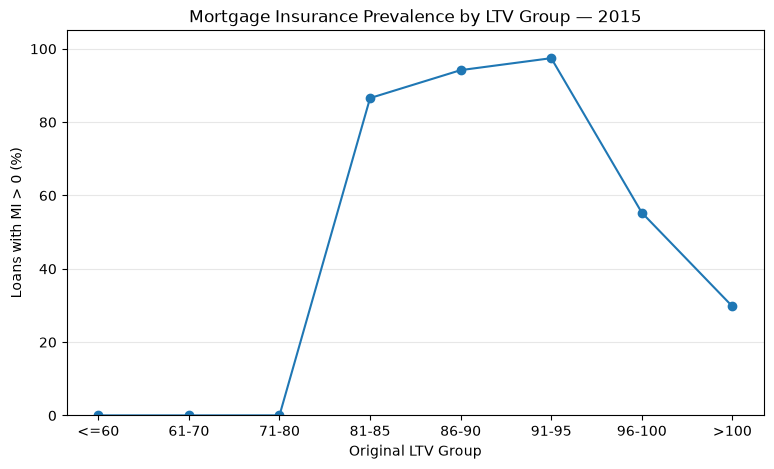

In [161]:
plt.figure(figsize=(9, 5))

plt.plot(
    ltv_mi_summary.index.astype(str),
    ltv_mi_summary["MI > 0 (%)"],
    marker="o"
)

plt.xlabel("Original LTV Group")
plt.ylabel("Loans with MI > 0 (%)")
plt.title("Mortgage Insurance Prevalence by LTV Group — 2015")

plt.ylim(0, 105)

plt.grid(axis="y", alpha=0.3)

plt.show()

#### Mortgage Insurance Prevalence Across LTV Ranges

The grouped analysis reveals a strong but non-linear relationship between LTV and the presence of mortgage insurance.

For loans with **LTV ≤ 80%**, reported mortgage insurance is almost entirely absent. Only a very small number of loans in these ranges have `MI > 0`.

A substantial change occurs once LTV exceeds 80%:

- **81–85% LTV:** 86.57% of loans have MI.
- **86–90% LTV:** 94.19% have MI.
- **91–95% LTV:** 97.45% have MI.

This demonstrates a clear increase in mortgage insurance prevalence immediately above the 80% LTV threshold, reaching its highest observed prevalence in the 91–95% range.

However, this pattern does not continue monotonically at the highest LTV levels:

- **96–100% LTV:** MI prevalence falls to 55.31%.
- **>100% LTV:** MI prevalence falls further to 29.75%.

Therefore, the relationship between LTV and mortgage insurance cannot be described simply as higher LTV corresponding to higher MI prevalence. Instead, the 2015 population shows a pronounced increase in MI prevalence between 80% and 95% LTV, followed by a substantial decline at higher LTV levels.

The high-LTV groups also contain a meaningful number of loans with `MI = 0`. These observations should not be classified as errors based on this relationship alone. Their concentration at higher LTV levels warrants further investigation of other loan characteristics or program structures that may help explain the observed pattern.

This result also illustrates why grouped domain-driven analysis is more informative for this relationship than relying solely on a single correlation coefficient, which could obscure the threshold and non-linear behavior visible across LTV ranges.



### Classic FICO vs. Original Interest Rate — Analysis Rationale

Classic FICO represents borrower credit quality at origination, while the original interest rate represents the contractual mortgage rate at the time the loan was originated.

From a mortgage-risk perspective, borrowers with lower credit scores generally represent greater credit risk. Mortgage pricing may reflect this risk through higher interest rates or other loan-level pricing adjustments. Therefore, examining the relationship between FICO and interest rate helps establish whether borrower credit quality is associated with mortgage pricing in the 2015 origination population.

The objective of this analysis is to:

- determine the direction and strength of the relationship between FICO and interest rate;
- examine whether interest rates tend to differ across borrower credit-score levels;
- identify whether the relationship appears linear or exhibits other structure; and
- establish a 2015 baseline relationship that can later be compared across origination years as borrower populations and market conditions change.

Unlike the LTV–MI relationship, both FICO and interest rate are quantitative variables with substantial variation. Therefore, their joint distribution can be examined directly using a scatter plot, followed by correlation measures where appropriate.

Any association identified should not be interpreted as a causal effect of FICO on interest rate. Mortgage rates are influenced by multiple borrower, loan, market, and pricing characteristics that are not controlled for in this bivariate analysis.

In [162]:
fico = orig_2015["CLASSIC FICO"]
interest_rate = orig_2015["ORIGINAL INTEREST RATE"]

fico_rate_valid_mask = fico.notna() & interest_rate.notna()

print("Valid paired observations:", fico_rate_valid_mask.sum())
print()
print("Missing FICO:", fico.isna().sum())
print()
print("Missing interest rate:", interest_rate.isna().sum())

Valid paired observations: 50000

Missing FICO: 0

Missing interest rate: 0


# examine the numerical relationship - calculate Pearson and Spearman correlation

In [163]:
pearson_corr = fico[fico_rate_valid_mask].corr(
    interest_rate[fico_rate_valid_mask],
    method="pearson"
)

spearman_corr = fico[fico_rate_valid_mask].corr(
    interest_rate[fico_rate_valid_mask],
    method="spearman"
)

print("Pearson correlation:", pearson_corr)
print()
print("Spearman correlation:", spearman_corr)

Pearson correlation: -0.2675904698641144

Spearman correlation: -0.2644388661245058


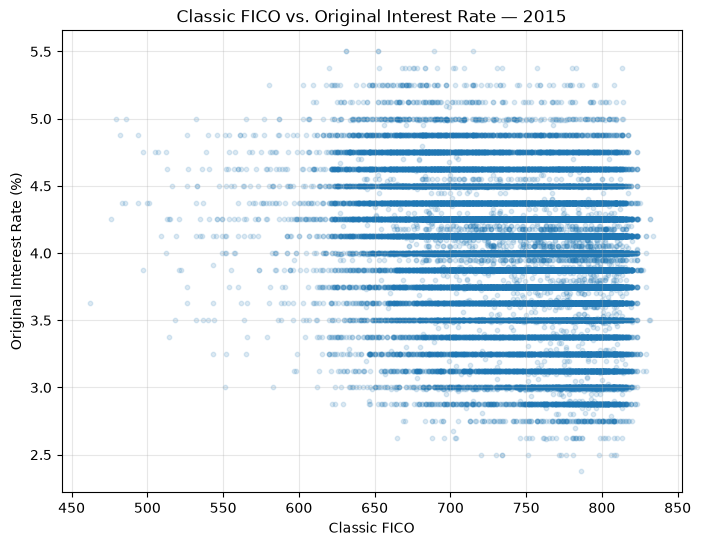

In [164]:
plt.figure(figsize=(8, 6))

plt.scatter(
    fico[fico_rate_valid_mask],
    interest_rate[fico_rate_valid_mask],
    alpha=0.15,
    s=10
)

plt.xlabel("Classic FICO")
plt.ylabel("Original Interest Rate (%)")
plt.title("Classic FICO vs. Original Interest Rate — 2015")

plt.grid(alpha=0.3)

plt.show()

#### Classic FICO vs. Original Interest Rate — Bivariate Findings

All 50,000 loans have valid paired Classic FICO and Original Interest Rate values, allowing the full 2015 origination sample to be used for this analysis.

The relationship between borrower credit score and mortgage interest rate is negative:

- **Pearson correlation = -0.2676**
- **Spearman correlation = -0.2644**

Both measures indicate that higher FICO scores tend to be associated with lower mortgage interest rates. However, the magnitude of the correlations shows that the relationship is not strong.

The scatter plot supports this interpretation. A general downward tendency is visible across the borrower population, but there is substantial variation in interest rates among borrowers with similar FICO scores. This indicates that FICO alone does not explain mortgage pricing in the 2015 sample.

The horizontal concentrations visible in the scatter plot reflect repeated mortgage interest-rate values within the dataset and do not, by themselves, indicate a data-quality problem.

The similarity between the Pearson and Spearman correlations suggests that the overall negative association is reasonably consistent whether measured as a linear relationship or as a rank-based monotonic relationship.

Overall, borrower credit quality is associated with mortgage pricing in the expected direction, but the moderate relationship indicates that other borrower, loan, and market characteristics also contribute to variation in interest rates. This bivariate association should not be interpreted as evidence that FICO alone causes differences in mortgage rates.

# LTV ↔ Interest Rate

In [165]:
ltv = orig_2015["ORIGINAL LOAN-TO-VALUE (LTV)_CLEAN"]
interest_rate = orig_2015["ORIGINAL INTEREST RATE"]

ltv_rate_data = orig_2015.loc[
    ltv.notna() & interest_rate.notna(),
    [
        "ORIGINAL LOAN-TO-VALUE (LTV)_CLEAN",
        "ORIGINAL INTEREST RATE"
    ]
].copy()

print("Valid paired observations:", len(ltv_rate_data))
print()
print("Missing cleaned LTV:", ltv.isna().sum())
print("Missing interest rate:", interest_rate.isna().sum())

Valid paired observations: 49999

Missing cleaned LTV: 1
Missing interest rate: 0


In [166]:
pearson_corr = ltv_rate_data[
    "ORIGINAL LOAN-TO-VALUE (LTV)_CLEAN"
].corr(
    ltv_rate_data["ORIGINAL INTEREST RATE"],
    method="pearson"
)

spearman_corr = ltv_rate_data[
    "ORIGINAL LOAN-TO-VALUE (LTV)_CLEAN"
].corr(
    ltv_rate_data["ORIGINAL INTEREST RATE"],
    method="spearman"
)

print("Pearson correlation:", pearson_corr)
print("Spearman correlation:", spearman_corr)

Pearson correlation: 0.24465969805655938
Spearman correlation: 0.24536860343063657


In [167]:
import seaborn as sns

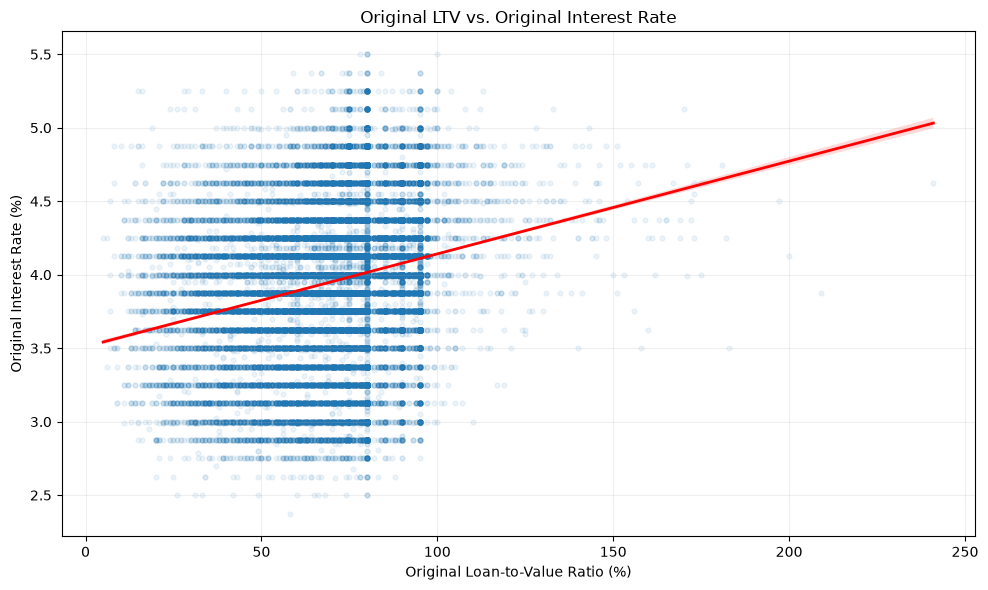

In [168]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=ltv_rate_data,
    x="ORIGINAL LOAN-TO-VALUE (LTV)_CLEAN",
    y="ORIGINAL INTEREST RATE",
    scatter_kws={
        "alpha": 0.08,
        "s": 12
    },
    line_kws={
        "color": "red",
        "linewidth": 2
    }
)

plt.title("Original LTV vs. Original Interest Rate")
plt.xlabel("Original Loan-to-Value Ratio (%)")
plt.ylabel("Original Interest Rate (%)")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

#### Findings

- There were 49,999 valid paired observations after excluding the documented `999` LTV sentinel.
- Pearson correlation was approximately 0.245, indicating a weak positive linear relationship between original LTV and original interest rate.
- Spearman correlation was also approximately 0.245, indicating a similarly weak positive monotonic relationship.
- The scatterplot shows that higher-LTV loans generally received somewhat higher interest rates, but substantial variation exists at each LTV level.
- Most observations are concentrated at LTV values of approximately 100% or below, while a small number of valid high-LTV observations extend the distribution.
- These results indicate an association, but they do not establish that LTV alone caused differences in interest rates.

# ### Numerical Correlation Analysis

The preceding bivariate analyses examined four mortgage-domain relationships involving leverage, mortgage insurance, borrower credit quality, and loan pricing. A correlation heatmap is used next to systematically screen relationships among the remaining numerical origination features. Strong, unexpected, or model-relevant associations identified in the heatmap will be investigated further where necessary.

In [169]:
correlation_data = pd.DataFrame({
    "FICO": orig_2015["CLASSIC FICO"],
    "DTI": orig_2015["ORIGINAL DEBT-TO-INCOME (DTI) RATIO_CLEAN"],
    "LTV": orig_2015["ORIGINAL LOAN-TO-VALUE (LTV)_CLEAN"],
    "CLTV": orig_2015["ORIGINAL COMBINED LOAN-TO-VALUE (CLTV)_CLEAN"],
    "Original UPB": orig_2015["ORIGINAL UPB"],
    "Interest Rate": orig_2015["ORIGINAL INTEREST RATE"],
    "MI Percentage": orig_2015[
        "MORTGAGE INSURANCE PERCENTAGE (MI %)"
    ],
    "Loan Term": orig_2015["ORIGINAL LOAN TERM"],
    "Number of Borrowers": orig_2015["NUMBER OF BORROWERS"],
    "Number of Units": orig_2015["NUMBER OF UNITS"]
})

# Calculate the Pearson correlation matrix and create the heatmap

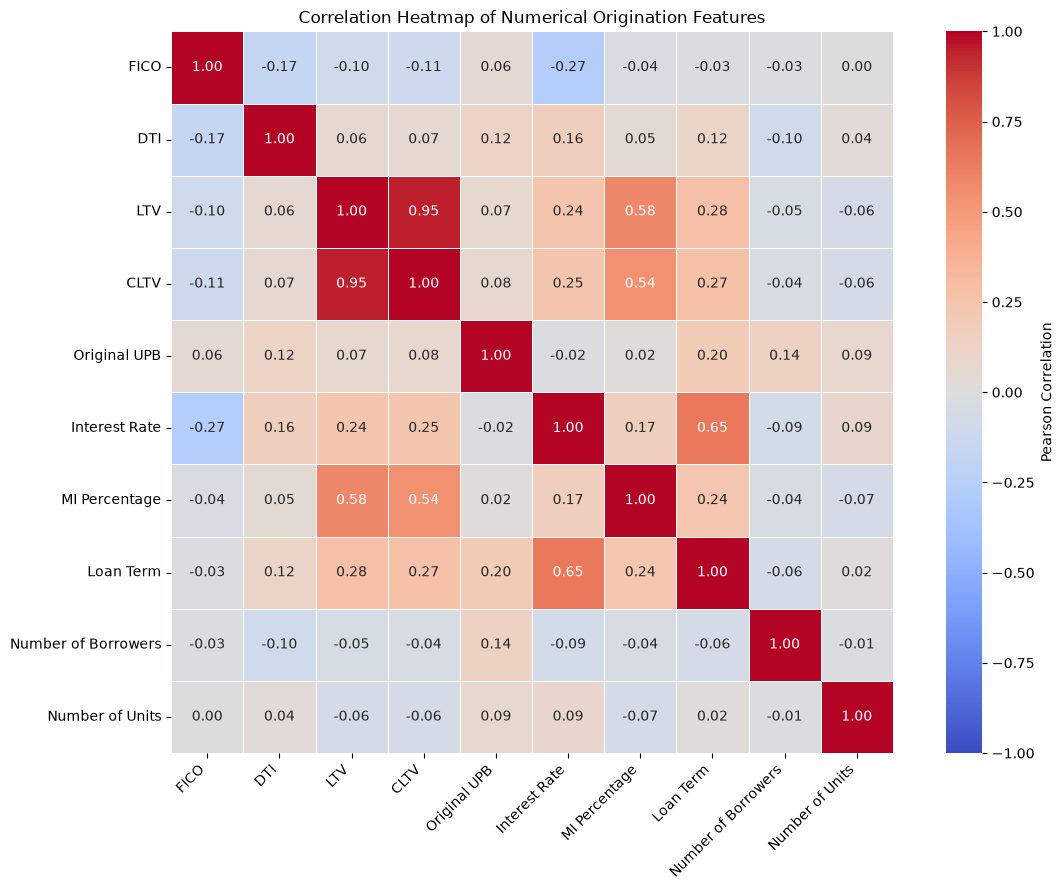

In [170]:
correlation_matrix = correlation_data.corr(method="pearson")

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Pearson Correlation"}
)

plt.title("Correlation Heatmap of Numerical Origination Features")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#### Correlation Heatmap Findings

The Pearson correlation heatmap was used to screen linear relationships and potential multicollinearity among meaningful numerical origination features. Cleaned versions of DTI, LTV, and CLTV were used so that documented unavailable-value sentinels were excluded. Missing values were handled using pairwise-complete observations without deleting rows from the original dataset.

Key findings include:

- LTV and CLTV have a very strong positive correlation of 0.95. Because both are potential predictors, this indicates possible multicollinearity if they are included together in the Logistic Regression model. This will be formally assessed using VIF during modeling.
- Original loan term and interest rate have a comparatively strong positive correlation of 0.65. This is the strongest relationship not previously investigated and warrants additional bivariate analysis.
- LTV and MI percentage have a moderate positive correlation of 0.58, while CLTV and MI percentage have a correlation of 0.54.
- FICO and interest rate have a weak negative correlation of -0.27.
- LTV and interest rate have a weak positive correlation of 0.24.
- Most remaining numerical relationships are weak.

The heatmap identifies linear associations but does not establish causation or reveal every possible nonlinear relationship. Selected relationships are therefore evaluated further using correlations, grouped summaries, and visualizations.


### Original Loan Term vs. Original Interest Rate

This analysis examines whether mortgage duration is associated with the original interest rate. Because original loan term is concentrated primarily at 180 and 360 months, correlations will be interpreted together with grouped summaries and a boxplot.

In [171]:
loan_term = orig_2015["ORIGINAL LOAN TERM"]
interest_rate = orig_2015["ORIGINAL INTEREST RATE"]

term_rate_data = orig_2015.loc[
    loan_term.notna() & interest_rate.notna(),
    [
        "ORIGINAL LOAN TERM",
        "ORIGINAL INTEREST RATE"
    ]
].copy()

pearson_corr = term_rate_data[
    "ORIGINAL LOAN TERM"
].corr(
    term_rate_data["ORIGINAL INTEREST RATE"],
    method="pearson"
)

spearman_corr = term_rate_data[
    "ORIGINAL LOAN TERM"
].corr(
    term_rate_data["ORIGINAL INTEREST RATE"],
    method="spearman"
)

print("Valid paired observations:", len(term_rate_data))
print()
print("Pearson correlation:", pearson_corr)
print("Spearman correlation:", spearman_corr)

Valid paired observations: 50000

Pearson correlation: 0.6501747835681094
Spearman correlation: 0.5864499346564318


In [172]:
term_rate_summary = (
    term_rate_data
    .groupby("ORIGINAL LOAN TERM")["ORIGINAL INTEREST RATE"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        minimum="min",
        maximum="max"
    )
    .sort_index()
)

print(term_rate_summary)

                    count      mean  median       std  minimum  maximum
ORIGINAL LOAN TERM                                                     
96                      1  3.750000  3.7500       NaN    3.750    3.750
120                   560  3.385975  3.2695  0.431140    2.500    4.750
121                     2  3.875000  3.8750  0.353553    3.625    4.125
123                     1  3.375000  3.3750       NaN    3.375    3.375
132                     9  3.333333  3.3750  0.265165    2.875    3.750
...                   ...       ...     ...       ...      ...      ...
356                     4  4.000000  4.0000  0.306186    3.625    4.375
358                     3  3.791667  3.8750  0.144338    3.625    3.875
359                     4  4.187500  4.0625  0.484123    3.750    4.875
360                 36501  4.140775  4.1250  0.325492    2.875    5.500
366                     1  4.625000  4.6250       NaN    4.625    4.625

[85 rows x 6 columns]


In [173]:
term_frequency = (
    term_rate_data["ORIGINAL LOAN TERM"]
    .value_counts()
    .rename_axis("Loan Term")
    .reset_index(name="Count")
)

term_frequency["Percentage"] = (
    term_frequency["Count"] / len(term_rate_data) * 100
)

print(term_frequency.head(10).to_string(index=False))

 Loan Term  Count  Percentage
       360  36501      73.002
       180   9632      19.264
       240   2596       5.192
       120    560       1.120
       300    363       0.726
       276     33       0.066
       288     30       0.060
       168     26       0.052
       348     24       0.048
       324     20       0.040


In [174]:
major_terms = [120, 180, 240, 300, 360]

print(
    term_rate_summary
    .loc[major_terms]
    .round(3)
)

                    count   mean  median    std  minimum  maximum
ORIGINAL LOAN TERM                                               
120                   560  3.386   3.270  0.431    2.500    4.750
180                  9632  3.387   3.375  0.370    2.375    4.750
240                  2596  3.932   3.875  0.328    3.250    5.125
300                   363  4.112   4.125  0.326    3.500    5.250
360                 36501  4.141   4.125  0.325    2.875    5.500


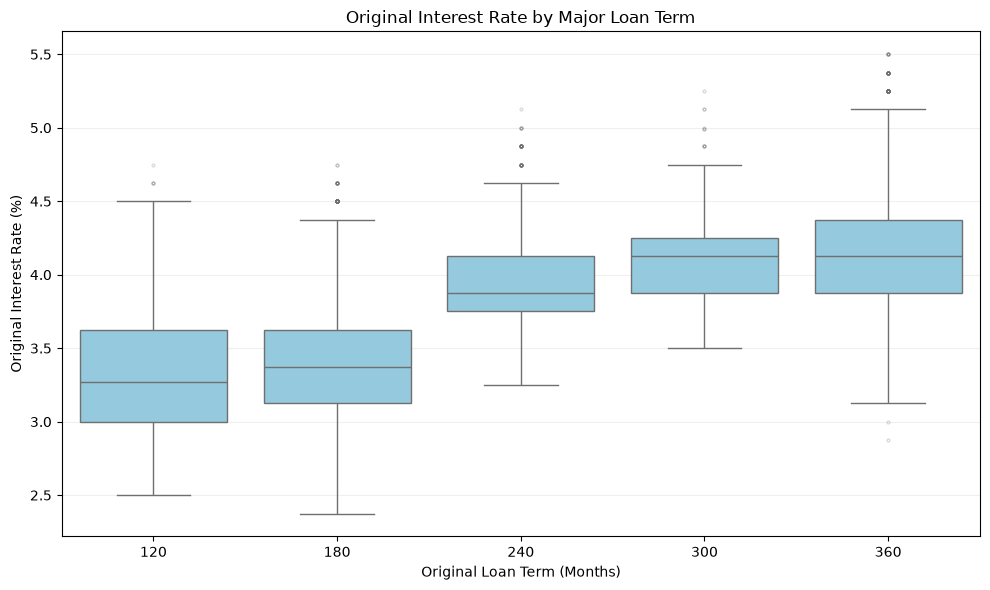

In [175]:
major_term_data = term_rate_data.loc[
    term_rate_data["ORIGINAL LOAN TERM"].isin(major_terms)
].copy()

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=major_term_data,
    x="ORIGINAL LOAN TERM",
    y="ORIGINAL INTEREST RATE",
    order=major_terms,
    color="skyblue",
    flierprops={
        "marker": "o",
        "markersize": 2,
        "alpha": 0.25
    }
)

plt.title("Original Interest Rate by Major Loan Term")
plt.xlabel("Original Loan Term (Months)")
plt.ylabel("Original Interest Rate (%)")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

#### Findings

- All 50,000 loans had valid paired observations for original loan term and original interest rate.
- Pearson correlation was 0.650, indicating a comparatively strong positive linear association.
- Spearman correlation was 0.586, indicating a moderate-to-strong positive monotonic association.
- The five major loan terms—120, 180, 240, 300, and 360 months—represented 99.304% of the dataset and were selected for the boxplot.
- The 120- and 180-month loans had similar mean interest rates of approximately 3.39%.
- The mean interest rate increased to approximately 3.93% for 240-month loans, 4.11% for 300-month loans, and 4.14% for 360-month loans.
- The boxplot shows an upward shift in the interest-rate distribution as loan terms move from shorter-term to longer-term products.
- The relationship is stepwise rather than uniformly linear. For example, 120- and 180-month loans have similar rates, while 300- and 360-month loans share the same median rate of 4.125%.
- The loan-term groups are highly imbalanced, with 360-month loans representing 73.00% of the sample. Group sizes must therefore be considered when comparing their distributions.
- The observed association does not establish that loan term alone caused the differences in interest rates; other borrower, property, and loan-pricing characteristics may also contribute.

## categorical–numerical analysis

# Loan Purpose vs. Original LTV

This analysis examines whether original loan-to-value ratios differ across loan-purpose categories. The cleaned LTV variable is used so that the documented `999` sentinel is excluded.

In [176]:
loan_purpose_ltv_data = orig_2015.loc[
    orig_2015["LOAN PURPOSE"].notna()
    & orig_2015["ORIGINAL LOAN-TO-VALUE (LTV)_CLEAN"].notna(),
    [
        "LOAN PURPOSE",
        "ORIGINAL LOAN-TO-VALUE (LTV)_CLEAN"
    ]
].copy()

loan_purpose_ltv_summary = (
    loan_purpose_ltv_data
    .groupby("LOAN PURPOSE")[
        "ORIGINAL LOAN-TO-VALUE (LTV)_CLEAN"
    ]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        minimum="min",
        maximum="max"
    )
    .round(2)
)

print("Valid paired observations:", len(loan_purpose_ltv_data))
print()
print(loan_purpose_ltv_summary)

Valid paired observations: 49999

              count   mean  median    std  minimum  maximum
LOAN PURPOSE                                               
C             10333  64.33    69.0  15.54      7.0     90.0
N             17512  69.88    73.0  18.95      5.0    241.0
P             22154  80.66    80.0  13.96     12.0    100.0


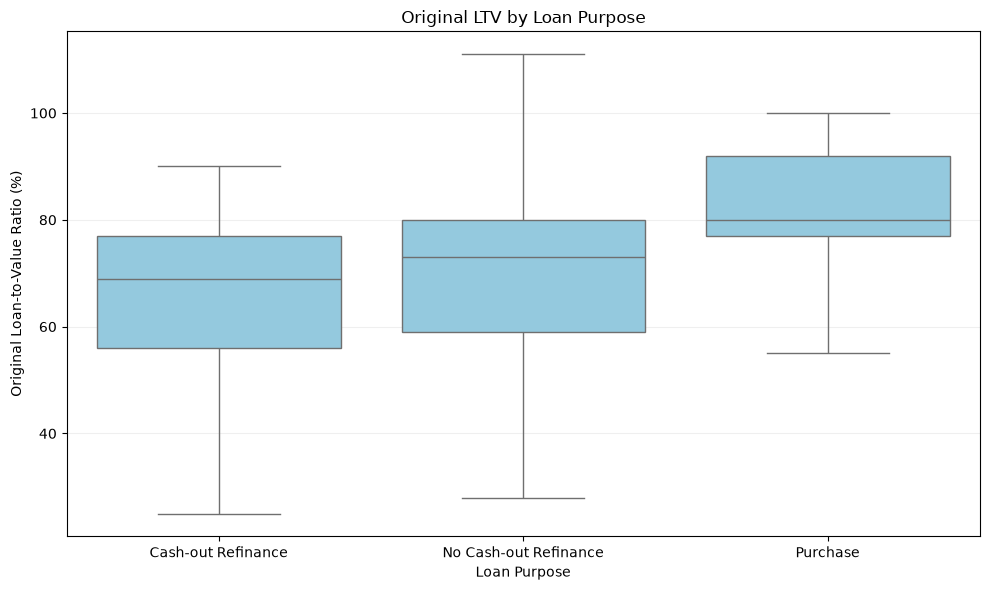

In [177]:
purpose_labels = {
    "C": "Cash-out Refinance",
    "N": "No Cash-out Refinance",
    "P": "Purchase"
}

loan_purpose_ltv_data["LOAN PURPOSE LABEL"] = (
    loan_purpose_ltv_data["LOAN PURPOSE"].map(purpose_labels)
)

purpose_order = [
    "Cash-out Refinance",
    "No Cash-out Refinance",
    "Purchase"
]

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=loan_purpose_ltv_data,
    x="LOAN PURPOSE LABEL",
    y="ORIGINAL LOAN-TO-VALUE (LTV)_CLEAN",
    order=purpose_order,
    color="skyblue",
    showfliers=False
)

plt.title("Original LTV by Loan Purpose")
plt.xlabel("Loan Purpose")
plt.ylabel("Original Loan-to-Value Ratio (%)")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

#### Findings

- There were 49,999 valid loan-purpose and cleaned-LTV pairs after excluding the single documented `999` LTV sentinel.
- Purchase loans had the highest typical leverage, with a mean LTV of 80.66% and a median of 80%.
- No-cash-out refinance loans had a mean LTV of 69.88% and a median of 73%.
- Cash-out refinance loans had the lowest typical leverage, with a mean LTV of 64.33% and a median of 69%.
- The boxplot shows that the purchase-loan LTV distribution is shifted upward relative to both refinance categories.
- The two refinance categories overlap substantially, although no-cash-out refinances generally have somewhat higher LTV values.
- No-cash-out refinance loans showed the greatest variability and included the extreme valid LTV observations. Outlier markers were suppressed in the boxplot for readability but were retained in the grouped statistics and underlying data.
- These results indicate an association between loan purpose and leverage but do not establish a causal relationship.
- Changes in the proportion of purchase and refinance loans across years could contribute to changes in the overall LTV distribution, making loan-purpose composition relevant to later population-drift analysis.


### Occupancy Status vs. Original LTV

This analysis examines whether original loan-to-value ratios differ among primary residences, investment properties, and second homes. The cleaned LTV variable is used so that the documented `999` sentinel is excluded.

In [178]:
occupancy_labels = {
    "P": "Primary Residence",
    "I": "Investment Property",
    "S": "Second Home"
}

occupancy_ltv_data = orig_2015.loc[
    orig_2015["OCCUPANCY STATUS"].notna()
    & orig_2015["ORIGINAL LOAN-TO-VALUE (LTV)_CLEAN"].notna(),
    [
        "OCCUPANCY STATUS",
        "ORIGINAL LOAN-TO-VALUE (LTV)_CLEAN"
    ]
].copy()

occupancy_ltv_data["OCCUPANCY LABEL"] = (
    occupancy_ltv_data["OCCUPANCY STATUS"].map(occupancy_labels)
)

occupancy_ltv_summary = (
    occupancy_ltv_data
    .groupby("OCCUPANCY LABEL")[
        "ORIGINAL LOAN-TO-VALUE (LTV)_CLEAN"
    ]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        minimum="min",
        maximum="max"
    )
    .round(2)
)

print("Valid paired observations:", len(occupancy_ltv_data))
print()
print(occupancy_ltv_summary)

Valid paired observations: 49999

                     count   mean  median    std  minimum  maximum
OCCUPANCY LABEL                                                   
Investment Property   4156  69.31    75.0  16.69      8.0    197.0
Primary Residence    44095  73.97    79.0  17.61      5.0    209.0
Second Home           1748  72.02    78.0  15.50     16.0    241.0


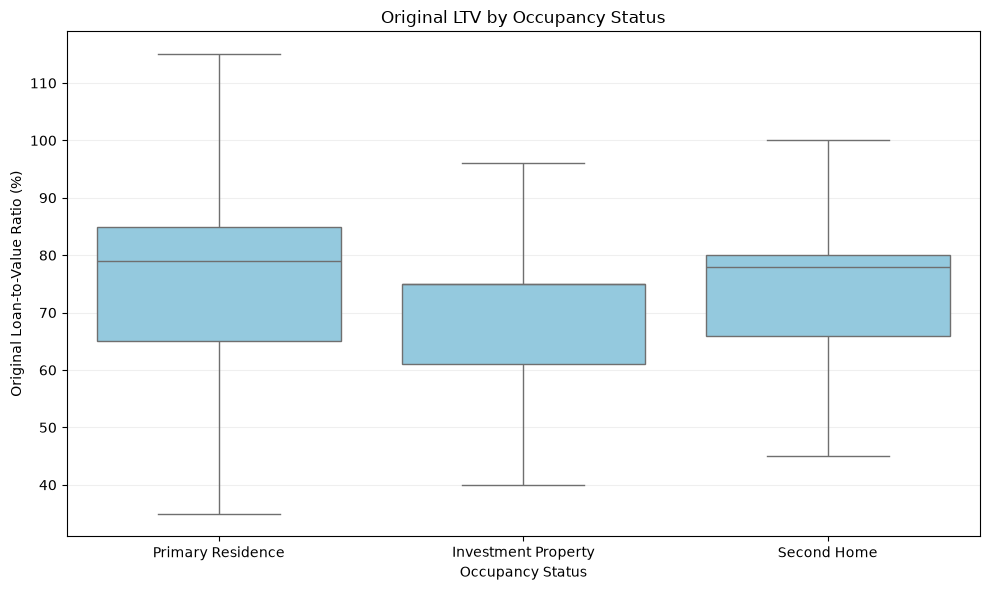

In [179]:
occupancy_order = [
    "Primary Residence",
    "Investment Property",
    "Second Home"
]

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=occupancy_ltv_data,
    x="OCCUPANCY LABEL",
    y="ORIGINAL LOAN-TO-VALUE (LTV)_CLEAN",
    order=occupancy_order,
    color="skyblue",
    showfliers=False
)

plt.title("Original LTV by Occupancy Status")
plt.xlabel("Occupancy Status")
plt.ylabel("Original Loan-to-Value Ratio (%)")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

#### Findings

- There were 49,999 valid occupancy-status and cleaned-LTV pairs after excluding the single documented `999` LTV sentinel.
- Primary residences had the highest mean LTV of 73.97% and a median of 79%.
- Second homes had a mean LTV of 72.02% and a median of 78%, making their typical leverage relatively similar to primary residences.
- Investment properties had the lowest typical leverage, with a mean LTV of 69.31% and a median of 75%.
- The boxplot shows that the investment-property LTV distribution is shifted somewhat lower than those of primary residences and second homes.
- However, the distributions overlap substantially, indicating that occupancy status alone does not clearly separate loans by LTV.
- The occupancy groups are imbalanced: primary residences account for approximately 88.19% of valid observations, compared with 8.31% for investment properties and 3.50% for second homes.
- Valid extreme LTV observations occurred in all three groups. Outlier markers were suppressed in the boxplot for readability but retained in the underlying data and summary statistics.
- Changes in occupancy composition across origination years could contribute to population drift, although the 2015 differences in typical LTV are modest.

### First-Time Homebuyer Indicator vs. Original LTV

This analysis compares the distribution of original LTV between first-time and non-first-time homebuyers. Higher LTV indicates that the borrower financed a larger proportion of the property value.

In [180]:
first_time_homebuyer = orig_2015[
    "FIRST TIME HOMEBUYER INDICATOR_CLEAN"
]

ltv = orig_2015[
    "ORIGINAL LOAN-TO-VALUE (LTV)_CLEAN"
]

first_time_homebuyer_label = first_time_homebuyer.map(
    {
        "Y": "First-Time Homebuyer",
        "N": "Not First-Time Homebuyer"
    }
)

paired_mask = (
    first_time_homebuyer_label.notna()
    & ltv.notna()
)

fthb_ltv_summary = (
    pd.DataFrame(
        {
            "FIRST-TIME HOMEBUYER LABEL":
                first_time_homebuyer_label[paired_mask],
            "ORIGINAL LTV": ltv[paired_mask]
        }
    )
    .groupby("FIRST-TIME HOMEBUYER LABEL")["ORIGINAL LTV"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        minimum="min",
        maximum="max"
    )
    .round(2)
)

print("Valid paired observations:", paired_mask.sum())
print()
print(fthb_ltv_summary)

Valid paired observations: 49991

                            count   mean  median    std  minimum  maximum
FIRST-TIME HOMEBUYER LABEL                                               
First-Time Homebuyer         7790  84.66    89.0  11.67     12.0    100.0
Not First-Time Homebuyer    42201  71.45    75.0  17.64      5.0    241.0


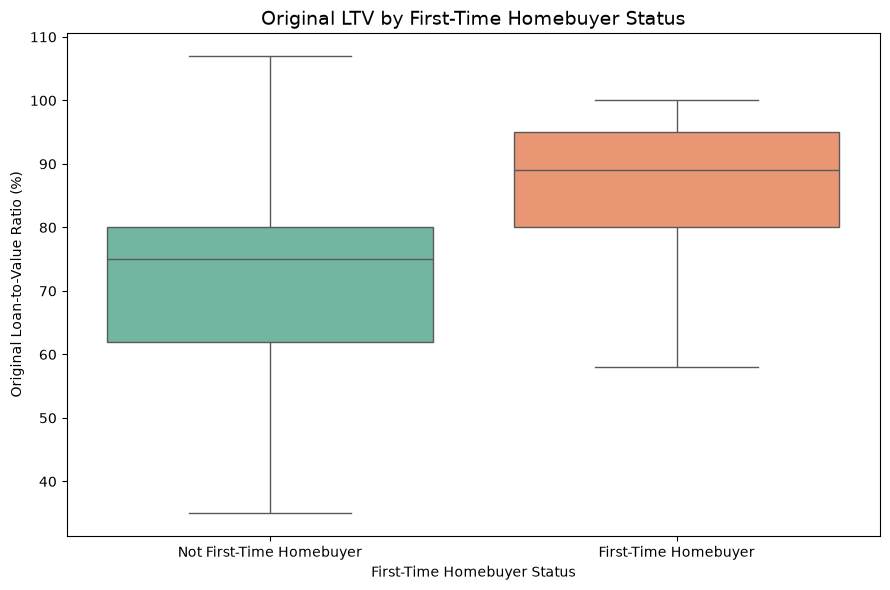

In [181]:
fthb_ltv_plot = pd.DataFrame(
    {
        "First-Time Homebuyer Status":
            first_time_homebuyer_label[paired_mask],
        "Original LTV": ltv[paired_mask]
    }
)

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=fthb_ltv_plot,
    x="First-Time Homebuyer Status",
    y="Original LTV",
    hue="First-Time Homebuyer Status",
    order=[
        "Not First-Time Homebuyer",
        "First-Time Homebuyer"
    ],
    palette="Set2",
    showfliers=False,
    legend=False
)

plt.title(
    "Original LTV by First-Time Homebuyer Status",
    fontsize=14
)
plt.xlabel("First-Time Homebuyer Status")
plt.ylabel("Original Loan-to-Value Ratio (%)")
plt.tight_layout()
plt.show()

#### Findings

- First-time homebuyers had noticeably higher original LTV ratios than non-first-time homebuyers.
- The median LTV was **89%** for first-time homebuyers, compared with **75%** for non-first-time homebuyers.
- The mean LTV showed the same pattern: **84.66%** versus **71.45%**.
- First-time homebuyer LTV values were more concentrated, with a standard deviation of **11.67**, compared with **17.64** among non-first-time homebuyers.
- This pattern suggests that first-time homebuyers generally financed a larger proportion of the property value, which may reflect smaller down payments.
- Non-first-time homebuyers exhibited substantially greater variability and included rare LTV values above 100%, reaching a maximum of **241%**.
- Outlier markers were hidden in the boxplot for readability but remained included in the numerical summary.
- The group sizes were unequal: **7,790** first-time homebuyers and **42,201** non-first-time homebuyers.
- These results demonstrate an association between first-time homebuyer status and original LTV; they do not establish that homebuyer status caused the difference.

### Property Type vs. Original LTV

This analysis compares original LTV distributions across property types. Differences may indicate variation in borrower financing patterns and lending requirements for different forms of housing.

In [182]:
property_type = orig_2015["PROPERTY TYPE"]

ltv = orig_2015[
    "ORIGINAL LOAN-TO-VALUE (LTV)_CLEAN"
]

property_type_label = property_type.map(
    {
        "SF": "Single-Family",
        "PU": "Planned Unit Development",
        "CO": "Condominium",
        "MH": "Manufactured Home",
        "CP": "Cooperative"
    }
)

paired_mask = (
    property_type_label.notna()
    & ltv.notna()
)

property_type_ltv_summary = (
    pd.DataFrame(
        {
            "PROPERTY TYPE LABEL": property_type_label[paired_mask],
            "ORIGINAL LTV": ltv[paired_mask]
        }
    )
    .groupby("PROPERTY TYPE LABEL")["ORIGINAL LTV"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        minimum="min",
        maximum="max"
    )
    .round(2)
    .sort_values("median")
)

print("Valid paired observations:", paired_mask.sum())
print()
print(property_type_ltv_summary)

Valid paired observations: 49999

                          count   mean  median    std  minimum  maximum
PROPERTY TYPE LABEL                                                    
Cooperative                  97  64.02    72.0  19.50      6.0     95.0
Manufactured Home           176  76.58    77.0  21.15     32.0    171.0
Single-Family             32565  72.99    77.0  17.78      5.0    209.0
Condominium                4012  75.42    79.0  18.17      8.0    241.0
Planned Unit Development  13149  74.25    79.0  16.47      7.0    159.0


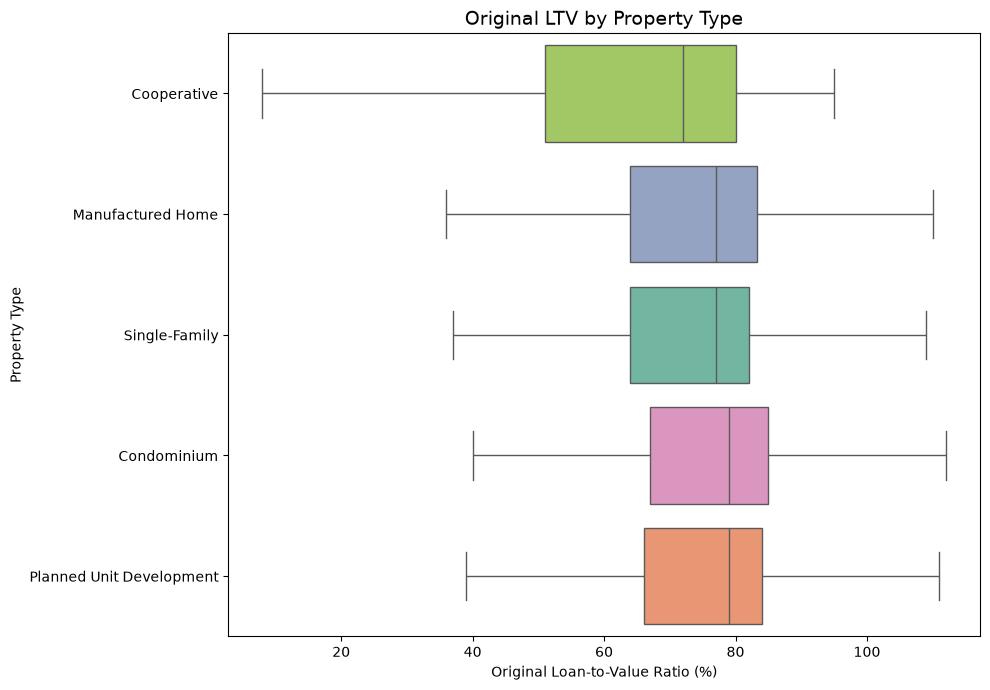

In [183]:
property_type_ltv_plot = pd.DataFrame(
    {
        "Property Type": property_type_label[paired_mask],
        "Original LTV": ltv[paired_mask]
    }
)

property_type_order = [
    "Cooperative",
    "Manufactured Home",
    "Single-Family",
    "Condominium",
    "Planned Unit Development"
]

plt.figure(figsize=(10, 7))

sns.boxplot(
    data=property_type_ltv_plot,
    y="Property Type",
    x="Original LTV",
    hue="Property Type",
    order=property_type_order,
    palette="Set2",
    showfliers=False,
    legend=False
)

plt.title(
    "Original LTV by Property Type",
    fontsize=14
)
plt.xlabel("Original Loan-to-Value Ratio (%)")
plt.ylabel("Property Type")
plt.tight_layout()
plt.show()

#### Findings

- Original LTV distributions overlapped considerably across property types, suggesting that property type alone was not strongly associated with LTV in this sample.
- Condominiums and planned unit developments had the highest median LTV at **79%**.
- Single-family properties and manufactured homes both had a median LTV of **77%**.
- Cooperatives had the lowest median LTV at **72%** and the lowest mean at **64.02%**.
- Manufactured homes had the highest mean LTV at **76.58%**, but this category contained only **176 loans**.
- Cooperatives also had a small sample size of **97 loans**, so their results should be interpreted cautiously.
- Single-family properties dominated the sample with **32,565 loans**, followed by planned unit developments with **13,149 loans**.
- Rare extreme LTV values occurred among several property types, including a maximum of **241%** for condominiums. These observations remained included in the summary statistics, although outlier markers were hidden in the boxplot.
- Overall, property-type differences were modest compared with the difference previously observed between first-time and non-first-time homebuyers.


## Multivariate Correlation Overview

This analysis summarizes the linear relationships among selected numeric origination variables. It helps identify potentially redundant predictors and provides an initial indication of multicollinearity before model development.

In [184]:
correlation_data = orig_2015[
    [
        "CLASSIC FICO",
        "ORIGINAL DEBT-TO-INCOME (DTI) RATIO_CLEAN",
        "ORIGINAL LOAN-TO-VALUE (LTV)_CLEAN",
        "ORIGINAL COMBINED LOAN-TO-VALUE (CLTV)_CLEAN",
        "ORIGINAL UPB",
        "ORIGINAL INTEREST RATE",
        "ORIGINAL LOAN TERM",
        "NUMBER OF BORROWERS"
    ]
].copy()

correlation_data.columns = [
    "FICO",
    "DTI",
    "LTV",
    "CLTV",
    "UPB",
    "Interest Rate",
    "Loan Term",
    "Borrowers"
]

correlation_matrix = correlation_data.corr(method="pearson")

print("Pearson correlation matrix:")
print()
print(correlation_matrix.round(3))

Pearson correlation matrix:

                FICO    DTI    LTV   CLTV    UPB  Interest Rate  Loan Term  \
FICO           1.000 -0.166 -0.096 -0.114  0.059         -0.268     -0.026   
DTI           -0.166  1.000  0.064  0.066  0.117          0.164      0.117   
LTV           -0.096  0.064  1.000  0.949  0.072          0.245      0.281   
CLTV          -0.114  0.066  0.949  1.000  0.079          0.246      0.267   
UPB            0.059  0.117  0.072  0.079  1.000         -0.023      0.203   
Interest Rate -0.268  0.164  0.245  0.246 -0.023          1.000      0.650   
Loan Term     -0.026  0.117  0.281  0.267  0.203          0.650      1.000   
Borrowers     -0.030 -0.096 -0.049 -0.041  0.143         -0.085     -0.064   

               Borrowers  
FICO              -0.030  
DTI               -0.096  
LTV               -0.049  
CLTV              -0.041  
UPB                0.143  
Interest Rate     -0.085  
Loan Term         -0.064  
Borrowers          1.000  


# Heat map

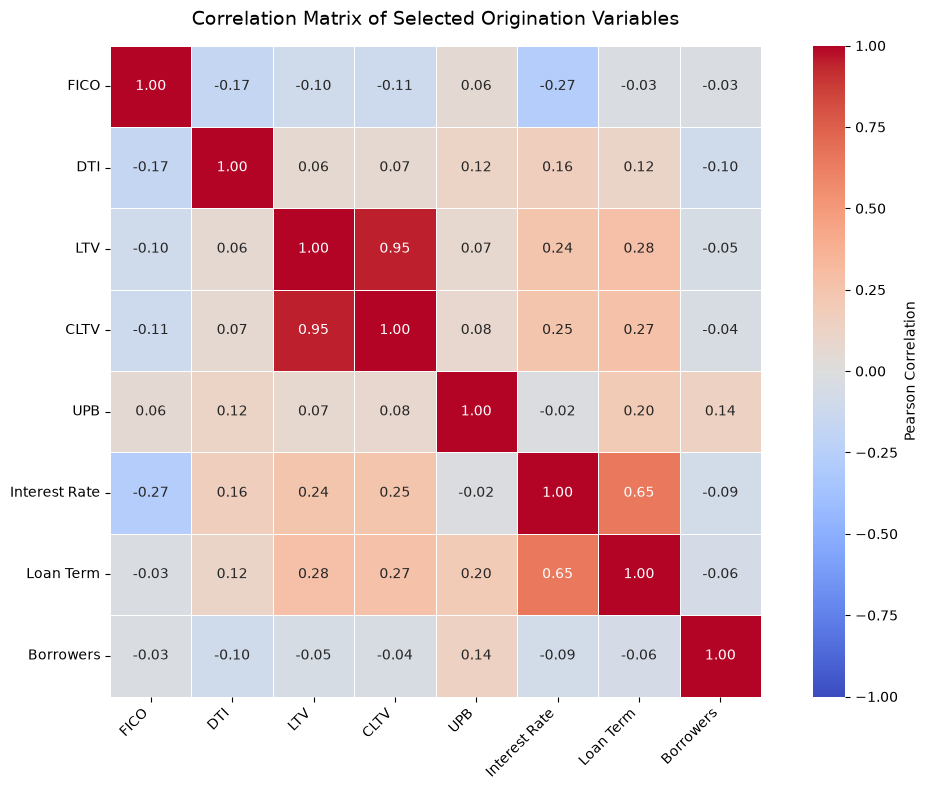

In [185]:
plt.figure(figsize=(11, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    square=True,
    cbar_kws={"label": "Pearson Correlation"}
)

plt.title(
    "Correlation Matrix of Selected Origination Variables",
    fontsize=14,
    pad=15
)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Multivariate Correlation Findings

- Original LTV and original CLTV had a very strong positive correlation of **0.95**. This is expected because CLTV includes the original mortgage balance plus any additional liens, while LTV considers the original mortgage alone.
- Because LTV and CLTV contain highly overlapping information, including both without further evaluation may create multicollinearity in Logistic Regression. This will be assessed later using methods such as the Variance Inflation Factor (VIF), coefficient stability, and regularization.
- Original interest rate and loan term had a moderately strong positive correlation of **0.65**. Longer-term loans generally carried higher interest rates in this sample.
- FICO had a negative correlation of **−0.27** with interest rate, indicating that borrowers with higher credit scores generally received lower interest rates.
- LTV and CLTV had modest positive correlations with interest rate, at approximately **0.24** and **0.25**, respectively.
- Most remaining correlations were weak, suggesting limited linear dependence among the other selected origination variables.
- These correlations describe linear associations only and do not establish causal relationships.
- Correlations involving DTI were calculated using available cleaned observations because documented `999` sentinel values were converted to missing values.